# Perbandingan Metode LSTM dan GRU dalam Memprediksi Harga Bitcoin Berdasarkan Informasi Blockchain

**Program Studi Ilmu Aktuaria — Skripsi S1**

Notebook ini membandingkan dua arsitektur *recurrent neural network* untuk
memprediksi harga penutupan harian Bitcoin:

1. **LSTM** (*Long Short-Term Memory*) — memiliki tiga gerbang (*forget*, *input*, *output*) dan satu *cell state*.
2. **GRU** (*Gated Recurrent Unit*) — memiliki dua gerbang (*update*, *reset*) dan tanpa *cell state* terpisah.

**Pertanyaan penelitian.** Apakah GRU yang strukturnya lebih sederhana mampu
menyamai atau mengungguli akurasi LSTM, dan bagaimana perbandingan efisiensinya
(jumlah parameter dan waktu latih)?

---

## Daftar Tahapan

| Tahap | Judul |
|---|---|
| 0 | Persiapan lingkungan |
| 1 | Pengumpulan data |
| 2 | Eksplorasi data |
| 3 | Pembersihan data |
| 4 | Pembagian data (sebelum normalisasi) |
| 5 | Normalisasi Min-Max |
| 6 | Pembentukan *sliding window* |
| 7 | Model LSTM |
| 8 | Model GRU |
| 9 | Perbandingan arsitektur dan kestabilan |
| 10 | Denormalisasi |
| 11 | Evaluasi model |
| 12 | Uji signifikansi Diebold-Mariano |
| 13 | Visualisasi |
| 14 | Kesimpulan otomatis |

> **Catatan pembacaan angka.** Seluruh angka dicetak dengan pemisah ribuan tanda
> koma dan pemisah desimal tanda titik (konvensi keluaran komputer), misalnya
> `61,234.56` berarti enam puluh satu ribu dua ratus tiga puluh empat koma lima
> enam dolar AS.

---
## TAHAP 0 — Persiapan Lingkungan

**Tujuan.** Memuat seluruh pustaka yang dipakai, mencetak versinya agar hasil
penelitian dapat direproduksi, mengunci seluruh sumber bilangan acak, dan
menampilkan blok `CONFIG` yang menjadi satu-satunya tempat pengaturan penelitian.

**Mengapa seed dikunci?** Bobot awal jaringan saraf diundi secara acak. Tanpa
penguncian *seed*, dua kali menjalankan kode yang sama akan menghasilkan angka
berbeda sehingga perbandingan LSTM vs GRU menjadi tidak sahih. Kita mengunci tiga
sumber keacakan sekaligus — `random` (Python), `numpy`, dan `tensorflow` — serta
mengaktifkan mode deterministik TensorFlow bila tersedia.

**Prinsip perbandingan yang adil.** LSTM dan GRU akan memakai data, panjang
*window*, grid *hyperparameter*, *batch size*, *optimizer*, *learning rate*, dan
*seed* yang **sama persis**. Satu-satunya perbedaan adalah jenis lapisan rekuren.

In [1]:
# --------------------------------------------------------------------------- #
# Impor pustaka
# --------------------------------------------------------------------------- #
import os
import sys
import time
import random
import platform
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # sembunyikan log informatif TensorFlow
os.environ["PYTHONHASHSEED"] = "42"        # kunci hash Python sebelum impor lain
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy
import scipy.stats
import sklearn
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

# Modul pendukung yang ditulis sendiri (folder src/)
DIR_PROYEK = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.isdir(os.path.join(DIR_PROYEK, "src")):      # jika dijalankan dari akar proyek
    DIR_PROYEK = os.path.abspath(os.getcwd())
sys.path.insert(0, os.path.join(DIR_PROYEK, "src"))

import utils                      # header, format angka, penyimpanan tabel/gambar
import data as modul_data         # pengumpulan data Blockchain.com
import metrik                     # RMSE, MAE, MAPE, akurasi arah, Diebold-Mariano

tf.get_logger().setLevel("ERROR")   # redam pesan retracing tf.function

# Tampilkan gambar langsung di dalam notebook bila dijalankan di Jupyter;
# bila dijalankan sebagai skrip biasa, pakai backend non-interaktif.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    matplotlib.use("Agg")

utils.aktifkan_format_pandas(desimal=4)
sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["font.size"] = 9

utils.cetak_header(0, "Persiapan lingkungan")

print("Versi perangkat lunak yang digunakan:")
print(f"  Python      : {platform.python_version()}")
print(f"  numpy       : {np.__version__}")
print(f"  pandas      : {pd.__version__}")
print(f"  scipy       : {scipy.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  tensorflow  : {tf.__version__}")
print(f"  keras       : {tf.keras.__version__}")
print(f"  matplotlib  : {matplotlib.__version__}")
print(f"  seaborn     : {sns.__version__}")
print(f"  Sistem      : {platform.system()} {platform.release()}")

I0000 00:00:1789574354.270750    5287 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TAHAP 0 - PERSIAPAN LINGKUNGAN
Versi perangkat lunak yang digunakan:
  Python      : 3.11.15
  numpy       : 2.4.6
  pandas      : 3.0.5
  scipy       : 1.17.1
  scikit-learn: 1.9.1
  tensorflow  : 2.21.0
  keras       : 3.15.1
  matplotlib  : 3.11.2
  seaborn     : 0.13.2
  Sistem      : Linux 6.18.44-fc-v33


I0000 00:00:1789574355.885594    5287 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# --------------------------------------------------------------------------- #
# BLOK CONFIG — satu-satunya tempat pengaturan penelitian
# --------------------------------------------------------------------------- #
CONFIG = {
    "ASET": "BTC",
    "TANGGAL_MULAI": "2023-07-01",
    "TANGGAL_AKHIR": "2026-07-31",
    "RASIO_LATIH": 0.8,
    "RASIO_VALIDASI_DARI_LATIH": 0.1,
    "LOOKBACK": 7,
    "NEURON_GRID": [10, 20, 30, 40, 50],
    "EPOCH_GRID": [100, 500, 1000],
    "BATCH_SIZE": 32,
    "JUMLAH_LAYER_REKUREN": 1,   # 1 layer agar perhitungan manual bisa diverifikasi
    "OPTIMIZER": "adam",
    "LEARNING_RATE": 0.001,
    "SEED": 42,
    "SEED_ULANGAN": [42, 7, 21, 100, 2024],  # untuk uji kestabilan model terbaik
}

utils.cetak_sub("Isi blok CONFIG")
lebar_kunci = max(len(k) for k in CONFIG)
for kunci, nilai in CONFIG.items():
    print(f"  {kunci:<{lebar_kunci}} : {nilai}")


----------------------------------------------------------------------
Isi blok CONFIG
----------------------------------------------------------------------
  ASET                      : BTC
  TANGGAL_MULAI             : 2023-07-01
  TANGGAL_AKHIR             : 2026-07-31
  RASIO_LATIH               : 0.8
  RASIO_VALIDASI_DARI_LATIH : 0.1
  LOOKBACK                  : 7
  NEURON_GRID               : [10, 20, 30, 40, 50]
  EPOCH_GRID                : [100, 500, 1000]
  BATCH_SIZE                : 32
  JUMLAH_LAYER_REKUREN      : 1
  OPTIMIZER                 : adam
  LEARNING_RATE             : 0.001
  SEED                      : 42
  SEED_ULANGAN              : [42, 7, 21, 100, 2024]


In [3]:
# --------------------------------------------------------------------------- #
# Penguncian seluruh sumber bilangan acak
# --------------------------------------------------------------------------- #
def atur_seed(seed: int) -> None:
    """
    Kunci seluruh sumber bilangan acak agar hasil dapat direproduksi:
    ``random`` (Python), ``numpy``, dan ``tensorflow``.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)   # mengunci Python+NumPy+TF sekaligus


# Mode deterministik TensorFlow: operasi yang sama menghasilkan angka yang sama
try:
    tf.config.experimental.enable_op_determinism()
    status_deterministik = "AKTIF"
except Exception as e:                                  # versi TF lama
    status_deterministik = f"TIDAK TERSEDIA ({e})"

atur_seed(CONFIG["SEED"])

utils.cetak_sub("Status reproduksibilitas")
print(f"  Seed utama                  : {CONFIG['SEED']}")
print(f"  Seed ulangan (uji kestabilan): {CONFIG['SEED_ULANGAN']}")
print(f"  PYTHONHASHSEED              : {os.environ['PYTHONHASHSEED']}")
print(f"  Mode deterministik TensorFlow: {status_deterministik}")
print(f"  Perangkat komputasi          : "
      f"{[p.device_type for p in tf.config.list_physical_devices()]}")

# Bukti singkat bahwa seed benar-benar bekerja
atur_seed(CONFIG["SEED"]); acak_1 = np.random.rand(3)
atur_seed(CONFIG["SEED"]); acak_2 = np.random.rand(3)
print(f"\n  Uji seed -> tarikan ke-1: {np.round(acak_1, 6)}")
print(f"  Uji seed -> tarikan ke-2: {np.round(acak_2, 6)}")
assert np.array_equal(acak_1, acak_2), "Seed gagal: dua tarikan acak berbeda."
print("  OK Dua tarikan acak identik: penguncian seed BERHASIL.")

utils.ringkasan_tahap("""
Lingkungan kerja telah siap: seluruh pustaka berhasil dimuat dan versinya
dicatat agar penelitian dapat direproduksi ulang di komputer lain. Seluruh
sumber bilangan acak (Python, NumPy, dan TensorFlow) telah dikunci pada seed
42 dan mode deterministik TensorFlow diaktifkan.

Blok CONFIG menjadi satu-satunya tempat pengaturan penelitian, sehingga LSTM
dan GRU dijamin memakai data, panjang window, grid hyperparameter, batch size,
optimizer, dan seed yang sama persis. Dengan demikian perbedaan hasil yang
muncul nanti murni berasal dari perbedaan arsitektur, bukan dari perbedaan
pengaturan.
""")


----------------------------------------------------------------------
Status reproduksibilitas
----------------------------------------------------------------------
  Seed utama                  : 42
  Seed ulangan (uji kestabilan): [42, 7, 21, 100, 2024]
  PYTHONHASHSEED              : 42
  Mode deterministik TensorFlow: AKTIF
  Perangkat komputasi          : ['CPU']

  Uji seed -> tarikan ke-1: [0.37454  0.950714 0.731994]
  Uji seed -> tarikan ke-2: [0.37454  0.950714 0.731994]
  OK Dua tarikan acak identik: penguncian seed BERHASIL.

RINGKASAN TAHAP
Lingkungan kerja telah siap: seluruh pustaka berhasil dimuat dan
versinya dicatat agar penelitian dapat direproduksi ulang di komputer
lain. Seluruh sumber bilangan acak (Python, NumPy, dan TensorFlow)
telah dikunci pada seed 42 dan mode deterministik TensorFlow
diaktifkan.

Blok CONFIG menjadi satu-satunya tempat pengaturan penelitian,
sehingga LSTM dan GRU dijamin memakai data, panjang window, grid
hyperparameter, batch size, optim

---
## TAHAP 1 — Pengumpulan Data

**Tujuan.** Mengumpulkan harga penutupan harian Bitcoin beserta sembilan
variabel informasi *blockchain* pada periode 1 Juli 2023 s.d. 31 Juli 2026.

**Urutan sumber data.**

1. Jika berkas `data/dataset_bitcoin.csv` sudah ada, berkas itu yang dipakai.
2. Jika belum ada, data diunduh dari **Blockchain.com Charts API**:
   `https://api.blockchain.info/charts/<nama-chart>?timespan=...&start=...&format=json&sampled=false`
3. Seluruh *chart* digabungkan berdasarkan tanggal (UTC) memakai *left join*
   terhadap kalender harian penuh, lalu disimpan ke `data/dataset_bitcoin.csv`.

**Hasil verifikasi ketersediaan chart.** Kesepuluh *chart* pada tabel penelitian
telah diverifikasi **tersedia dan berfrekuensi harian** untuk seluruh periode.
Dua catatan penting:

- **Difficulty (X3)** memang bernilai konstan selama beberapa hari berturut-turut
  karena jaringan Bitcoin hanya menyesuaikan tingkat kesulitan setiap 2.016 blok
  (± dua minggu). Jadi nilainya berbentuk **fungsi tangga** (*step function*),
  bukan data hilang. Nilai harian tetap tersedia setiap tanggal, sehingga
  variabel ini dipakai sebagaimana adanya tanpa penggantian variabel.
- Beberapa *chart* kehilangan 3–5 tanggal karena *gap* pelaporan API. Tanggal
  seperti ini akan muncul sebagai `NaN` dan ditangani pada **Tahap 3** dengan
  *forward fill*, yaitu memakai nilai hari sebelumnya. Cara ini dipilih karena
  variabel *blockchain* bersifat *persistent* (berubah lambat dari hari ke hari)
  dan *forward fill* **tidak memakai informasi masa depan** sehingga bebas dari
  *look-ahead bias*.

$\rightarrow$ Karena kesepuluh variabel tersedia lengkap, **tidak ada variabel
yang diganti** dalam penelitian ini.

In [4]:
utils.cetak_header(1, "Pengumpulan data")

path_dataset = os.path.join(utils.DIR_DATA, "dataset_bitcoin.csv")

utils.cetak_sub("1.1 Pemuatan / pengunduhan data")
df_mentah, sumber_data, tabel_observasi = modul_data.muat_atau_unduh(
    path_dataset,
    CONFIG["TANGGAL_MULAI"],
    CONFIG["TANGGAL_AKHIR"],
    verbose=True,
)

print(f"\n  Sumber data yang dipakai : {sumber_data}")
print(f"  Lokasi berkas dataset    : {os.path.relpath(path_dataset, DIR_PROYEK)}")
print(f"  Aset                     : {CONFIG['ASET']}")
print(f"  Periode diminta          : {CONFIG['TANGGAL_MULAI']} s.d. {CONFIG['TANGGAL_AKHIR']}")
print(f"  Periode diperoleh        : {df_mentah['date'].min().date()} s.d. {df_mentah['date'].max().date()}")

hari_kalender = (pd.Timestamp(CONFIG["TANGGAL_AKHIR"]) - pd.Timestamp(CONFIG["TANGGAL_MULAI"])).days + 1
print(f"  Jumlah hari kalender     : {utils.fmt_int(hari_kalender)} hari")
print(f"  Jumlah baris dataset     : {utils.fmt_int(len(df_mentah))} baris")
utils.cetak_shape("df_mentah", df_mentah)

TAHAP 1 - PENGUMPULAN DATA

----------------------------------------------------------------------
1.1 Pemuatan / pengunduhan data
----------------------------------------------------------------------
  Berkas 'dataset_bitcoin.csv' ditemukan -> memuat dari berkas lokal.

  Sumber data yang dipakai : berkas lokal
  Lokasi berkas dataset    : data/dataset_bitcoin.csv
  Aset                     : BTC
  Periode diminta          : 2023-07-01 s.d. 2026-07-31
  Periode diperoleh        : 2023-07-01 s.d. 2026-07-31
  Jumlah hari kalender     : 1,127 hari
  Jumlah baris dataset     : 1,127 baris
  shape df_mentah                    = (1127, 11)


In [5]:
utils.cetak_sub("1.2 Jumlah observasi per variabel (hasil penggabungan)")
print(tabel_observasi.to_string(index=False))
utils.simpan_tabel(tabel_observasi, 1,
                   "Jumlah observasi per variabel hasil pengumpulan data")

utils.cetak_sub("1.3 Tabel definisi operasional variabel")
tabel_definisi = modul_data.tabel_definisi_variabel()
for _, baris in tabel_definisi.iterrows():
    print(f"\n  [{baris['Kode']}] {baris['Variabel']}")
    print(f"      Nama kolom : {baris['Nama Kolom']}")
    print(f"      Satuan     : {baris['Satuan']}")
    print(f"      Definisi   : {baris['Definisi Operasional']}")
    print(f"      Sumber     : {baris['Sumber']}")
print()
utils.simpan_tabel(tabel_definisi, 2, "Definisi operasional variabel penelitian")

KOLOM_TARGET = modul_data.KOLOM_TARGET     # 'close_price' -> berperan sebagai Y
KOLOM_FITUR = modul_data.KOLOM_FITUR       # X1..X10 (termasuk close_price sebagai X1)
print(f"\n  Variabel target (Y)      : {KOLOM_TARGET}")
print(f"  Variabel fitur (X1..X10) : {len(KOLOM_FITUR)} kolom")
print(f"                             {KOLOM_FITUR}")

utils.ringkasan_tahap(f"""
Data berhasil dikumpulkan dari {sumber_data} untuk periode
{df_mentah['date'].min().date()} s.d. {df_mentah['date'].max().date()},
menghasilkan {utils.fmt_int(len(df_mentah))} baris tanggal dan
{len(KOLOM_FITUR)} variabel penelitian. Kesepuluh chart Blockchain.com
terverifikasi tersedia pada frekuensi harian sehingga tidak ada variabel yang
perlu diganti.

Harga penutupan (Close Price) berperan ganda: sebagai variabel target Y yang
akan diprediksi, dan sebagai variabel prediktor X1. Beberapa tanggal masih
kosong akibat gap pelaporan API dan akan ditangani pada Tahap 3, sedangkan
nilai Difficulty yang berulang beberapa hari bukan data hilang melainkan sifat
alami penyesuaian jaringan Bitcoin setiap 2.016 blok.
""")


----------------------------------------------------------------------
1.2 Jumlah observasi per variabel (hasil penggabungan)
----------------------------------------------------------------------
  Kode                 Variabel                        Chart  Jumlah Observasi API Tanggal Awal Tanggal Akhir  Tanggal Hilang vs Kalender
Y / X1        Close Price (USD)                 market-price                  1127   2023-07-01    2026-07-31                           0
    X2     Miners Revenue (USD)               miners-revenue                  1127   2023-07-01    2026-07-31                           0
    X3               Difficulty                   difficulty                  1124   2023-07-01    2026-07-31                           3
    X4                Hash Rate                    hash-rate                  1124   2023-07-01    2026-07-31                           3
    X5 Median Confirmation Time     median-confirmation-time                  1124   2023-07-01    2026-07-31   

---
## TAHAP 2 — Eksplorasi Data

**Tujuan.** Mengenali karakteristik data sebelum dimodelkan: sebaran nilai,
kecenderungan (*trend*), dan keterkaitan antar variabel.

**Statistik deskriptif yang dihitung.**

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
\qquad
s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}\left(x_i - \bar{x}\right)^2}$$

$$\text{Skewness} = \frac{n}{(n-1)(n-2)}\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{s}\right)^3
\qquad
\text{Kurtosis}_{\text{excess}} = \frac{n(n+1)}{(n-1)(n-2)(n-3)}\sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{s}\right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}$$

**Arti hasil.** *Skewness* $>0$ berarti sebaran menjulur ke kanan (lebih banyak
nilai rendah dengan beberapa nilai sangat tinggi). *Excess kurtosis* $>0$ berarti
sebaran lebih berpuncak dan berekor tebal dibandingkan distribusi normal — ciri
umum data harga aset kripto.

**Korelasi Pearson.**

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}$$

Nilai $r$ berkisar $-1$ sampai $+1$: mendekati $+1$ berarti kedua variabel
bergerak searah, mendekati $-1$ berarti berlawanan arah, dan mendekati $0$
berarti tidak ada hubungan linear.

**Perhitungan manual tahap ini.** Menghitung rata-rata dan standar deviasi
Close Price langkah demi langkah dengan angka asli, lalu membandingkannya
dengan hasil pandas menggunakan `assert`.

In [6]:
utils.cetak_header(2, "Eksplorasi data")

utils.cetak_sub("2.1 Sepuluh baris pertama")
print(df_mentah.head(10).to_string(index=False))

utils.cetak_sub("2.2 Sepuluh baris terakhir")
print(df_mentah.tail(10).to_string(index=False))

utils.cetak_sub("2.3 Tipe data dan jumlah observasi")
info_kolom = pd.DataFrame({
    "Kolom": df_mentah.columns,
    "Tipe Data": [str(t) for t in df_mentah.dtypes],
    "Jumlah Tidak Kosong": [int(df_mentah[k].notna().sum()) for k in df_mentah.columns],
    "Jumlah Kosong (NaN)": [int(df_mentah[k].isna().sum()) for k in df_mentah.columns],
})
print(info_kolom.to_string(index=False))
print(f"\n  Jumlah baris (observasi) : {utils.fmt_int(len(df_mentah))}")
print(f"  Jumlah kolom             : {df_mentah.shape[1]} (1 kolom tanggal + {len(KOLOM_FITUR)} variabel)")
utils.cetak_shape("df_mentah", df_mentah)

TAHAP 2 - EKSPLORASI DATA

----------------------------------------------------------------------
2.1 Sepuluh baris pertama
----------------------------------------------------------------------
      date  close_price  miners_revenue              difficulty        hash_rate  median_confirmation_time  avg_block_size  n_unique_addresses  n_transactions_per_block  n_transactions  cost_per_transaction_percent
2023-07-01  30,471.5000 26,154,914.7326 50,646,206,431,058.0000 334,845,664.7950                    9.3000          1.6568        622,117.0000                2,438.1504    324,274.0000                        0.8325
2023-07-02  30,591.5300 33,775,253.8485 50,646,206,431,058.0000 430,515,854.7364                    6.9500          1.8167        534,333.0000                1,812.3977    309,920.0000                        1.7354
2023-07-03  30,618.2500 27,990,140.9099 50,646,206,431,058.0000 344,916,211.1046                   12.6333          1.7802        655,439.0000                2,

In [7]:
utils.cetak_sub("2.4 Statistik deskriptif seluruh variabel")

statistik = pd.DataFrame({
    "N": df_mentah[KOLOM_FITUR].notna().sum(),
    "Mean": df_mentah[KOLOM_FITUR].mean(),
    "Std": df_mentah[KOLOM_FITUR].std(),
    "Min": df_mentah[KOLOM_FITUR].min(),
    "Q1": df_mentah[KOLOM_FITUR].quantile(0.25),
    "Median": df_mentah[KOLOM_FITUR].median(),
    "Q3": df_mentah[KOLOM_FITUR].quantile(0.75),
    "Max": df_mentah[KOLOM_FITUR].max(),
    "Skewness": df_mentah[KOLOM_FITUR].skew(),
    "Kurtosis": df_mentah[KOLOM_FITUR].kurt(),
})
statistik.insert(0, "Kode", [v["kode"] for v in modul_data.DEFINISI_VARIABEL])
statistik.insert(1, "Variabel", [v["nama"] for v in modul_data.DEFINISI_VARIABEL])
statistik = statistik.reset_index(names="Nama Kolom")

with pd.option_context("display.float_format", lambda v: f"{v:,.4f}"):
    print(statistik[["Kode", "Nama Kolom", "N", "Mean", "Std", "Min",
                     "Q1", "Median", "Q3", "Max"]].to_string(index=False))
    print()
    print(statistik[["Kode", "Nama Kolom", "Skewness", "Kurtosis"]].to_string(index=False))

utils.simpan_tabel(statistik, 3, "Statistik deskriptif seluruh variabel")

print("\n  Bacaan cepat Close Price (USD):")
s_close = df_mentah[KOLOM_TARGET]
print(f"    Harga terendah : {utils.fmt_usd(s_close.min())} USD "
      f"(tanggal {df_mentah.loc[s_close.idxmin(), 'date'].date()})")
print(f"    Harga tertinggi: {utils.fmt_usd(s_close.max())} USD "
      f"(tanggal {df_mentah.loc[s_close.idxmax(), 'date'].date()})")
print(f"    Rata-rata      : {utils.fmt_usd(s_close.mean())} USD")
print(f"    Standar deviasi: {utils.fmt_usd(s_close.std())} USD")
print(f"    Rentang harga  : {utils.fmt_usd(s_close.max() - s_close.min())} USD")


----------------------------------------------------------------------
2.4 Statistik deskriptif seluruh variabel
----------------------------------------------------------------------
  Kode                   Nama Kolom    N                     Mean                     Std                     Min                      Q1                   Median                       Q3                      Max
Y / X1                  close_price 1127              73,217.8544             26,310.0752             25,162.7000             59,183.9750              69,331.6600              95,072.1150             124,776.6800
    X2               miners_revenue 1127          40,490,901.6820         11,570,432.3560         19,271,798.2438         30,919,496.1157          39,119,908.7663          48,190,547.8068         107,755,899.7201
    X3                   difficulty 1124 105,186,221,446,133.1875 30,482,492,231,593.9805 50,646,206,431,058.0000 82,047,728,459,932.7656 109,782,075,598,904.5000 132,399,817,6

  [tersimpan] Tabel 3. Statistik deskriptif seluruh variabel
              -> outputs/tabel/tabel_03_statistik_deskriptif_seluruh_variabel.csv / .xlsx

  Bacaan cepat Close Price (USD):
    Harga terendah : 25,162.70 USD (tanggal 2023-09-12)
    Harga tertinggi: 124,776.68 USD (tanggal 2025-10-07)
    Rata-rata      : 73,217.85 USD
    Standar deviasi: 26,310.08 USD
    Rentang harga  : 99,613.98 USD



----------------------------------------------------------------------
2.5 Gambar 1 — Plot time series seluruh variabel
----------------------------------------------------------------------


  [tersimpan] Gambar 1. Plot time series seluruh variabel penelitian
              -> outputs/gambar/gambar_01_plot_time_series_seluruh_variabel_penelitian.png (300 dpi)


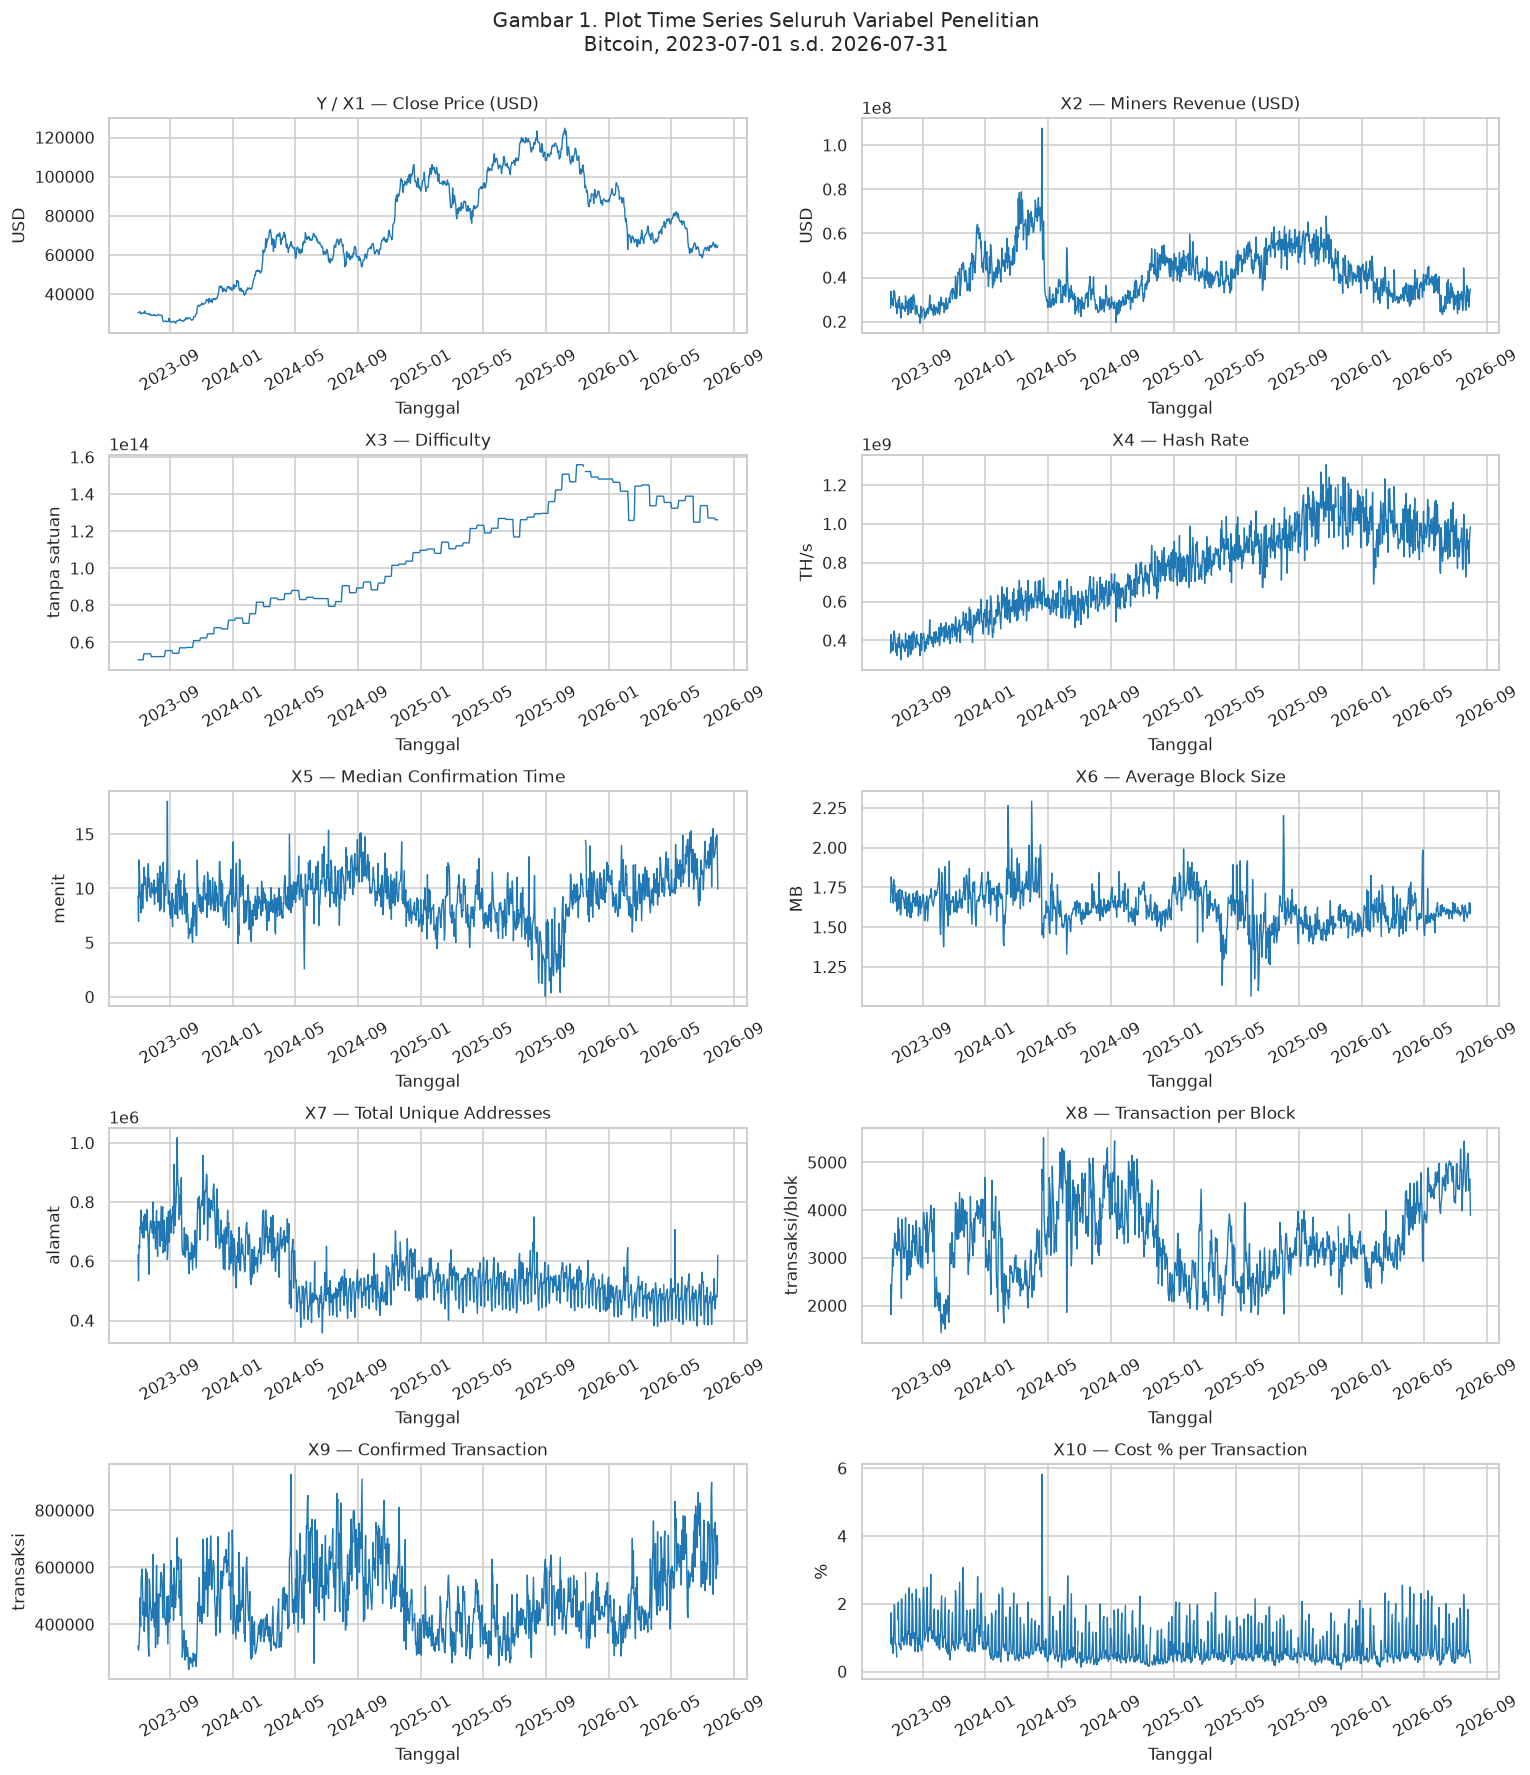

In [8]:
utils.cetak_sub("2.5 Gambar 1 — Plot time series seluruh variabel")

fig, sumbu = plt.subplots(5, 2, figsize=(14, 16))
sumbu = sumbu.ravel()
for ke, var in enumerate(modul_data.DEFINISI_VARIABEL):
    ax = sumbu[ke]
    ax.plot(df_mentah["date"], df_mentah[var["kolom"]], linewidth=0.9, color="#1f77b4")
    ax.set_title(f"{var['kode']} — {var['nama']}")
    ax.set_xlabel("Tanggal")
    ax.set_ylabel(var["satuan"])
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Gambar 1. Plot Time Series Seluruh Variabel Penelitian\n"
             f"Bitcoin, {CONFIG['TANGGAL_MULAI']} s.d. {CONFIG['TANGGAL_AKHIR']}",
             fontsize=13, y=1.005)
fig.tight_layout()
utils.simpan_gambar(fig, 1, "Plot time series seluruh variabel penelitian")
plt.show()


----------------------------------------------------------------------
2.6 Gambar 2 — Heatmap korelasi Pearson
----------------------------------------------------------------------


  [tersimpan] Gambar 2. Heatmap korelasi Pearson antar variabel
              -> outputs/gambar/gambar_02_heatmap_korelasi_pearson_antar_variabel.png (300 dpi)


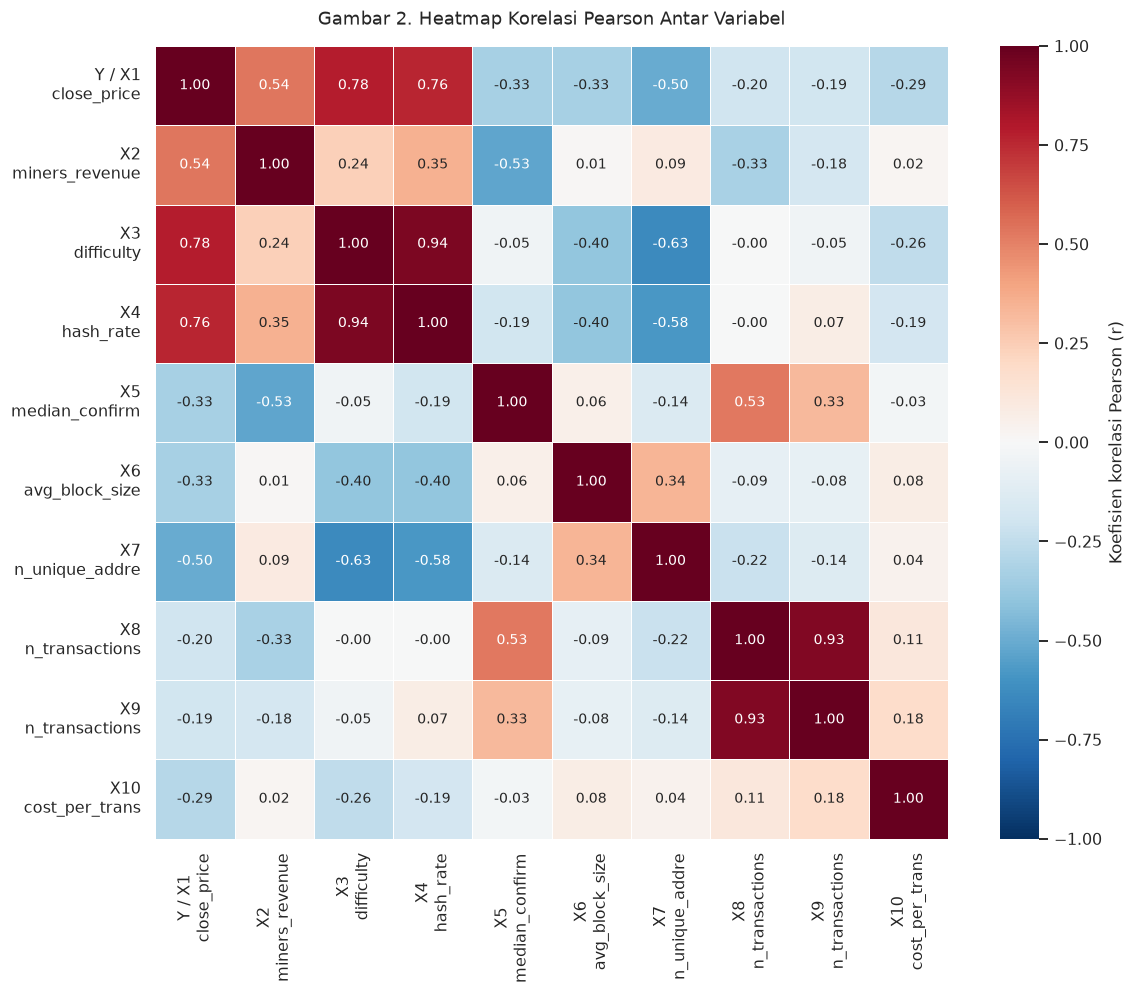


----------------------------------------------------------------------
2.7 Korelasi tiap variabel blockchain terhadap harga Bitcoin
----------------------------------------------------------------------
  X3   Difficulty                 r = +0.7827  -> kuat dan positif (searah)
  X4   Hash Rate                  r = +0.7629  -> kuat dan positif (searah)
  X2   Miners Revenue (USD)       r = +0.5385  -> sedang dan positif (searah)
  X9   Confirmed Transaction      r = -0.1921  -> sangat lemah / hampir tidak ada dan negatif (berlawanan arah)
  X8   Transaction per Block      r = -0.1962  -> sangat lemah / hampir tidak ada dan negatif (berlawanan arah)
  X10  Cost % per Transaction     r = -0.2888  -> lemah dan negatif (berlawanan arah)
  X6   Average Block Size         r = -0.3312  -> lemah dan negatif (berlawanan arah)
  X5   Median Confirmation Time   r = -0.3338  -> lemah dan negatif (berlawanan arah)
  X7   Total Unique Addresses     r = -0.5025  -> sedang dan negatif (berlawanan ara

'/home/user/prediction-lstm-gru-btc/outputs/tabel/tabel_04_korelasi_pearson_variabel_blockchain_terhadap_harga_penutupan'

In [9]:
utils.cetak_sub("2.6 Gambar 2 — Heatmap korelasi Pearson")

korelasi = df_mentah[KOLOM_FITUR].corr(method="pearson")
label_pendek = [f"{v['kode']}\n{v['kolom'][:14]}" for v in modul_data.DEFINISI_VARIABEL]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(korelasi, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"label": "Koefisien korelasi Pearson (r)"},
            xticklabels=label_pendek, yticklabels=label_pendek, ax=ax)
ax.set_title("Gambar 2. Heatmap Korelasi Pearson Antar Variabel", fontsize=12, pad=14)
fig.tight_layout()
utils.simpan_gambar(fig, 2, "Heatmap korelasi Pearson antar variabel")
plt.show()


def tafsir_korelasi(r: float) -> str:
    """Kategori kekuatan hubungan linear berdasarkan nilai |r|."""
    besar = abs(r)
    arah = "positif (searah)" if r > 0 else "negatif (berlawanan arah)"
    if besar >= 0.8:
        kuat = "sangat kuat"
    elif besar >= 0.6:
        kuat = "kuat"
    elif besar >= 0.4:
        kuat = "sedang"
    elif besar >= 0.2:
        kuat = "lemah"
    else:
        kuat = "sangat lemah / hampir tidak ada"
    return f"{kuat} dan {arah}"


utils.cetak_sub("2.7 Korelasi tiap variabel blockchain terhadap harga Bitcoin")
baris_korelasi = []
for var in modul_data.DEFINISI_VARIABEL:
    if var["kolom"] == KOLOM_TARGET:
        continue
    r = float(korelasi.loc[KOLOM_TARGET, var["kolom"]])
    baris_korelasi.append({
        "Kode": var["kode"], "Variabel": var["nama"],
        "r terhadap Close Price": r, "Interpretasi": tafsir_korelasi(r),
    })
tabel_korelasi = (pd.DataFrame(baris_korelasi)
                  .sort_values("r terhadap Close Price", ascending=False)
                  .reset_index(drop=True))
for _, b in tabel_korelasi.iterrows():
    print(f"  {b['Kode']:<4} {b['Variabel']:<26} r = {b['r terhadap Close Price']:+.4f}  -> {b['Interpretasi']}")
print()
utils.simpan_tabel(tabel_korelasi, 4,
                   "Korelasi Pearson variabel blockchain terhadap harga penutupan")

In [10]:
utils.cetak_sub("2.8 PERHITUNGAN MANUAL — rata-rata dan standar deviasi Close Price")

baris_manual = []


def tulis(teks: str = "") -> None:
    """Cetak ke layar sekaligus simpan untuk berkas perhitungan manual."""
    print(teks)
    baris_manual.append(teks)


x = df_mentah[KOLOM_TARGET].to_numpy(dtype=np.float64)
n = x.size

# ---- (a) Perhitungan manual langkah demi langkah --------------------------- #
tulis("(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH")
tulis()
tulis(f"Jumlah data          n = {utils.fmt_int(n)}")
tulis()
tulis("RATA-RATA:  x_bar = (1/n) * (x_1 + x_2 + ... + x_n)")
tulis()
suku_awal = "  +  ".join(utils.fmt_usd(v) for v in x[:5])
tulis(f"  x_bar = (1/{n}) * ( {suku_awal}  + ... + {utils.fmt_usd(x[-1])} )")
jumlah_x = float(x.sum())
tulis(f"  Jumlah seluruh x     = {utils.fmt_usd(jumlah_x)}")
mean_manual = jumlah_x / n
tulis(f"  x_bar = {utils.fmt_usd(jumlah_x)} / {n}")
tulis(f"  x_bar = {utils.fmt_usd(mean_manual, 6)} USD")
tulis()

tulis("STANDAR DEVIASI (sampel, pembagi n-1):")
tulis("  s = akar( SUM (x_i - x_bar)^2 / (n - 1) )")
tulis()
selisih = x - mean_manual
selisih_kuadrat = selisih ** 2
tulis("  Lima suku pertama (x_i - x_bar)^2 :")
for ke in range(5):
    tulis(f"    i={ke+1}: ({utils.fmt_usd(x[ke])} - {utils.fmt_usd(mean_manual)})^2 "
          f"= ({utils.fmt_usd(selisih[ke])})^2 = {utils.fmt_usd(selisih_kuadrat[ke])}")
jumlah_kuadrat = float(selisih_kuadrat.sum())
tulis(f"  SUM (x_i - x_bar)^2  = {utils.fmt_usd(jumlah_kuadrat)}")
varians_manual = jumlah_kuadrat / (n - 1)
tulis(f"  Varians  s^2 = {utils.fmt_usd(jumlah_kuadrat)} / ({n} - 1) = {utils.fmt_usd(varians_manual)}")
std_manual = float(np.sqrt(varians_manual))
tulis(f"  Std dev  s   = akar({utils.fmt_usd(varians_manual)}) = {utils.fmt_usd(std_manual, 6)} USD")
tulis()

# ---- (b) Pembandingan dengan pandas + assert ------------------------------- #
tulis("(b) PEMBANDINGAN DENGAN HASIL LIBRARY (pandas)")
tulis()
mean_pandas = float(df_mentah[KOLOM_TARGET].mean())
std_pandas = float(df_mentah[KOLOM_TARGET].std())     # pandas memakai ddof=1
tulis(f"  {'':<22}{'Manual':>22}{'pandas':>22}{'Selisih':>16}")
tulis(f"  {'Rata-rata (USD)':<22}{utils.fmt_usd(mean_manual, 6):>22}"
      f"{utils.fmt_usd(mean_pandas, 6):>22}{abs(mean_manual - mean_pandas):>16.2e}")
tulis(f"  {'Standar deviasi (USD)':<22}{utils.fmt_usd(std_manual, 6):>22}"
      f"{utils.fmt_usd(std_pandas, 6):>22}{abs(std_manual - std_pandas):>16.2e}")
tulis()

assert np.isclose(mean_manual, mean_pandas, atol=1e-5), "Rata-rata manual != pandas"
assert np.isclose(std_manual, std_pandas, atol=1e-5), "Standar deviasi manual != pandas"
tulis("  OK Hasil manual SAMA dengan hasil model (toleransi 1e-5)")

print("\n✔ Hasil manual SAMA dengan hasil model")

utils.tulis_manual(2, "Rata-rata dan Standar Deviasi Close Price", f"""
## Rumus

$$\\bar{{x}} = \\frac{{1}}{{n}}\\sum_{{i=1}}^{{n}} x_i
\\qquad
s = \\sqrt{{\\frac{{1}}{{n-1}}\\sum_{{i=1}}^{{n}}\\left(x_i - \\bar{{x}}\\right)^2}}$$

dengan $x_i$ = harga penutupan Bitcoin hari ke-$i$ (USD) dan $n$ = {utils.fmt_int(n)}.

## Perhitungan

{utils.blok_kode(chr(10).join(baris_manual))}

## Kesimpulan

Rata-rata Close Price hasil hitung tangan sebesar
**{utils.fmt_usd(mean_manual)} USD** dan standar deviasinya
**{utils.fmt_usd(std_manual)} USD**, identik dengan keluaran `pandas`
(`.mean()` dan `.std()`) sampai toleransi $10^{{-5}}$.
""")

utils.ringkasan_tahap(f"""
Dataset memuat {utils.fmt_int(len(df_mentah))} observasi harian dengan harga
penutupan Bitcoin bergerak dari {utils.fmt_usd(s_close.min())} USD hingga
{utils.fmt_usd(s_close.max())} USD, yaitu rentang lebih dari
{utils.fmt_usd(s_close.max() - s_close.min())} USD; rata-ratanya
{utils.fmt_usd(s_close.mean())} USD dengan standar deviasi
{utils.fmt_usd(s_close.std())} USD sehingga fluktuasinya sangat lebar.

Plot time series menunjukkan tren naik jangka panjang yang disertai koreksi
tajam, sedangkan heatmap korelasi memperlihatkan variabel
{tabel_korelasi.iloc[0]['Variabel']} (r = {tabel_korelasi.iloc[0]['r terhadap Close Price']:+.4f})
paling kuat berhubungan dengan harga penutupan. Skala antar variabel sangat
berbeda (dari satuan menit hingga ratusan triliun pada Difficulty), sehingga
normalisasi pada Tahap 5 menjadi wajib agar tidak ada variabel yang mendominasi
pembelajaran jaringan.

Perhitungan manual rata-rata dan standar deviasi Close Price terbukti identik
dengan hasil pandas, sehingga rumus statistik deskriptif yang dipakai pada
Bab III sudah tervalidasi.
""")


----------------------------------------------------------------------
2.8 PERHITUNGAN MANUAL — rata-rata dan standar deviasi Close Price
----------------------------------------------------------------------
(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH

Jumlah data          n = 1,127

RATA-RATA:  x_bar = (1/n) * (x_1 + x_2 + ... + x_n)

  x_bar = (1/1127) * ( 30,471.50  +  30,591.53  +  30,618.25  +  31,150.92  +  30,774.87  + ... + 64,720.99 )
  Jumlah seluruh x     = 82,516,521.90
  x_bar = 82,516,521.90 / 1127
  x_bar = 73,217.854392 USD

STANDAR DEVIASI (sampel, pembagi n-1):
  s = akar( SUM (x_i - x_bar)^2 / (n - 1) )

  Lima suku pertama (x_i - x_bar)^2 :
    i=1: (30,471.50 - 73,217.85)^2 = (-42,746.35)^2 = 1,827,250,813.82
    i=2: (30,591.53 - 73,217.85)^2 = (-42,626.32)^2 = 1,817,003,531.19
    i=3: (30,618.25 - 73,217.85)^2 = (-42,599.60)^2 = 1,814,726,294.37
    i=4: (31,150.92 - 73,217.85)^2 = (-42,066.93)^2 = 1,769,626,969.16
    i=5: (30,774.87 - 73,217.85)^2 = (-42,442

---
## TAHAP 3 — Pembersihan Data

**Tujuan.** Memastikan tidak ada tanggal hilang, tanggal duplikat, atau nilai
kosong yang dapat merusak pembentukan *sliding window* dan pelatihan model.

**Pemeriksaan yang dilakukan.**

1. **Missing value** — jumlah dan persentase nilai kosong per variabel.
2. **Tanggal hilang** — tanggal pada kalender harian yang tidak ada barisnya.
3. **Tanggal duplikat** — tanggal yang muncul lebih dari satu kali.

**Penanganan yang dipilih: *forward fill* (nilai hari sebelumnya).**

$$x_t \leftarrow x_{t-1} \quad \text{jika } x_t \text{ kosong}$$

**Alasan.**

- Variabel *blockchain* bersifat *persistent*: nilainya berubah lambat dari hari
  ke hari, sehingga nilai hari sebelumnya adalah penduga terbaik yang tersedia.
- *Forward fill* **hanya memakai informasi masa lalu**, sehingga tidak
  menimbulkan *look-ahead bias* (kebocoran informasi masa depan) — hal yang
  krusial pada pemodelan data runtun waktu.
- Interpolasi linear atau pengisian dengan rata-rata keseluruhan **tidak** dipakai
  karena keduanya memakai nilai hari sesudahnya, yang berarti membocorkan
  informasi masa depan.
- Baris yang kosong **tidak dihapus** karena penghapusan akan memutus keteraturan
  runtun waktu harian dan merusak makna *window* 7 hari berturut-turut.

In [11]:
utils.cetak_header(3, "Pembersihan data")

utils.cetak_sub("3.1 Pemeriksaan missing value, tanggal hilang, dan duplikat")

# --- (a) missing value per variabel ---------------------------------------- #
pemeriksaan = pd.DataFrame({
    "Kode": [v["kode"] for v in modul_data.DEFINISI_VARIABEL],
    "Nama Kolom": KOLOM_FITUR,
    "Jumlah Kosong": [int(df_mentah[k].isna().sum()) for k in KOLOM_FITUR],
})
pemeriksaan["Persentase Kosong (%)"] = pemeriksaan["Jumlah Kosong"] / len(df_mentah) * 100
print(pemeriksaan.to_string(index=False))
total_kosong = int(df_mentah[KOLOM_FITUR].isna().sum().sum())
print(f"\n  Total nilai kosong seluruh variabel : {utils.fmt_int(total_kosong)} sel")
print(f"  Total sel data                      : {utils.fmt_int(len(df_mentah) * len(KOLOM_FITUR))} sel")
print(f"  Persentase kosong keseluruhan       : {total_kosong / (len(df_mentah) * len(KOLOM_FITUR)) * 100:.4f} %")

# --- (b) tanggal hilang ---------------------------------------------------- #
kalender_penuh = pd.date_range(CONFIG["TANGGAL_MULAI"], CONFIG["TANGGAL_AKHIR"], freq="D")
tanggal_hilang = kalender_penuh.difference(pd.DatetimeIndex(df_mentah["date"]))
print(f"\n  Jumlah tanggal pada kalender harian : {utils.fmt_int(len(kalender_penuh))}")
print(f"  Jumlah tanggal pada dataset         : {utils.fmt_int(df_mentah['date'].nunique())}")
print(f"  Jumlah tanggal HILANG               : {utils.fmt_int(len(tanggal_hilang))}")
if len(tanggal_hilang):
    print(f"    -> {[str(t.date()) for t in tanggal_hilang[:20]]}")

# --- (c) tanggal duplikat -------------------------------------------------- #
duplikat = df_mentah["date"].duplicated().sum()
print(f"  Jumlah tanggal DUPLIKAT             : {utils.fmt_int(duplikat)}")

pemeriksaan_ringkas = pd.concat([
    pemeriksaan,
    pd.DataFrame([{
        "Kode": "—", "Nama Kolom": "TOTAL / RINGKASAN",
        "Jumlah Kosong": total_kosong,
        "Persentase Kosong (%)": total_kosong / (len(df_mentah) * len(KOLOM_FITUR)) * 100,
    }]),
], ignore_index=True)
pemeriksaan_ringkas["Tanggal Hilang"] = len(tanggal_hilang)
pemeriksaan_ringkas["Tanggal Duplikat"] = int(duplikat)
utils.simpan_tabel(pemeriksaan_ringkas, 5,
                   "Pemeriksaan missing value dan duplikasi tanggal")

TAHAP 3 - PEMBERSIHAN DATA

----------------------------------------------------------------------
3.1 Pemeriksaan missing value, tanggal hilang, dan duplikat
----------------------------------------------------------------------
  Kode                   Nama Kolom  Jumlah Kosong  Persentase Kosong (%)
Y / X1                  close_price              0                 0.0000
    X2               miners_revenue              0                 0.0000
    X3                   difficulty              3                 0.2662
    X4                    hash_rate              3                 0.2662
    X5     median_confirmation_time              3                 0.2662
    X6               avg_block_size              3                 0.2662
    X7           n_unique_addresses              4                 0.3549
    X8     n_transactions_per_block              3                 0.2662
    X9               n_transactions              3                 0.2662
   X10 cost_per_transaction_pe

'/home/user/prediction-lstm-gru-btc/outputs/tabel/tabel_05_pemeriksaan_missing_value_dan_duplikasi_tanggal'

In [12]:
utils.cetak_sub("3.2 Baris terdampak SEBELUM penanganan")

baris_bermasalah = df_mentah[df_mentah[KOLOM_FITUR].isna().any(axis=1)].copy()
kolom_bermasalah = [k for k in KOLOM_FITUR if df_mentah[k].isna().any()]
print(f"  Jumlah baris yang memiliki minimal satu nilai kosong: "
      f"{utils.fmt_int(len(baris_bermasalah))} baris")
print(f"  Kolom yang terdampak: {kolom_bermasalah}\n")
if len(baris_bermasalah):
    print(baris_bermasalah[["date"] + kolom_bermasalah].to_string(index=False))

# --- Penanganan: forward fill, lalu backward fill sebagai jaring pengaman --- #
df_bersih = df_mentah.sort_values("date").reset_index(drop=True).copy()
df_bersih = df_bersih.drop_duplicates(subset="date", keep="first").reset_index(drop=True)
df_bersih[KOLOM_FITUR] = df_bersih[KOLOM_FITUR].ffill()    # isi dengan nilai hari sebelumnya
sisa_kosong_awal = int(df_bersih[KOLOM_FITUR].isna().sum().sum())
if sisa_kosong_awal:
    # hanya mungkin terjadi bila baris PERTAMA kosong (tidak ada hari sebelumnya)
    df_bersih[KOLOM_FITUR] = df_bersih[KOLOM_FITUR].bfill()
    print(f"\n  [catatan] {sisa_kosong_awal} sel di awal periode tidak punya hari "
          f"sebelumnya sehingga diisi dengan nilai hari sesudahnya (backward fill).")

utils.cetak_sub("3.3 Baris terdampak SESUDAH penanganan (forward fill)")
if len(baris_bermasalah):
    sesudah = df_bersih[df_bersih["date"].isin(baris_bermasalah["date"])]
    print(sesudah[["date"] + kolom_bermasalah].to_string(index=False))

    print("\n  Contoh penelusuran satu sel yang diisi:")
    tgl_contoh = baris_bermasalah["date"].iloc[0]
    kol_contoh = [k for k in kolom_bermasalah
                  if pd.isna(baris_bermasalah.loc[baris_bermasalah["date"] == tgl_contoh, k]).all()][0]
    posisi = int(df_bersih.index[df_bersih["date"] == tgl_contoh][0])
    print(f"    Kolom   : {kol_contoh}")
    print(f"    Tanggal : {tgl_contoh.date()} (kosong sebelum penanganan)")
    print(f"    Nilai hari sebelumnya ({df_bersih.loc[posisi-1, 'date'].date()}) "
          f"= {utils.fmt_usd(df_bersih.loc[posisi-1, kol_contoh], 6)}")
    print(f"    Nilai hasil forward fill      = {utils.fmt_usd(df_bersih.loc[posisi, kol_contoh], 6)}")
    assert np.isclose(df_bersih.loc[posisi, kol_contoh],
                      df_bersih.loc[posisi - 1, kol_contoh]), "forward fill tidak bekerja"
    print("    OK Nilai hasil forward fill sama dengan nilai hari sebelumnya.")

    perbandingan = pd.DataFrame({
        "Tanggal": baris_bermasalah["date"].dt.date.to_numpy(),
        "Kolom Kosong": [", ".join(k for k in kolom_bermasalah if pd.isna(r[k]))
                         for _, r in baris_bermasalah.iterrows()],
    })
    utils.simpan_tabel(perbandingan, 6,
                       "Baris terdampak sebelum dan sesudah penanganan missing value")

utils.cetak_sub("3.4 Verifikasi akhir data bersih")
print(f"  Total nilai kosong tersisa : {utils.fmt_int(int(df_bersih[KOLOM_FITUR].isna().sum().sum()))}")
print(f"  Tanggal duplikat tersisa   : {utils.fmt_int(int(df_bersih['date'].duplicated().sum()))}")
print(f"  Tanggal berurutan harian   : "
      f"{'YA' if (df_bersih['date'].diff().dropna().dt.days == 1).all() else 'TIDAK'}")
utils.cetak_shape("df_mentah (sebelum)", df_mentah)
utils.cetak_shape("df_bersih (sesudah)", df_bersih)

assert df_bersih[KOLOM_FITUR].isna().sum().sum() == 0, "Masih ada nilai kosong!"
assert df_bersih["date"].duplicated().sum() == 0, "Masih ada tanggal duplikat!"
assert (df_bersih["date"].diff().dropna().dt.days == 1).all(), "Tanggal tidak berurutan harian!"
print("\n  OK Data bersih: tanpa nilai kosong, tanpa duplikat, dan berurutan harian.")

utils.ringkasan_tahap(f"""
Pemeriksaan menemukan {utils.fmt_int(total_kosong)} sel kosong
({total_kosong / (len(df_mentah) * len(KOLOM_FITUR)) * 100:.4f}% dari seluruh sel)
yang tersebar pada {utils.fmt_int(len(baris_bermasalah))} baris tanggal, tanpa
tanggal duplikat dan tanpa tanggal yang hilang dari kalender harian.

Seluruh nilai kosong diisi dengan forward fill, yaitu memakai nilai hari
sebelumnya, karena variabel blockchain berubah lambat dan cara ini tidak
memakai informasi masa depan sehingga bebas look-ahead bias. Baris tidak
dihapus agar keteraturan runtun waktu harian tetap utuh dan window 7 hari tetap
bermakna.

Hasil akhir adalah {utils.fmt_int(len(df_bersih))} baris data harian yang
lengkap, berurutan, dan siap dibagi menjadi data latih, validasi, serta uji.
""")


----------------------------------------------------------------------
3.2 Baris terdampak SEBELUM penanganan
----------------------------------------------------------------------
  Jumlah baris yang memiliki minimal satu nilai kosong: 9 baris
  Kolom yang terdampak: ['difficulty', 'hash_rate', 'median_confirmation_time', 'avg_block_size', 'n_unique_addresses', 'n_transactions_per_block', 'n_transactions', 'cost_per_transaction_percent']

      date               difficulty          hash_rate  median_confirmation_time  avg_block_size  n_unique_addresses  n_transactions_per_block  n_transactions  cost_per_transaction_percent
2023-07-14  53,911,173,001,055.0000   369,831,574.5386                   10.3167          1.6025        760,021.0000                3,055.5507    421,666.0000                           NaN
2023-11-14  64,678,587,803,497.0000   443,696,225.3786                   11.0000          1.6434        745,056.0000                3,792.9130    523,422.0000                   

---
## TAHAP 4 — Pembagian Data (SEBELUM Normalisasi)

**Tujuan.** Membagi data secara **kronologis** (tidak diacak) menjadi tiga bagian:

| Bagian | Porsi | Kegunaan |
|---|---|---|
| **Latih** (*train*) | 90% dari 80% awal = 72% total | melatih bobot jaringan |
| **Validasi** (*validation*) | 10% terakhir dari 80% awal = 8% total | memilih *hyperparameter* terbaik |
| **Uji** (*test*) | 20% akhir | mengukur kinerja akhir, **tidak pernah dilihat** saat pemilihan model |

**Mengapa data runtun waktu tidak boleh diacak?** Mengacak data akan menempatkan
tanggal masa depan di data latih dan tanggal masa lalu di data uji. Model
seolah-olah "sudah melihat masa depan", sehingga akurasi yang dilaporkan menjadi
terlalu optimistis dan tidak mencerminkan kondisi peramalan nyata. Karena itu
seluruh proses memakai `shuffle=False`.

**Mengapa pembagian dilakukan SEBELUM normalisasi?**

Jika `MinMaxScaler` di-*fit* pada seluruh data, maka nilai $x_{min}$ dan
$x_{max}$ yang dipakai ikut mengandung informasi dari **data uji** — misalnya
harga tertinggi Bitcoin yang baru terjadi di periode uji. Informasi tersebut lalu
"mengalir" ke data latih melalui proses penskalaan. Peristiwa ini disebut
**kebocoran data** (*data leakage*) dan membuat evaluasi model tidak sahih.

Urutan yang benar:

$$\text{split} \;\longrightarrow\; \text{fit scaler pada data LATIH saja}
\;\longrightarrow\; \text{transform latih, validasi, dan uji}$$

**Mengapa *hyperparameter* dipilih dari data validasi, bukan data uji?** Jika
*hyperparameter* dipilih berdasarkan RMSE data uji, maka data uji ikut
"melatih" pilihan model dan tidak lagi netral. Data validasi berperan sebagai
data uji tiruan yang boleh dilihat berulang kali selama *tuning*.

In [13]:
utils.cetak_header(4, "Pembagian data (sebelum normalisasi)")

n_total = len(df_bersih)
n_latih_penuh = int(np.floor(CONFIG["RASIO_LATIH"] * n_total))          # 80% awal
n_uji = n_total - n_latih_penuh                                          # 20% akhir
n_val = int(np.floor(CONFIG["RASIO_VALIDASI_DARI_LATIH"] * n_latih_penuh))  # 10% dari latih
n_latih = n_latih_penuh - n_val

awal_val, awal_uji = n_latih, n_latih + n_val

df_latih = df_bersih.iloc[:n_latih].copy()
df_val = df_bersih.iloc[awal_val:awal_uji].copy()
df_uji = df_bersih.iloc[awal_uji:].copy()

utils.cetak_sub("4.1 Perhitungan batas pembagian")
print(f"  n_total                                  = {utils.fmt_int(n_total)} hari")
print(f"  n_latih_penuh = floor({CONFIG['RASIO_LATIH']} x {n_total})       "
      f"= {utils.fmt_int(n_latih_penuh)} hari")
print(f"  n_uji         = {n_total} - {n_latih_penuh}              "
      f"= {utils.fmt_int(n_uji)} hari")
print(f"  n_val         = floor({CONFIG['RASIO_VALIDASI_DARI_LATIH']} x {n_latih_penuh})       "
      f"= {utils.fmt_int(n_val)} hari")
print(f"  n_latih       = {n_latih_penuh} - {n_val}               "
      f"= {utils.fmt_int(n_latih)} hari")
print(f"\n  Indeks baris: latih [0, {n_latih}) | validasi [{awal_val}, {awal_uji}) | uji [{awal_uji}, {n_total})")

utils.cetak_sub("4.2 Tabel 7 — Pembagian data latih, validasi, dan uji")
tabel_split = pd.DataFrame([
    {"Bagian": "Latih (train)", "Tanggal Mulai": df_latih["date"].min().date(),
     "Tanggal Akhir": df_latih["date"].max().date(), "Jumlah Observasi": len(df_latih),
     "Persentase dari Total (%)": len(df_latih) / n_total * 100,
     "Harga Terendah (USD)": df_latih[KOLOM_TARGET].min(),
     "Harga Tertinggi (USD)": df_latih[KOLOM_TARGET].max()},
    {"Bagian": "Validasi (validation)", "Tanggal Mulai": df_val["date"].min().date(),
     "Tanggal Akhir": df_val["date"].max().date(), "Jumlah Observasi": len(df_val),
     "Persentase dari Total (%)": len(df_val) / n_total * 100,
     "Harga Terendah (USD)": df_val[KOLOM_TARGET].min(),
     "Harga Tertinggi (USD)": df_val[KOLOM_TARGET].max()},
    {"Bagian": "Uji (test)", "Tanggal Mulai": df_uji["date"].min().date(),
     "Tanggal Akhir": df_uji["date"].max().date(), "Jumlah Observasi": len(df_uji),
     "Persentase dari Total (%)": len(df_uji) / n_total * 100,
     "Harga Terendah (USD)": df_uji[KOLOM_TARGET].min(),
     "Harga Tertinggi (USD)": df_uji[KOLOM_TARGET].max()},
    {"Bagian": "TOTAL", "Tanggal Mulai": df_bersih["date"].min().date(),
     "Tanggal Akhir": df_bersih["date"].max().date(), "Jumlah Observasi": n_total,
     "Persentase dari Total (%)": 100.0,
     "Harga Terendah (USD)": df_bersih[KOLOM_TARGET].min(),
     "Harga Tertinggi (USD)": df_bersih[KOLOM_TARGET].max()},
])
with pd.option_context("display.float_format", lambda v: f"{v:,.2f}"):
    print(tabel_split.to_string(index=False))
utils.simpan_tabel(tabel_split, 7, "Pembagian data latih validasi dan uji")

utils.cetak_shape("df_latih", df_latih)
utils.cetak_shape("df_val", df_val)
utils.cetak_shape("df_uji", df_uji)

# --- Verifikasi bahwa pembagian benar-benar kronologis dan tidak tumpang tindih #
assert len(df_latih) + len(df_val) + len(df_uji) == n_total, "Jumlah pembagian tidak pas"
assert df_latih["date"].max() < df_val["date"].min(), "Data latih & validasi tumpang tindih"
assert df_val["date"].max() < df_uji["date"].min(), "Data validasi & uji tumpang tindih"
print("\n  OK Pembagian kronologis, berurutan, dan tanpa tumpang tindih (shuffle=False).")

utils.ringkasan_tahap(f"""
Data dibagi secara kronologis tanpa pengacakan: {utils.fmt_int(len(df_latih))} hari
latih ({df_latih['date'].min().date()} s.d. {df_latih['date'].max().date()}),
{utils.fmt_int(len(df_val))} hari validasi ({df_val['date'].min().date()} s.d.
{df_val['date'].max().date()}), dan {utils.fmt_int(len(df_uji))} hari uji
({df_uji['date'].min().date()} s.d. {df_uji['date'].max().date()}).

Pembagian sengaja dilakukan SEBELUM normalisasi supaya nilai minimum dan
maksimum penskala hanya berasal dari data latih, sehingga tidak ada informasi
data uji yang bocor ke proses pelatihan. Data validasi dipakai khusus untuk
memilih hyperparameter, sementara data uji disimpan utuh sampai Tahap 11 sebagai
penilai akhir yang netral.

Perlu dicatat bahwa harga tertinggi pada data uji
({utils.fmt_usd(df_uji[KOLOM_TARGET].max())} USD) berbeda dari harga tertinggi
data latih ({utils.fmt_usd(df_latih[KOLOM_TARGET].max())} USD); konsekuensinya
terhadap normalisasi dibahas pada Tahap 5.
""")

TAHAP 4 - PEMBAGIAN DATA (SEBELUM NORMALISASI)

----------------------------------------------------------------------
4.1 Perhitungan batas pembagian
----------------------------------------------------------------------
  n_total                                  = 1,127 hari
  n_latih_penuh = floor(0.8 x 1127)       = 901 hari
  n_uji         = 1127 - 901              = 226 hari
  n_val         = floor(0.1 x 901)       = 90 hari
  n_latih       = 901 - 90               = 811 hari

  Indeks baris: latih [0, 811) | validasi [811, 901) | uji [901, 1127)

----------------------------------------------------------------------
4.2 Tabel 7 — Pembagian data latih, validasi, dan uji
----------------------------------------------------------------------
               Bagian Tanggal Mulai Tanggal Akhir  Jumlah Observasi  Persentase dari Total (%)  Harga Terendah (USD)  Harga Tertinggi (USD)
        Latih (train)    2023-07-01    2025-09-18               811                      71.96          

---
## TAHAP 5 — Normalisasi Min-Max

**Tujuan.** Menyeragamkan skala seluruh variabel ke rentang $[0, 1]$.

**Mengapa perlu?** Skala antar variabel sangat berbeda — *Difficulty* bernilai
ratusan triliun sedangkan *Median Confirmation Time* hanya belasan menit. Tanpa
normalisasi, variabel berskala besar akan mendominasi perhitungan gradien dan
membuat pelatihan jaringan menjadi lambat serta tidak stabil.

**Rumus Min-Max Scaling.**

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

dengan $x_{min}$ dan $x_{max}$ **hanya dihitung dari data latih**.

**Aturan anti-kebocoran data.**

$$\underbrace{\texttt{scaler.fit(latih)}}_{\text{hitung } x_{min}, x_{max}}
\;\longrightarrow\;
\underbrace{\texttt{scaler.transform(latih)},\;
\texttt{scaler.transform(validasi)},\;
\texttt{scaler.transform(uji)}}_{\text{pakai } x_{min}, x_{max} \text{ yang sama}}$$

**Catatan penting — nilai di luar $[0, 1]$.** Karena penskala hanya mengenal
rentang data latih, nilai pada data uji **dapat keluar dari** $[0, 1]$:

- $x' > 1$ jika harga pada periode uji lebih tinggi daripada harga tertinggi periode latih;
- $x' < 0$ jika harga pada periode uji lebih rendah daripada harga terendah periode latih.

**Dampaknya terhadap prediksi.** Keluaran lapisan LSTM/GRU dibatasi fungsi
$\tanh$ pada rentang $(-1, 1)$, sedangkan lapisan `Dense` bersifat linear
sehingga prediksi tetap dapat melampaui 1. Namun model belum pernah "melihat"
pola pada rentang tersebut saat dilatih, sehingga pada periode harga yang
memecahkan rekor, model cenderung **meremehkan** (*underestimate*) harga
sebenarnya. Hal ini adalah keterbatasan wajar dari peramalan di luar rentang
pelatihan (*extrapolation*) dan akan terlihat kembali pada Tahap 13.

In [14]:
utils.cetak_header(5, "Normalisasi data (min-max scaling)")

# --------------------------------------------------------------------------- #
# Penskala di-fit HANYA pada data latih
# --------------------------------------------------------------------------- #
penskala = MinMaxScaler(feature_range=(0, 1))
penskala.fit(df_latih[KOLOM_FITUR])          # <-- hanya data latih!

# Penskala khusus kolom target, dipakai nanti untuk inverse_transform prediksi
penskala_y = MinMaxScaler(feature_range=(0, 1))
penskala_y.fit(df_latih[[KOLOM_TARGET]])

indeks_target = KOLOM_FITUR.index(KOLOM_TARGET)
assert np.isclose(penskala_y.data_min_[0], penskala.data_min_[indeks_target])
assert np.isclose(penskala_y.data_max_[0], penskala.data_max_[indeks_target])

utils.cetak_sub("5.1 Tabel 8 — Nilai minimum dan maksimum tiap variabel (dari DATA LATIH)")
tabel_skala = pd.DataFrame({
    "Kode": [v["kode"] for v in modul_data.DEFINISI_VARIABEL],
    "Nama Kolom": KOLOM_FITUR,
    "Satuan": [v["satuan"] for v in modul_data.DEFINISI_VARIABEL],
    "x_min (data latih)": penskala.data_min_,
    "x_max (data latih)": penskala.data_max_,
    "Rentang (x_max - x_min)": penskala.data_max_ - penskala.data_min_,
})
with pd.option_context("display.float_format", lambda v: f"{v:,.6f}"):
    print(tabel_skala.to_string(index=False))
utils.simpan_tabel(tabel_skala, 8, "Nilai minimum dan maksimum tiap variabel dari data latih")

# --------------------------------------------------------------------------- #
# Transformasi seluruh bagian data memakai penskala yang sama
# --------------------------------------------------------------------------- #
latih_norm = penskala.transform(df_latih[KOLOM_FITUR])
val_norm = penskala.transform(df_val[KOLOM_FITUR])
uji_norm = penskala.transform(df_uji[KOLOM_FITUR])

# Matriks ternormalisasi untuk SELURUH periode (urutan baris tetap kronologis).
# Nilai min/max tetap berasal dari data latih sehingga tidak ada kebocoran data.
fitur_norm = np.vstack([latih_norm, val_norm, uji_norm]).astype(np.float64)
target_norm = fitur_norm[:, indeks_target].copy()

utils.cetak_sub("5.2 Hasil transformasi")
print(f"  Rentang nilai data latih    : [{latih_norm.min():.6f}, {latih_norm.max():.6f}]")
print(f"  Rentang nilai data validasi : [{val_norm.min():.6f}, {val_norm.max():.6f}]")
print(f"  Rentang nilai data uji      : [{uji_norm.min():.6f}, {uji_norm.max():.6f}]")
utils.cetak_shape("latih_norm", latih_norm)
utils.cetak_shape("val_norm", val_norm)
utils.cetak_shape("uji_norm", uji_norm)
utils.cetak_shape("fitur_norm (gabungan)", fitur_norm)

print("\n  Lima baris pertama data latih ternormalisasi (4-6 desimal):")
pratinjau = pd.DataFrame(latih_norm[:5], columns=KOLOM_FITUR)
pratinjau.insert(0, "date", df_latih["date"].dt.date.to_numpy()[:5])
with pd.option_context("display.float_format", lambda v: f"{v:,.6f}"):
    print(pratinjau.to_string(index=False))

TAHAP 5 - NORMALISASI DATA (MIN-MAX SCALING)

----------------------------------------------------------------------
5.1 Tabel 8 — Nilai minimum dan maksimum tiap variabel (dari DATA LATIH)
----------------------------------------------------------------------
  Kode                   Nama Kolom         Satuan        x_min (data latih)         x_max (data latih)   Rentang (x_max - x_min)
Y / X1                  close_price            USD             25,162.700000             123,359.450000             98,196.750000
    X2               miners_revenue            USD         19,271,798.243834         107,755,899.720067         88,484,101.476233
    X3                   difficulty   tanpa satuan 50,646,206,431,058.000000 138,473,205,347,661.562500 87,826,998,916,603.562500
    X4                    hash_rate           TH/s        300,153,161.944390       1,149,638,389.143489        849,485,227.199099
    X5     median_confirmation_time          menit                  0.058333             

In [15]:
utils.cetak_sub("5.3 Catatan — nilai data uji di luar rentang [0, 1]")

luar_rentang = pd.DataFrame({
    "Kode": [v["kode"] for v in modul_data.DEFINISI_VARIABEL],
    "Nama Kolom": KOLOM_FITUR,
    "Nilai < 0 (uji)": [(uji_norm[:, j] < 0).sum() for j in range(len(KOLOM_FITUR))],
    "Nilai > 1 (uji)": [(uji_norm[:, j] > 1).sum() for j in range(len(KOLOM_FITUR))],
    "Min ternormalisasi": uji_norm.min(axis=0),
    "Max ternormalisasi": uji_norm.max(axis=0),
})
with pd.option_context("display.float_format", lambda v: f"{v:,.6f}"):
    print(luar_rentang.to_string(index=False))

n_lebih = int((uji_norm[:, indeks_target] > 1).sum())
n_kurang = int((uji_norm[:, indeks_target] < 0).sum())
print(f"\n  Khusus Close Price pada data uji:")
print(f"    Hari dengan x' > 1 (harga memecahkan rekor data latih) : "
      f"{utils.fmt_int(n_lebih)} hari ({n_lebih / len(df_uji) * 100:.2f}%)")
print(f"    Hari dengan x' < 0 (harga di bawah terendah data latih) : "
      f"{utils.fmt_int(n_kurang)} hari ({n_kurang / len(df_uji) * 100:.2f}%)")
print(f"    Nilai ternormalisasi maksimum pada data uji             : "
      f"{uji_norm[:, indeks_target].max():.6f}")
print("\n  Dampak: model belum pernah mempelajari pola pada rentang di luar [0, 1]")
print("  sehingga pada periode harga rekor, prediksi cenderung lebih rendah")
print("  daripada harga sebenarnya (underestimate).")


----------------------------------------------------------------------
5.3 Catatan — nilai data uji di luar rentang [0, 1]
----------------------------------------------------------------------
  Kode                   Nama Kolom  Nilai < 0 (uji)  Nilai > 1 (uji)  Min ternormalisasi  Max ternormalisasi
Y / X1                  close_price                0                0            0.339844            0.730872
    X2               miners_revenue                0                0            0.044558            0.344185
    X3                   difficulty                0              108            0.845829            1.111415
    X4                    hash_rate                0                9            0.459099            1.097640
    X5     median_confirmation_time                0                0            0.329472            0.859592
    X6               avg_block_size                0                0            0.305814            0.749281
    X7           n_unique_addresses

In [16]:
utils.cetak_sub("5.4 PERHITUNGAN MANUAL — normalisasi Close Price tanggal pertama")

baris_manual = []


def tulis(teks: str = "") -> None:
    print(teks)
    baris_manual.append(teks)


x_asli = float(df_latih[KOLOM_TARGET].iloc[0])
x_min = float(penskala.data_min_[indeks_target])
x_max = float(penskala.data_max_[indeks_target])
tgl_pertama = df_latih["date"].iloc[0].date()

tulis("(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH")
tulis()
tulis(f"Variabel : {KOLOM_TARGET} (Close Price, USD)")
tulis(f"Tanggal  : {tgl_pertama} (hari pertama data latih)")
tulis()
tulis("Rumus:  x' = (x - x_min) / (x_max - x_min)")
tulis()
tulis(f"  x      = {utils.fmt_usd(x_asli)} USD")
tulis(f"  x_min  = {utils.fmt_usd(x_min)} USD   (harga terendah DATA LATIH)")
tulis(f"  x_max  = {utils.fmt_usd(x_max)} USD   (harga tertinggi DATA LATIH)")
tulis()
pembilang = x_asli - x_min
penyebut = x_max - x_min
tulis(f"  Pembilang = x - x_min = {utils.fmt_usd(x_asli)} - {utils.fmt_usd(x_min)} "
      f"= {utils.fmt_usd(pembilang)}")
tulis(f"  Penyebut  = x_max - x_min = {utils.fmt_usd(x_max)} - {utils.fmt_usd(x_min)} "
      f"= {utils.fmt_usd(penyebut)}")
tulis()
x_norm_manual = pembilang / penyebut
tulis(f"  x' = {utils.fmt_usd(pembilang)} / {utils.fmt_usd(penyebut)}")
tulis(f"  x' = {utils.fmt_norm(x_norm_manual)}")
tulis()

tulis("(b) PEMBANDINGAN DENGAN HASIL LIBRARY (sklearn MinMaxScaler)")
tulis()
x_norm_library = float(latih_norm[0, indeks_target])
tulis(f"  Hasil manual            : {utils.fmt_norm(x_norm_manual)}")
tulis(f"  Hasil MinMaxScaler      : {utils.fmt_norm(x_norm_library)}")
tulis(f"  Selisih absolut         : {abs(x_norm_manual - x_norm_library):.2e}")
tulis()
assert np.isclose(x_norm_manual, x_norm_library, atol=1e-5), "Normalisasi manual != scaler"
tulis("  OK Hasil manual SAMA dengan hasil model (toleransi 1e-5)")

tulis()
tulis("(c) UJI BALIK — denormalisasi mengembalikan nilai asli")
x_kembali = x_norm_manual * (x_max - x_min) + x_min
tulis(f"  x = x' * (x_max - x_min) + x_min")
tulis(f"  x = {utils.fmt_norm(x_norm_manual)} * {utils.fmt_usd(penyebut)} + {utils.fmt_usd(x_min)}")
tulis(f"  x = {utils.fmt_usd(x_kembali)} USD   (nilai asli: {utils.fmt_usd(x_asli)} USD)")
assert np.isclose(x_kembali, x_asli, atol=1e-5), "Denormalisasi tidak mengembalikan nilai asli"
tulis("  OK Denormalisasi mengembalikan nilai asli dengan tepat.")

print("\n✔ Hasil manual SAMA dengan hasil model")

utils.tulis_manual(5, "Normalisasi Min-Max Close Price", f"""
## Rumus

$$x' = \\frac{{x - x_{{min}}}}{{x_{{max}} - x_{{min}}}}$$

dengan $x_{{min}}$ dan $x_{{max}}$ **hanya** dihitung dari data latih
(hari {df_latih['date'].min().date()} s.d. {df_latih['date'].max().date()}).

## Perhitungan

{utils.blok_kode(chr(10).join(baris_manual))}

## Kesimpulan

Harga penutupan {tgl_pertama} sebesar {utils.fmt_usd(x_asli)} USD setara dengan
nilai ternormalisasi **{utils.fmt_norm(x_norm_manual)}**, sama dengan keluaran
`MinMaxScaler` sampai toleransi $10^{{-5}}$. Proses balik (denormalisasi)
mengembalikan angka {utils.fmt_usd(x_kembali)} USD, yaitu nilai aslinya.
""")

utils.ringkasan_tahap(f"""
MinMaxScaler di-fit hanya pada {utils.fmt_int(len(df_latih))} hari data latih,
lalu nilai x_min dan x_max yang sama dipakai untuk mentransformasi data
validasi dan data uji sehingga tidak ada kebocoran informasi masa depan.

Perhitungan manual untuk harga {tgl_pertama} menghasilkan nilai ternormalisasi
{utils.fmt_norm(x_norm_manual)} yang identik dengan keluaran scaler, dan uji
balik denormalisasi mengembalikan angka aslinya.

Sebanyak {utils.fmt_int(n_lebih)} hari pada data uji memiliki Close Price
ternormalisasi di atas 1 (maksimum {uji_norm[:, indeks_target].max():.6f}) karena
harga pada periode uji memecahkan rekor periode latih. Model tidak pernah
mempelajari pola di rentang tersebut, sehingga prediksi pada hari-hari rekor
cenderung underestimate — keterbatasan wajar dari ekstrapolasi.
""")


----------------------------------------------------------------------
5.4 PERHITUNGAN MANUAL — normalisasi Close Price tanggal pertama
----------------------------------------------------------------------
(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH

Variabel : close_price (Close Price, USD)
Tanggal  : 2023-07-01 (hari pertama data latih)

Rumus:  x' = (x - x_min) / (x_max - x_min)

  x      = 30,471.50 USD
  x_min  = 25,162.70 USD   (harga terendah DATA LATIH)
  x_max  = 123,359.45 USD   (harga tertinggi DATA LATIH)

  Pembilang = x - x_min = 30,471.50 - 25,162.70 = 5,308.80
  Penyebut  = x_max - x_min = 123,359.45 - 25,162.70 = 98,196.75

  x' = 5,308.80 / 98,196.75
  x' = 0.054063

(b) PEMBANDINGAN DENGAN HASIL LIBRARY (sklearn MinMaxScaler)

  Hasil manual            : 0.054063
  Hasil MinMaxScaler      : 0.054063
  Selisih absolut         : 1.39e-17

  OK Hasil manual SAMA dengan hasil model (toleransi 1e-5)

(c) UJI BALIK — denormalisasi mengembalikan nilai asli
  x = x' * (x_m

---
## TAHAP 6 — Pembentukan *Sliding Window*

**Tujuan.** Mengubah data tabel harian menjadi bentuk masukan tiga dimensi yang
dibutuhkan lapisan rekuren.

**Bentuk data yang dihasilkan.**

$$\mathbf{X} \in \mathbb{R}^{(\text{sampel}) \times (\text{LOOKBACK}) \times (\text{fitur})}
\qquad
\mathbf{y} \in \mathbb{R}^{(\text{sampel}) \times 1}$$

**Aturan pembentukan.** Dengan `LOOKBACK = 7`, untuk memprediksi harga penutupan
hari $t+1$ dipakai seluruh 10 variabel pada 7 hari sebelumnya:

$$\underbrace{\left[\mathbf{x}_{t-6}, \mathbf{x}_{t-5}, \ldots, \mathbf{x}_{t}\right]}_{\mathbf{X}^{(i)},\;7 \times 10}
\;\longrightarrow\;
\underbrace{\text{Close}_{t+1}}_{y^{(i)}}$$

**Penanganan batas antar bagian data.** Jendela untuk hari pertama data validasi
(dan data uji) membutuhkan 7 hari sebelumnya yang secara kronologis berada di
bagian data sebelumnya. Tujuh hari tersebut **disertakan sebagai konteks
historis**, sehingga:

- tidak ada satu pun hari uji yang terbuang, dan
- **tidak terjadi kebocoran data**, karena yang dipakai hanyalah informasi
  **masa lalu** untuk memprediksi **masa depan** — persis seperti kondisi
  peramalan nyata. Perlu ditegaskan bahwa nilai $x_{min}$ dan $x_{max}$ penskala
  tetap berasal dari data latih saja.

Akibatnya jumlah sampel menjadi:

| Bagian | Jumlah sampel |
|---|---|
| Latih | $n_{latih} - \text{LOOKBACK}$ (7 hari pertama dipakai sebagai konteks awal) |
| Validasi | $n_{validasi}$ (utuh) |
| Uji | $n_{uji}$ (utuh) |

In [17]:
utils.cetak_header(6, "Pembentukan sliding window")


def buat_jendela(matriks_fitur, vektor_target, batas_awal, batas_akhir, lookback):
    """
    Bentuk pasangan (X, y) sliding window.

    Untuk setiap indeks target ``i`` pada ``[batas_awal, batas_akhir)``:
        X^(i) = matriks_fitur[i-lookback : i, :]   -> hari t-6 ... t (7 hari)
        y^(i) = vektor_target[i]                    -> Close Price hari t+1

    Mengembalikan ``(X, y, indeks_target)``.
    """
    daftar_X, daftar_y, daftar_indeks = [], [], []
    for i in range(batas_awal, batas_akhir):
        daftar_X.append(matriks_fitur[i - lookback:i, :])
        daftar_y.append(vektor_target[i])
        daftar_indeks.append(i)
    X = np.asarray(daftar_X, dtype=np.float32)
    y = np.asarray(daftar_y, dtype=np.float32).reshape(-1, 1)
    return X, y, np.asarray(daftar_indeks)


LOOKBACK = CONFIG["LOOKBACK"]
JUMLAH_FITUR = len(KOLOM_FITUR)

X_latih, y_latih, idx_latih = buat_jendela(fitur_norm, target_norm,
                                           LOOKBACK, n_latih, LOOKBACK)
X_val, y_val, idx_val = buat_jendela(fitur_norm, target_norm,
                                     awal_val, awal_uji, LOOKBACK)
X_uji, y_uji, idx_uji = buat_jendela(fitur_norm, target_norm,
                                     awal_uji, n_total, LOOKBACK)

tanggal_latih = df_bersih["date"].to_numpy()[idx_latih]
tanggal_val = df_bersih["date"].to_numpy()[idx_val]
tanggal_uji = df_bersih["date"].to_numpy()[idx_uji]

utils.cetak_sub("6.1 Bentuk (shape) data setelah pembentukan window")
print(f"  LOOKBACK      = {LOOKBACK} hari")
print(f"  JUMLAH_FITUR  = {JUMLAH_FITUR} variabel (X1..X10)\n")
utils.cetak_shape("X_latih", X_latih); utils.cetak_shape("y_latih", y_latih)
utils.cetak_shape("X_val", X_val);     utils.cetak_shape("y_val", y_val)
utils.cetak_shape("X_uji", X_uji);     utils.cetak_shape("y_uji", y_uji)

print(f"\n  Rentang tanggal target latih    : {pd.Timestamp(tanggal_latih[0]).date()} "
      f"s.d. {pd.Timestamp(tanggal_latih[-1]).date()} ({len(y_latih)} sampel)")
print(f"  Rentang tanggal target validasi : {pd.Timestamp(tanggal_val[0]).date()} "
      f"s.d. {pd.Timestamp(tanggal_val[-1]).date()} ({len(y_val)} sampel)")
print(f"  Rentang tanggal target uji      : {pd.Timestamp(tanggal_uji[0]).date()} "
      f"s.d. {pd.Timestamp(tanggal_uji[-1]).date()} ({len(y_uji)} sampel)")

assert X_latih.shape == (n_latih - LOOKBACK, LOOKBACK, JUMLAH_FITUR)
assert X_val.shape == (n_val, LOOKBACK, JUMLAH_FITUR)
assert X_uji.shape == (n_uji, LOOKBACK, JUMLAH_FITUR)
assert len(y_uji) == len(df_uji), "Jumlah sampel uji tidak sama dengan jumlah hari uji"
# Target validasi/uji harus tepat sama dengan kolom Close Price ternormalisasi
assert np.allclose(y_uji.ravel(), uji_norm[:, indeks_target], atol=1e-6)
print("\n  OK Bentuk data sesuai dan target selaras dengan tanggalnya.")

TAHAP 6 - PEMBENTUKAN SLIDING WINDOW

----------------------------------------------------------------------
6.1 Bentuk (shape) data setelah pembentukan window
----------------------------------------------------------------------
  LOOKBACK      = 7 hari
  JUMLAH_FITUR  = 10 variabel (X1..X10)

  shape X_latih                      = (804, 7, 10)
  shape y_latih                      = (804, 1)
  shape X_val                        = (90, 7, 10)
  shape y_val                        = (90, 1)
  shape X_uji                        = (226, 7, 10)
  shape y_uji                        = (226, 1)

  Rentang tanggal target latih    : 2023-07-08 s.d. 2025-09-18 (804 sampel)
  Rentang tanggal target validasi : 2025-09-19 s.d. 2025-12-17 (90 sampel)
  Rentang tanggal target uji      : 2025-12-18 s.d. 2026-07-31 (226 sampel)

  OK Bentuk data sesuai dan target selaras dengan tanggalnya.


In [18]:
utils.cetak_sub("6.2 PERHITUNGAN MANUAL — jendela pertama data latih")

baris_manual = []


def tulis(teks: str = "") -> None:
    print(teks)
    baris_manual.append(teks)


tgl_jendela = [pd.Timestamp(t).date() for t in df_bersih["date"].to_numpy()[0:LOOKBACK]]
tgl_target = pd.Timestamp(tanggal_latih[0]).date()

tulis("(a) SUSUNAN JENDELA PERTAMA (X_latih[0]) — NILAI TERNORMALISASI")
tulis()
tulis(f"Baris = hari t-6 s.d. t ({tgl_jendela[0]} s.d. {tgl_jendela[-1]})")
tulis(f"Kolom = 10 variabel X1..X10")
tulis(f"Target y = Close Price hari t+1 = {tgl_target}")
tulis()

jendela_pertama = pd.DataFrame(X_latih[0], columns=[v["kode"] for v in modul_data.DEFINISI_VARIABEL])
jendela_pertama.insert(0, "Hari", [f"t-{LOOKBACK - 1 - k}" if k < LOOKBACK - 1 else "t"
                                   for k in range(LOOKBACK)])
jendela_pertama.insert(1, "Tanggal", tgl_jendela)
with pd.option_context("display.float_format", lambda v: f"{v:,.6f}"):
    tulis(jendela_pertama.to_string(index=False))
tulis()
tulis(f"Target y_latih[0] (ternormalisasi) = {utils.fmt_norm(float(y_latih[0, 0]))}")
tulis(f"Target dalam USD                   = "
      f"{utils.fmt_usd(df_bersih[KOLOM_TARGET].to_numpy()[idx_latih[0]])} USD "
      f"(tanggal {tgl_target})")
tulis()

tulis("(b) PEMBANDINGAN DENGAN DATA ASLI (verifikasi penyusunan window)")
tulis()
tulis("Close Price (X1) pada jendela di atas harus sama dengan kolom close_price")
tulis("ternormalisasi pada 7 baris pertama dataset:")
tulis()
dari_jendela = X_latih[0][:, indeks_target]
dari_dataset = target_norm[0:LOOKBACK]
for k in range(LOOKBACK):
    tulis(f"  {tgl_jendela[k]}  jendela = {utils.fmt_norm(dari_jendela[k])}   "
          f"dataset = {utils.fmt_norm(dari_dataset[k])}   "
          f"selisih = {abs(dari_jendela[k] - dari_dataset[k]):.2e}")
tulis()
assert np.allclose(dari_jendela, dari_dataset, atol=1e-6), "Susunan window tidak konsisten"
assert np.isclose(float(y_latih[0, 0]), target_norm[LOOKBACK], atol=1e-6), "Target window salah"
tulis("  OK Hasil manual SAMA dengan hasil model (toleransi 1e-5)")

print("\n✔ Hasil manual SAMA dengan hasil model")

utils.tulis_manual(6, "Pembentukan Sliding Window", f"""
## Rumus

$$\\mathbf{{X}}^{{(i)}} = \\left[\\mathbf{{x}}_{{t-6}}, \\mathbf{{x}}_{{t-5}}, \\ldots,
\\mathbf{{x}}_{{t}}\\right] \\in \\mathbb{{R}}^{{7 \\times 10}}
\\qquad
y^{{(i)}} = \\text{{Close}}_{{t+1}}$$

Bentuk akhir data: $\\mathbf{{X}} \\in \\mathbb{{R}}^{{n \\times 7 \\times 10}}$ dan
$\\mathbf{{y}} \\in \\mathbb{{R}}^{{n \\times 1}}$.

## Perhitungan

{utils.blok_kode(chr(10).join(baris_manual))}

## Kesimpulan

Jendela pertama berisi data {tgl_jendela[0]} s.d. {tgl_jendela[-1]}
(7 hari x 10 variabel) dengan target harga penutupan {tgl_target}. Susunan
jendela terbukti konsisten dengan dataset ternormalisasi.
""")

utils.ringkasan_tahap(f"""
Data harian berhasil diubah menjadi bentuk tiga dimensi yang dibutuhkan lapisan
rekuren: X_latih {X_latih.shape}, X_val {X_val.shape}, dan X_uji {X_uji.shape},
dengan setiap sampel memuat 7 hari terakhir dari 10 variabel untuk memprediksi
harga penutupan hari berikutnya.

Tujuh hari pertama dataset dipakai sebagai konteks awal sehingga data latih
menghasilkan {utils.fmt_int(len(y_latih))} sampel, sedangkan data validasi
({utils.fmt_int(len(y_val))} sampel) dan data uji ({utils.fmt_int(len(y_uji))} sampel)
tetap utuh karena konteks historisnya diambil dari bagian data sebelumnya —
hanya informasi masa lalu, sehingga bebas kebocoran data.

Pemeriksaan manual pada jendela pertama membuktikan urutan hari dan pemetaan
target sudah benar, sehingga data siap dipakai melatih LSTM (Tahap 7) dan GRU
(Tahap 8) dengan masukan yang identik.
""")


----------------------------------------------------------------------
6.2 PERHITUNGAN MANUAL — jendela pertama data latih
----------------------------------------------------------------------
(a) SUSUNAN JENDELA PERTAMA (X_latih[0]) — NILAI TERNORMALISASI

Baris = hari t-6 s.d. t (2023-07-01 s.d. 2023-07-07)
Kolom = 10 variabel X1..X10
Target y = Close Price hari t+1 = 2023-07-08

Hari    Tanggal   Y / X1       X2       X3       X4       X5       X6       X7       X8       X9      X10
 t-6 2023-07-01 0.054063 0.077789 0.000000 0.040839 0.513902 0.481952 0.400071 0.246577 0.119541 0.125072
 t-5 2023-07-02 0.055285 0.163910 0.000000 0.153461 0.383225 0.612254 0.266889 0.093495 0.098573 0.283276
 t-4 2023-07-03 0.055557 0.098530 0.000000 0.052694 0.699259 0.582513 0.450626 0.236019 0.125150 0.117043
 t-3 2023-07-04 0.060982 0.105879 0.000000 0.067513 0.625579 0.537856 0.435673 0.302290 0.198834 0.141810
 t-2 2023-07-05 0.057152 0.124744 0.000000 0.106041 0.507414 0.511676 0.543396 0.42

---
## TAHAP 7 — Model LSTM (*Long Short-Term Memory*)

### 7.A Rumus lengkap LSTM

LSTM mengatasi masalah *vanishing gradient* pada RNN biasa dengan menambahkan
**memori jangka panjang** berupa *cell state* $\mathbf{c}_t$ yang dikendalikan
oleh **tiga gerbang**. Untuk setiap langkah waktu $t = 1, 2, \ldots, T$ (di sini
$T = 7$):

**1. Gerbang lupa (*forget gate*)** — memutuskan berapa banyak memori lama yang dibuang:

$$\mathbf{f}_t = \sigma\!\left(\mathbf{x}_t \mathbf{W}_f + \mathbf{h}_{t-1}\mathbf{U}_f + \mathbf{b}_f\right)$$

**2. Gerbang masukan (*input gate*)** — memutuskan berapa banyak informasi baru yang disimpan:

$$\mathbf{i}_t = \sigma\!\left(\mathbf{x}_t \mathbf{W}_i + \mathbf{h}_{t-1}\mathbf{U}_i + \mathbf{b}_i\right)$$

**3. Kandidat *cell state*** — calon informasi baru:

$$\tilde{\mathbf{c}}_t = \tanh\!\left(\mathbf{x}_t \mathbf{W}_c + \mathbf{h}_{t-1}\mathbf{U}_c + \mathbf{b}_c\right)$$

**4. Pembaruan *cell state*** — gabungan memori lama dan informasi baru:

$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t$$

**5. Gerbang keluaran (*output gate*)** — memutuskan bagian memori yang dikeluarkan:

$$\mathbf{o}_t = \sigma\!\left(\mathbf{x}_t \mathbf{W}_o + \mathbf{h}_{t-1}\mathbf{U}_o + \mathbf{b}_o\right)$$

**6. *Hidden state*** — keluaran langkah waktu ke-$t$:

$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh\!\left(\mathbf{c}_t\right)$$

**7. Lapisan keluaran (`Dense`)** — memakai *hidden state* langkah waktu terakhir:

$$\hat{y} = \mathbf{h}_T \mathbf{W}_y + b_y$$

dengan fungsi aktivasi

$$\sigma(z) = \frac{1}{1+e^{-z}} \in (0,1)
\qquad
\tanh(z) = \frac{e^{z}-e^{-z}}{e^{z}+e^{-z}} \in (-1,1)$$

dan $\odot$ menyatakan perkalian elemen-per-elemen (*Hadamard product*).

> **Catatan notasi.** Rumus di atas ditulis dengan konvensi **vektor baris**
> ($\mathbf{x}_t$ berukuran $1 \times 10$) supaya sama persis dengan cara Keras
> menyimpan bobot: $\mathbf{W}$ berukuran $(\text{fitur} \times \text{unit})$ dan
> $\mathbf{U}$ berukuran $(\text{unit} \times \text{unit})$. Pada banyak buku teks
> dipakai konvensi vektor kolom $\mathbf{W}_f \mathbf{x}_t$, yang merupakan
> transpos dari bentuk di atas dan secara matematis ekuivalen.

### 7.B Arsitektur model

$$\text{Input}(7 \times 10)
\;\longrightarrow\;
\text{LSTM}(n_{unit})
\;\longrightarrow\;
\text{Dense}(1)$$

Sesuai `CONFIG["JUMLAH_LAYER_REKUREN"] = 1`, hanya satu lapisan rekuren dipakai
agar seluruh perhitungan dapat diverifikasi manual.

### 7.C Jumlah parameter

$$\text{Param}_{\text{LSTM}} = 4 \times \left(n_{unit} \times \left(n_{unit} + n_{fitur}\right) + n_{unit}\right)$$

Angka 4 berasal dari empat himpunan bobot ($\mathbf{i}$, $\mathbf{f}$,
$\mathbf{c}$, $\mathbf{o}$); untuk masing-masing terdapat $n_{unit} \times n_{fitur}$
bobot masukan, $n_{unit} \times n_{unit}$ bobot rekuren, dan $n_{unit}$ bias.

$$\text{Param}_{\text{Dense}} = n_{unit} \times 1 + 1$$

### 7.D Prosedur *tuning*

Semua kombinasi `NEURON_GRID` $\times$ `EPOCH_GRID` = $5 \times 3 = 15$ model
dilatih dengan *seed* yang sama. **Model terbaik dipilih berdasarkan RMSE data
VALIDASI**, bukan data uji, supaya data uji tetap netral.

In [19]:
utils.cetak_header(7, "Model LSTM")

# --------------------------------------------------------------------------- #
# FUNGSI BERSAMA — dipakai IDENTIK oleh LSTM (Tahap 7) dan GRU (Tahap 8)
# Inilah jaminan bahwa perbandingan kedua model berlangsung adil.
# --------------------------------------------------------------------------- #
def bangun_model(tipe: str, jumlah_neuron: int, seed: int,
                 jumlah_fitur: int = None, lookback: int = None,
                 learning_rate: float = None):
    """
    Bangun model ``Input -> (LSTM|GRU)(jumlah_neuron) -> Dense(1)``.

    Seluruh pengaturan selain jenis lapisan rekuren dibuat identik:
    bentuk masukan, optimizer Adam, learning rate, dan fungsi loss MSE.
    Seed dikunci SEBELUM bobot dibangkitkan agar bobot awal kedua arsitektur
    berasal dari kondisi acak yang sama.
    """
    jumlah_fitur = JUMLAH_FITUR if jumlah_fitur is None else jumlah_fitur
    lookback = LOOKBACK if lookback is None else lookback
    learning_rate = CONFIG["LEARNING_RATE"] if learning_rate is None else learning_rate

    atur_seed(seed)

    if tipe == "LSTM":
        lapisan_rekuren = tf.keras.layers.LSTM(jumlah_neuron, name="lapisan_rekuren")
    elif tipe == "GRU":
        lapisan_rekuren = tf.keras.layers.GRU(jumlah_neuron, name="lapisan_rekuren")
    else:
        raise ValueError("tipe model harus 'LSTM' atau 'GRU'")

    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(lookback, jumlah_fitur), name="masukan"),
            lapisan_rekuren,
            tf.keras.layers.Dense(1, name="lapisan_keluaran"),
        ],
        name=f"model_{tipe.lower()}_{jumlah_neuron}unit",
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
    )
    return model


def latih_model(model, epoch: int):
    """
    Latih model pada data latih dengan pemantauan data validasi.

    ``shuffle=False`` wajib karena data runtun waktu tidak boleh diacak.
    Mengembalikan ``(riwayat, durasi_detik)``.
    """
    waktu_mulai = time.perf_counter()
    riwayat = model.fit(
        X_latih, y_latih,
        validation_data=(X_val, y_val),
        epochs=epoch,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=False,          # data runtun waktu TIDAK BOLEH diacak
        verbose=0,
    )
    return riwayat, time.perf_counter() - waktu_mulai


def ke_usd(y_ternormalisasi):
    """Denormalisasi nilai Close Price ternormalisasi kembali ke skala USD."""
    arr = np.asarray(y_ternormalisasi, dtype=np.float64).reshape(-1, 1)
    return penskala_y.inverse_transform(arr).ravel()


def ringkas_vektor(v, banyak: int = 6, desimal: int = 6) -> str:
    """Cetak ringkas sebuah vektor: beberapa elemen pertama saja bila panjang."""
    v = np.asarray(v).ravel()
    isi = ", ".join(f"{nilai:.{desimal}f}" for nilai in v[:banyak])
    return f"[{isi}{', ...' if v.size > banyak else ''}]  (panjang {v.size})"


# Nilai aktual data validasi & uji dalam USD (dipakai berulang kali)
aktual_val_usd = ke_usd(y_val)
aktual_uji_usd = ke_usd(y_uji)

utils.cetak_sub("7.0 Fungsi bersama untuk LSTM dan GRU")
print("  bangun_model(tipe, jumlah_neuron, seed) -> Input -> (LSTM|GRU) -> Dense(1)")
print("  latih_model(model, epoch)               -> fit dengan shuffle=False")
print("  ke_usd(y_ternormalisasi)                -> denormalisasi ke USD")
print("\n  Pengaturan yang dibuat IDENTIK untuk kedua model:")
print(f"    Bentuk masukan   : ({LOOKBACK}, {JUMLAH_FITUR})")
print(f"    Optimizer        : Adam (learning_rate = {CONFIG['LEARNING_RATE']})")
print(f"    Fungsi loss      : mean squared error (MSE)")
print(f"    Batch size       : {CONFIG['BATCH_SIZE']}")
print(f"    Shuffle          : False (data runtun waktu)")
print(f"    Seed             : {CONFIG['SEED']}")
print(f"    Grid neuron      : {CONFIG['NEURON_GRID']}")
print(f"    Grid epoch       : {CONFIG['EPOCH_GRID']}")
print(f"    Jumlah kombinasi : {len(CONFIG['NEURON_GRID']) * len(CONFIG['EPOCH_GRID'])} model per arsitektur")

TAHAP 7 - MODEL LSTM

----------------------------------------------------------------------
7.0 Fungsi bersama untuk LSTM dan GRU
----------------------------------------------------------------------
  bangun_model(tipe, jumlah_neuron, seed) -> Input -> (LSTM|GRU) -> Dense(1)
  latih_model(model, epoch)               -> fit dengan shuffle=False
  ke_usd(y_ternormalisasi)                -> denormalisasi ke USD

  Pengaturan yang dibuat IDENTIK untuk kedua model:
    Bentuk masukan   : (7, 10)
    Optimizer        : Adam (learning_rate = 0.001)
    Fungsi loss      : mean squared error (MSE)
    Batch size       : 32
    Shuffle          : False (data runtun waktu)
    Seed             : 42
    Grid neuron      : [10, 20, 30, 40, 50]
    Grid epoch       : [100, 500, 1000]
    Jumlah kombinasi : 15 model per arsitektur


In [20]:
utils.cetak_sub("7.1 Tuning hyperparameter LSTM (5 neuron x 3 epoch = 15 model)")


def jalankan_tuning(tipe: str):
    """
    Latih seluruh kombinasi NEURON_GRID x EPOCH_GRID untuk satu arsitektur.

    Pemilihan model terbaik memakai RMSE **data validasi** (bukan data uji).
    Mengembalikan ``(tabel_hasil, kumpulan_model)``.
    """
    hasil, kumpulan = [], {}
    total = len(CONFIG["NEURON_GRID"]) * len(CONFIG["EPOCH_GRID"])
    nomor = 0
    waktu_awal_total = time.perf_counter()

    print(f"  {'No':<4}{'Neuron':>7}{'Epoch':>7}{'RMSE Val (USD)':>17}"
          f"{'MAPE Val (%)':>15}{'Waktu (detik)':>15}{'Detik/Epoch':>13}")
    print("  " + "-" * 78)

    for jumlah_neuron in CONFIG["NEURON_GRID"]:
        for jumlah_epoch in CONFIG["EPOCH_GRID"]:
            nomor += 1
            model = bangun_model(tipe, jumlah_neuron, CONFIG["SEED"])
            riwayat, durasi = latih_model(model, jumlah_epoch)

            prediksi_val_usd = ke_usd(model.predict(X_val, verbose=0))
            rmse_val = metrik.rmse(aktual_val_usd, prediksi_val_usd)
            mape_val = metrik.mape(aktual_val_usd, prediksi_val_usd)

            hasil.append({
                "No": nomor, "Arsitektur": tipe,
                "Neuron": jumlah_neuron, "Epoch": jumlah_epoch,
                "RMSE Validasi (USD)": rmse_val,
                "MAPE Validasi (%)": mape_val,
                "Waktu Latih (detik)": durasi,
                "Waktu per Epoch (detik)": durasi / jumlah_epoch,
                "Jumlah Parameter": int(model.count_params()),
            })
            kumpulan[(jumlah_neuron, jumlah_epoch)] = (model, riwayat, durasi)

            print(f"  {nomor:<4}{jumlah_neuron:>7}{jumlah_epoch:>7}"
                  f"{rmse_val:>17,.2f}{mape_val:>15,.4f}"
                  f"{durasi:>15,.2f}{durasi / jumlah_epoch:>13,.4f}")

    print("  " + "-" * 78)
    print(f"  Total waktu tuning {tipe}: "
          f"{(time.perf_counter() - waktu_awal_total) / 60:,.2f} menit "
          f"({total} model)")
    return pd.DataFrame(hasil), kumpulan


print(f"  Mulai tuning LSTM ... (perkiraan beberapa puluh menit pada CPU)\n")
tabel_tuning_lstm, kumpulan_lstm = jalankan_tuning("LSTM")


----------------------------------------------------------------------
7.1 Tuning hyperparameter LSTM (5 neuron x 3 epoch = 15 model)
----------------------------------------------------------------------
  Mulai tuning LSTM ... (perkiraan beberapa puluh menit pada CPU)

  No   Neuron  Epoch   RMSE Val (USD)   MAPE Val (%)  Waktu (detik)  Detik/Epoch
  ------------------------------------------------------------------------------


  1        10    100         8,259.72         7.3946          15.46       0.1546


  2        10    500         5,469.15         4.8198          71.78       0.1436


  3        10   1000         3,414.57         2.7872         144.31       0.1443


  4        20    100         3,609.18         2.7862          17.01       0.1701


...

  11       40    500         2,503.99         1.9025          79.56       0.1591


  12       40   1000         2,718.20         2.1301         154.19       0.1542


  13       50    100         5,737.57         4.9721          17.72       0.1772


  14       50    500         4,270.99         3.6347          81.19       0.1624


  15       50   1000         3,546.03         2.7296         155.37       0.1554
  ------------------------------------------------------------------------------
  Total waktu tuning LSTM: 20.37 menit (15 model)


In [21]:
utils.cetak_sub("7.2 Tabel 9 — Hasil tuning hyperparameter model LSTM")

posisi_terbaik_lstm = int(tabel_tuning_lstm["RMSE Validasi (USD)"].idxmin())
tabel_tampil_lstm = tabel_tuning_lstm.copy()
tabel_tampil_lstm["Keterangan"] = ""
tabel_tampil_lstm.loc[posisi_terbaik_lstm, "Keterangan"] = "<<< TERBAIK (RMSE validasi terkecil)"

with pd.option_context("display.float_format", lambda v: f"{v:,.4f}"):
    print(tabel_tampil_lstm[["No", "Neuron", "Epoch", "RMSE Validasi (USD)",
                             "MAPE Validasi (%)", "Waktu Latih (detik)",
                             "Jumlah Parameter", "Keterangan"]].to_string(index=False))
utils.simpan_tabel(tabel_tampil_lstm, 9, "Hasil tuning hyperparameter model LSTM")

neuron_lstm = int(tabel_tuning_lstm.loc[posisi_terbaik_lstm, "Neuron"])
epoch_lstm = int(tabel_tuning_lstm.loc[posisi_terbaik_lstm, "Epoch"])
model_lstm, riwayat_lstm, waktu_lstm = kumpulan_lstm[(neuron_lstm, epoch_lstm)]

print(f"\n  KONFIGURASI TERBAIK LSTM (dipilih dari RMSE DATA VALIDASI):")
print(f"    Jumlah neuron        : {neuron_lstm}")
print(f"    Jumlah epoch         : {epoch_lstm}")
print(f"    RMSE validasi        : {utils.fmt_usd(tabel_tuning_lstm.loc[posisi_terbaik_lstm, 'RMSE Validasi (USD)'])} USD")
print(f"    MAPE validasi        : {tabel_tuning_lstm.loc[posisi_terbaik_lstm, 'MAPE Validasi (%)']:.4f} %")
print(f"    Waktu latih          : {waktu_lstm:,.2f} detik "
      f"({waktu_lstm / epoch_lstm:.4f} detik/epoch)")
print(f"    Jumlah parameter     : {utils.fmt_int(model_lstm.count_params())}")


----------------------------------------------------------------------
7.2 Tabel 9 — Hasil tuning hyperparameter model LSTM
----------------------------------------------------------------------
 No  Neuron  Epoch  RMSE Validasi (USD)  MAPE Validasi (%)  Waktu Latih (detik)  Jumlah Parameter                           Keterangan
  1      10    100           8,259.7166             7.3946              15.4573               851                                     
  2      10    500           5,469.1467             4.8198              71.7797               851                                     
  3      10   1000           3,414.5718             2.7872             144.3139               851                                     
  4      20    100           3,609.1823             2.7862              17.0124              2501                                     
  5      20    500           3,465.3885             2.8505              75.6071              2501                                

In [22]:
utils.cetak_sub("7.3 Ringkasan arsitektur model LSTM terbaik")
model_lstm.summary(print_fn=lambda t: print("  " + t))

utils.cetak_sub("7.4 PERHITUNGAN MANUAL — jumlah parameter LSTM")

baris_manual = []


def tulis(teks: str = "") -> None:
    print(teks)
    baris_manual.append(teks)


n_unit, n_fitur = neuron_lstm, JUMLAH_FITUR

tulis("(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH")
tulis()
tulis(f"Diketahui: n_unit = {n_unit} neuron, n_fitur = {n_fitur} variabel")
tulis()
tulis("LAPISAN LSTM")
tulis("  Rumus: Param_LSTM = 4 x ( n_unit x (n_unit + n_fitur) + n_unit )")
tulis()
tulis("  Angka 4 = empat himpunan bobot gerbang: i (input), f (forget),")
tulis("            c (kandidat cell), dan o (output).")
tulis()
bobot_masukan = n_unit * n_fitur
bobot_rekuren = n_unit * n_unit
bias_satu = n_unit
per_gerbang = bobot_masukan + bobot_rekuren + bias_satu
tulis(f"  Per satu gerbang:")
tulis(f"    bobot masukan  W : n_unit x n_fitur = {n_unit} x {n_fitur} = {utils.fmt_int(bobot_masukan)}")
tulis(f"    bobot rekuren  U : n_unit x n_unit  = {n_unit} x {n_unit} = {utils.fmt_int(bobot_rekuren)}")
tulis(f"    bias           b : n_unit           = {utils.fmt_int(bias_satu)}")
tulis(f"    jumlah per gerbang                  = {utils.fmt_int(per_gerbang)}")
tulis()
param_lstm_manual = 4 * per_gerbang
tulis(f"  Param_LSTM = 4 x {utils.fmt_int(per_gerbang)} = {utils.fmt_int(param_lstm_manual)}")
tulis()
tulis("  Pemeriksaan dengan bentuk rumus penuh:")
tulis(f"    4 x ( {n_unit} x ({n_unit} + {n_fitur}) + {n_unit} )")
tulis(f"    = 4 x ( {n_unit} x {n_unit + n_fitur} + {n_unit} )")
tulis(f"    = 4 x ( {utils.fmt_int(n_unit * (n_unit + n_fitur))} + {n_unit} )")
tulis(f"    = 4 x {utils.fmt_int(n_unit * (n_unit + n_fitur) + n_unit)}")
tulis(f"    = {utils.fmt_int(param_lstm_manual)}")
tulis()
tulis("LAPISAN DENSE")
tulis(f"  Param_Dense = n_unit x 1 + 1 = {n_unit} x 1 + 1 = {utils.fmt_int(n_unit + 1)}")
tulis()
total_manual = param_lstm_manual + n_unit + 1
tulis(f"TOTAL PARAMETER = {utils.fmt_int(param_lstm_manual)} + {utils.fmt_int(n_unit + 1)} "
      f"= {utils.fmt_int(total_manual)}")
tulis()

tulis("(b) PEMBANDINGAN DENGAN HASIL LIBRARY (Keras)")
tulis()
param_keras_lstm = int(model_lstm.get_layer("lapisan_rekuren").count_params())
param_keras_dense = int(model_lstm.get_layer("lapisan_keluaran").count_params())
param_keras_total = int(model_lstm.count_params())
tulis(f"  {'Lapisan':<16}{'Manual':>14}{'Keras':>14}{'Selisih':>10}")
tulis(f"  {'LSTM':<16}{utils.fmt_int(param_lstm_manual):>14}{utils.fmt_int(param_keras_lstm):>14}"
      f"{param_lstm_manual - param_keras_lstm:>10}")
tulis(f"  {'Dense':<16}{utils.fmt_int(n_unit + 1):>14}{utils.fmt_int(param_keras_dense):>14}"
      f"{(n_unit + 1) - param_keras_dense:>10}")
tulis(f"  {'TOTAL':<16}{utils.fmt_int(total_manual):>14}{utils.fmt_int(param_keras_total):>14}"
      f"{total_manual - param_keras_total:>10}")
tulis()
assert param_lstm_manual == param_keras_lstm, "Jumlah parameter LSTM manual != Keras"
assert total_manual == param_keras_total, "Total parameter manual != Keras"
tulis("  OK Hasil manual SAMA dengan hasil model")

print("\n✔ Hasil manual SAMA dengan hasil model")

utils.cetak_sub("7.5 Bentuk dan contoh nilai bobot asli Keras")
lapisan_lstm = model_lstm.get_layer("lapisan_rekuren")
W_lstm, U_lstm, b_lstm = [w.astype(np.float64) for w in lapisan_lstm.get_weights()]
Wy_lstm, by_lstm = [w.astype(np.float64)
                    for w in model_lstm.get_layer("lapisan_keluaran").get_weights()]

print(f"  kernel W           (masukan -> gerbang) : {W_lstm.shape}  "
      f"= (n_fitur={n_fitur}, 4 x n_unit={4 * n_unit})")
print(f"  recurrent_kernel U (h(t-1) -> gerbang)  : {U_lstm.shape}  "
      f"= (n_unit={n_unit}, 4 x n_unit={4 * n_unit})")
print(f"  bias b                                  : {b_lstm.shape}  "
      f"= (4 x n_unit={4 * n_unit},)")
print(f"  Dense kernel W_y                        : {Wy_lstm.shape}")
print(f"  Dense bias b_y                          : {by_lstm.shape}")
print(f"\n  Jumlah elemen: {W_lstm.size} + {U_lstm.size} + {b_lstm.size} "
      f"+ {Wy_lstm.size} + {by_lstm.size} = "
      f"{W_lstm.size + U_lstm.size + b_lstm.size + Wy_lstm.size + by_lstm.size}")

tabel_bobot = pd.DataFrame([
    {"Bobot": "kernel (W)", "Peran": "masukan x_t -> 4 gerbang",
     "Bentuk": str(W_lstm.shape), "Jumlah Elemen": W_lstm.size},
    {"Bobot": "recurrent_kernel (U)", "Peran": "h_(t-1) -> 4 gerbang",
     "Bentuk": str(U_lstm.shape), "Jumlah Elemen": U_lstm.size},
    {"Bobot": "bias (b)", "Peran": "bias 4 gerbang",
     "Bentuk": str(b_lstm.shape), "Jumlah Elemen": b_lstm.size},
    {"Bobot": "Dense kernel (W_y)", "Peran": "h_T -> keluaran",
     "Bentuk": str(Wy_lstm.shape), "Jumlah Elemen": Wy_lstm.size},
    {"Bobot": "Dense bias (b_y)", "Peran": "bias keluaran",
     "Bentuk": str(by_lstm.shape), "Jumlah Elemen": by_lstm.size},
    {"Bobot": "TOTAL", "Peran": "—", "Bentuk": "—", "Jumlah Elemen": param_keras_total},
])
print()
print(tabel_bobot.to_string(index=False))
utils.simpan_tabel(tabel_bobot, 10, "Rincian bobot dan jumlah parameter model LSTM terbaik")

utils.tulis_manual(7, "Jumlah Parameter Model LSTM", f"""
## Rumus

$$\\text{{Param}}_{{\\text{{LSTM}}}} = 4 \\times \\left(n_{{unit}} \\times
\\left(n_{{unit}} + n_{{fitur}}\\right) + n_{{unit}}\\right)
\\qquad
\\text{{Param}}_{{\\text{{Dense}}}} = n_{{unit}} \\times 1 + 1$$

dengan $n_{{unit}} = {n_unit}$ dan $n_{{fitur}} = {n_fitur}$.

## Perhitungan

{utils.blok_kode(chr(10).join(baris_manual))}

## Kesimpulan

Model LSTM terbaik ({n_unit} neuron) memiliki
**{utils.fmt_int(param_lstm_manual)} parameter** pada lapisan rekuren dan
{utils.fmt_int(n_unit + 1)} parameter pada lapisan Dense, sehingga totalnya
**{utils.fmt_int(total_manual)} parameter** — sama dengan keluaran
`model.summary()` dari Keras.
""")


----------------------------------------------------------------------
7.3 Ringkasan arsitektur model LSTM terbaik
----------------------------------------------------------------------


  Model: "model_lstm_40unit"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lapisan_rekuren (LSTM)          │ (None, 40)             │         8,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lapisan_keluaran (Dense)        │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 24,605 (96.12 KB)
 Trainable params: 8,201 (32.04 KB)
 Non-trainable params: 0 (0.00 B)
 Optimizer params: 16,404 (64.08 KB)


----------------------------------------------------------------------
7.4 PERHITUNGAN MANUAL — jumlah parameter LSTM
----------------------------------------------------------------------
(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH

Diketahui: n_unit = 40 neuron, n_fitur = 10 variabel

LA

'/home/user/prediction-lstm-gru-btc/outputs/perhitungan_manual/tahap_7.md'


----------------------------------------------------------------------
7.6 Gambar 3 — Kurva loss latih dan validasi model LSTM terbaik
----------------------------------------------------------------------


  [tersimpan] Gambar 3. Kurva loss latih dan validasi model LSTM terbaik
              -> outputs/gambar/gambar_03_kurva_loss_latih_dan_validasi_model_lstm_terbaik.png (300 dpi)


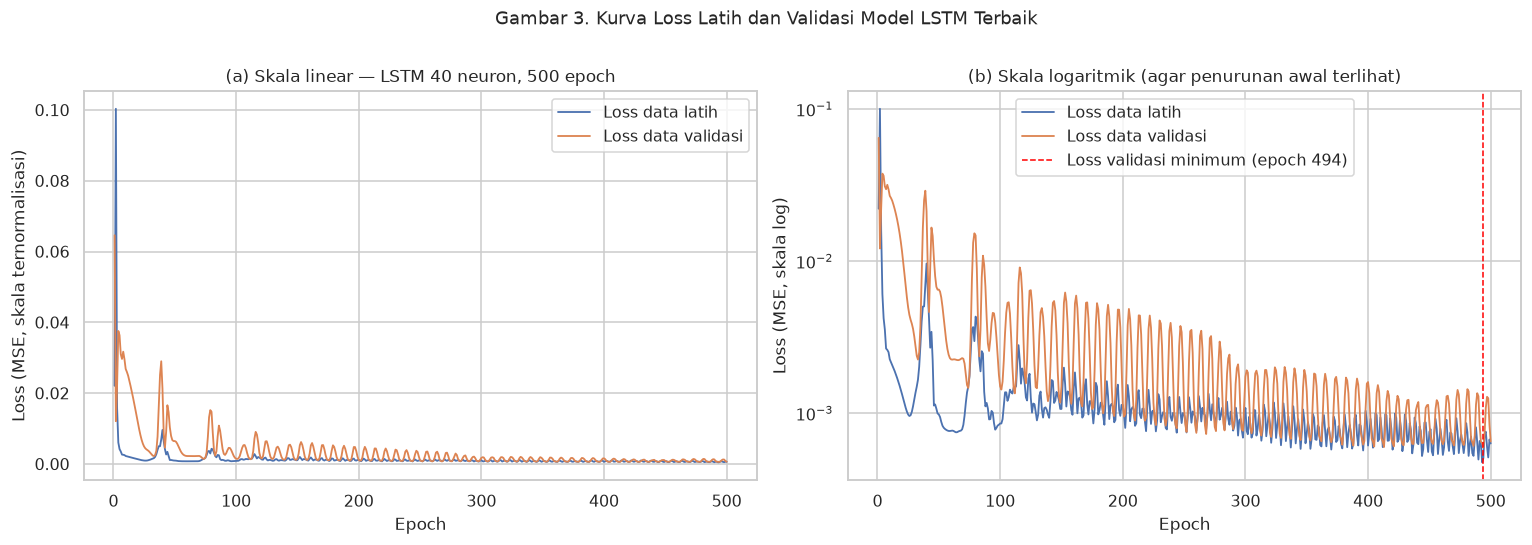


  Loss latih    epoch pertama : 0.02209279
  Loss latih    epoch terakhir: 0.00063068
  Loss validasi epoch pertama : 0.06462061
  Loss validasi epoch terakhir: 0.00065024
  Loss validasi minimum       : 0.00059231 (epoch 494)
  Penurunan loss latih        : 97.15% dari epoch pertama

  Interpretasi: loss latih dan loss validasi menurun bersama-sama pada
  awal pelatihan. Jika loss validasi mulai naik sementara loss latih terus
  menurun, itu tanda overfitting; pemilihan jumlah epoch lewat data
  validasi pada Tahap 7.1 sudah memperhitungkan hal ini.


In [23]:
utils.cetak_sub("7.6 Gambar 3 — Kurva loss latih dan validasi model LSTM terbaik")

loss_latih = riwayat_lstm.history["loss"]
loss_val = riwayat_lstm.history["val_loss"]
epoch_terbaik_val = int(np.argmin(loss_val)) + 1

fig, sumbu = plt.subplots(1, 2, figsize=(14, 4.8))

sumbu[0].plot(range(1, len(loss_latih) + 1), loss_latih, label="Loss data latih", linewidth=1.2)
sumbu[0].plot(range(1, len(loss_val) + 1), loss_val, label="Loss data validasi", linewidth=1.2)
sumbu[0].set_title(f"(a) Skala linear — LSTM {neuron_lstm} neuron, {epoch_lstm} epoch")
sumbu[0].set_xlabel("Epoch"); sumbu[0].set_ylabel("Loss (MSE, skala ternormalisasi)")
sumbu[0].legend()

sumbu[1].semilogy(range(1, len(loss_latih) + 1), loss_latih, label="Loss data latih", linewidth=1.2)
sumbu[1].semilogy(range(1, len(loss_val) + 1), loss_val, label="Loss data validasi", linewidth=1.2)
sumbu[1].axvline(epoch_terbaik_val, color="red", linestyle="--", linewidth=1,
                 label=f"Loss validasi minimum (epoch {epoch_terbaik_val})")
sumbu[1].set_title("(b) Skala logaritmik (agar penurunan awal terlihat)")
sumbu[1].set_xlabel("Epoch"); sumbu[1].set_ylabel("Loss (MSE, skala log)")
sumbu[1].legend()

fig.suptitle("Gambar 3. Kurva Loss Latih dan Validasi Model LSTM Terbaik", fontsize=12, y=1.02)
fig.tight_layout()
utils.simpan_gambar(fig, 3, "Kurva loss latih dan validasi model LSTM terbaik")
plt.show()

print(f"\n  Loss latih    epoch pertama : {loss_latih[0]:.8f}")
print(f"  Loss latih    epoch terakhir: {loss_latih[-1]:.8f}")
print(f"  Loss validasi epoch pertama : {loss_val[0]:.8f}")
print(f"  Loss validasi epoch terakhir: {loss_val[-1]:.8f}")
print(f"  Loss validasi minimum       : {min(loss_val):.8f} (epoch {epoch_terbaik_val})")
print(f"  Penurunan loss latih        : "
      f"{(1 - loss_latih[-1] / loss_latih[0]) * 100:.2f}% dari epoch pertama")
print("\n  Interpretasi: loss latih dan loss validasi menurun bersama-sama pada")
print("  awal pelatihan. Jika loss validasi mulai naik sementara loss latih terus")
print("  menurun, itu tanda overfitting; pemilihan jumlah epoch lewat data")
print("  validasi pada Tahap 7.1 sudah memperhitungkan hal ini.")

### 7.E Verifikasi manual *forward pass* LSTM (bagian terpenting)

Bagian ini membuktikan bahwa **rumus LSTM yang ditulis di Bab III benar-benar
rumus yang dijalankan Keras**. Caranya: bobot hasil pelatihan diambil apa adanya,
lalu $\hat{y}$ dihitung ulang dari nol memakai NumPy — hanya operasi perkalian
matriks, sigmoid, dan tanh — dan hasilnya dibandingkan dengan `model.predict()`.

**Urutan bobot pada Keras.** Keras menyimpan keempat gerbang secara berurutan di
dalam satu matriks besar dengan urutan **i, f, c, o**:

$$\mathbf{W} = \big[\;\underbrace{\mathbf{W}_i}_{\text{kolom }1..n}\;
\underbrace{\mathbf{W}_f}_{n+1..2n}\;
\underbrace{\mathbf{W}_c}_{2n+1..3n}\;
\underbrace{\mathbf{W}_o}_{3n+1..4n}\;\big]$$

**Keadaan awal.** $\mathbf{h}_0 = \mathbf{0}$ dan $\mathbf{c}_0 = \mathbf{0}$
(vektor nol), sesuai perilaku baku Keras.

**Alur perhitungan.**

$$\mathbf{h}_0, \mathbf{c}_0 = \mathbf{0}
\;\xrightarrow{\;\mathbf{x}_1\;} \mathbf{h}_1, \mathbf{c}_1
\;\xrightarrow{\;\mathbf{x}_2\;} \mathbf{h}_2, \mathbf{c}_2
\;\longrightarrow \cdots \longrightarrow\;
\mathbf{h}_7 \;\xrightarrow{\;\text{Dense}\;}\; \hat{y}$$

In [24]:
utils.cetak_sub("7.7 PERHITUNGAN MANUAL — forward pass LSTM (jendela pertama data uji)")

baris_manual = []


def tulis(teks: str = "") -> None:
    print(teks)
    baris_manual.append(teks)


def sigmoid(z):
    """Fungsi aktivasi sigmoid: sigma(z) = 1 / (1 + exp(-z))."""
    return 1.0 / (1.0 + np.exp(-z))


u = neuron_lstm

# --- Pemecahan bobot sesuai urutan Keras: i, f, c, o ----------------------- #
W_i, W_f, W_c, W_o = np.split(W_lstm, 4, axis=1)
U_i, U_f, U_c, U_o = np.split(U_lstm, 4, axis=1)
b_i, b_f, b_c, b_o = np.split(b_lstm, 4)

tulis("(a) PEMECAHAN BOBOT KERAS SESUAI URUTAN i, f, c, o")
tulis()
tulis(f"Matriks gabungan kernel W          : {W_lstm.shape}")
tulis(f"Matriks gabungan recurrent U       : {U_lstm.shape}")
tulis(f"Vektor gabungan bias b             : {b_lstm.shape}")
tulis(f"Jumlah unit (neuron) n_unit        : {u}")
tulis()
tulis("Setelah dipecah menjadi empat bagian:")
tulis(f"  {'Gerbang':<26}{'W (fitur x unit)':>20}{'U (unit x unit)':>20}{'b (unit)':>12}")
for nama_gerbang, Wg, Ug, bg in [
    ("i (input gate)", W_i, U_i, b_i),
    ("f (forget gate)", W_f, U_f, b_f),
    ("c (kandidat cell)", W_c, U_c, b_c),
    ("o (output gate)", W_o, U_o, b_o),
]:
    tulis(f"  {nama_gerbang:<26}{str(Wg.shape):>20}{str(Ug.shape):>20}{str(bg.shape):>12}")
tulis()
tulis("Contoh nilai bobot untuk NEURON KE-1 (kolom pertama tiap matriks):")
tulis()
for nama_gerbang, Wg, Ug, bg in [
    ("i (input)", W_i, U_i, b_i), ("f (forget)", W_f, U_f, b_f),
    ("c (kandidat)", W_c, U_c, b_c), ("o (output)", W_o, U_o, b_o),
]:
    tulis(f"  Gerbang {nama_gerbang}")
    tulis(f"    W[:,1] (10 bobot masukan) = {ringkas_vektor(Wg[:, 0], 10)}")
    tulis(f"    U[:,1] (bobot rekuren)    = {ringkas_vektor(Ug[:, 0], 6)}")
    tulis(f"    b[1]   (bias)             = {bg[0]:.6f}")
tulis()
tulis("Catatan: bias gerbang f (forget) bernilai sekitar 1 pada awal pelatihan")
tulis("karena Keras memakai unit_forget_bias=True, yaitu strategi agar memori")
tulis("jangka panjang tidak langsung terlupakan di awal pelatihan.")
tulis()


----------------------------------------------------------------------
7.7 PERHITUNGAN MANUAL — forward pass LSTM (jendela pertama data uji)
----------------------------------------------------------------------
(a) PEMECAHAN BOBOT KERAS SESUAI URUTAN i, f, c, o

Matriks gabungan kernel W          : (10, 160)
Matriks gabungan recurrent U       : (40, 160)
Vektor gabungan bias b             : (160,)
Jumlah unit (neuron) n_unit        : 40

Setelah dipecah menjadi empat bagian:
  Gerbang                       W (fitur x unit)     U (unit x unit)    b (unit)
  i (input gate)                        (10, 40)            (40, 40)       (40,)
  f (forget gate)                       (10, 40)            (40, 40)       (40,)
  c (kandidat cell)                     (10, 40)            (40, 40)       (40,)
  o (output gate)                       (10, 40)            (40, 40)       (40,)

Contoh nilai bobot untuk NEURON KE-1 (kolom pertama tiap matriks):

  Gerbang i (input)
    W[:,1] (10 bobot mas

In [25]:
# --- Forward pass manual seluruh timestep ---------------------------------- #
jendela_uji = X_uji[0].astype(np.float64)          # bentuk (7, 10)
tanggal_jendela_uji = [pd.Timestamp(t).date()
                       for t in df_bersih["date"].to_numpy()[idx_uji[0] - LOOKBACK:idx_uji[0]]]
tanggal_target_uji = pd.Timestamp(tanggal_uji[0]).date()

tulis("(b) FORWARD PASS MANUAL DENGAN NUMPY — JENDELA PERTAMA DATA UJI")
tulis()
tulis(f"Masukan  : X_uji[0] berbentuk {jendela_uji.shape} "
      f"({tanggal_jendela_uji[0]} s.d. {tanggal_jendela_uji[-1]})")
tulis(f"Target    : Close Price {tanggal_target_uji} = "
      f"{utils.fmt_usd(aktual_uji_usd[0])} USD")
tulis(f"Keadaan awal: h_0 = vektor nol ({u} elemen), c_0 = vektor nol ({u} elemen)")
tulis()

h_t = np.zeros(u, dtype=np.float64)
c_t = np.zeros(u, dtype=np.float64)
jejak = []

for t in range(LOOKBACK):
    x_t = jendela_uji[t]
    h_sebelum, c_sebelum = h_t.copy(), c_t.copy()

    # Pra-aktivasi keempat gerbang
    z_i = x_t @ W_i + h_sebelum @ U_i + b_i
    z_f = x_t @ W_f + h_sebelum @ U_f + b_f
    z_c = x_t @ W_c + h_sebelum @ U_c + b_c
    z_o = x_t @ W_o + h_sebelum @ U_o + b_o

    # Setelah aktivasi
    i_t = sigmoid(z_i)
    f_t = sigmoid(z_f)
    c_kandidat = np.tanh(z_c)
    o_t = sigmoid(z_o)

    # Pembaruan cell state dan hidden state
    c_t = f_t * c_sebelum + i_t * c_kandidat
    h_t = o_t * np.tanh(c_t)

    jejak.append({
        "t": t + 1, "tanggal": tanggal_jendela_uji[t], "x_t": x_t,
        "h_sebelum": h_sebelum, "c_sebelum": c_sebelum,
        "z_i": z_i, "z_f": z_f, "z_c": z_c, "z_o": z_o,
        "i": i_t, "f": f_t, "c_kandidat": c_kandidat, "o": o_t,
        "c": c_t.copy(), "h": h_t.copy(),
    })

    # --- Cetak rincian lengkap untuk timestep 1 dan 2 --------------------- #
    if t < 2:
        j = jejak[-1]
        tulis("=" * 66)
        tulis(f"RINCIAN TIMESTEP t = {t + 1}  (tanggal {j['tanggal']})")
        tulis("=" * 66)
        tulis(f"  {f'x_{t + 1} (10 fitur ternormalisasi)':<34}= {ringkas_vektor(x_t, 10)}")
        tulis(f"  {f'h_{t} (hidden state sebelumnya)':<34}= {ringkas_vektor(h_sebelum, 6)}")
        tulis(f"  {f'c_{t} (cell state sebelumnya)':<34}= {ringkas_vektor(c_sebelum, 6)}")
        tulis()
        tulis("  --- RINCIAN NEURON KE-1 ---")
        for lambang, nama_panjang, Wg, Ug, bg, z_vec, akt_vec, aktivasi in [
            ("i", "input gate", W_i, U_i, b_i, z_i, i_t, "sigmoid"),
            ("f", "forget gate", W_f, U_f, b_f, z_f, f_t, "sigmoid"),
            ("c~", "kandidat cell", W_c, U_c, b_c, z_c, c_kandidat, "tanh"),
            ("o", "output gate", W_o, U_o, b_o, z_o, o_t, "sigmoid"),
        ]:
            sumbangan_x = float(x_t @ Wg[:, 0])
            sumbangan_h = float(h_sebelum @ Ug[:, 0])
            tulis(f"  Gerbang {lambang} ({nama_panjang}):")
            tulis(f"    pra-aktivasi z = x_t.W[:,1] + h_(t-1).U[:,1] + b[1]")
            tulis(f"                   = {sumbangan_x:+.6f} {sumbangan_h:+.6f} "
                  f"{float(bg[0]):+.6f}")
            tulis(f"                   = {float(z_vec[0]):+.6f}")
            tulis(f"    setelah {aktivasi:<7} = {aktivasi}({float(z_vec[0]):+.6f}) "
                  f"= {float(akt_vec[0]):.6f}")
        tulis()
        sela = " " * 11
        tulis(f"  c_{t + 1}[1] = f[1] * c_{t}[1] + i[1] * c~[1]")
        tulis(f"{sela}= {float(f_t[0]):.6f} * {float(c_sebelum[0]):+.6f} "
              f"+ {float(i_t[0]):.6f} * {float(c_kandidat[0]):+.6f}")
        tulis(f"{sela}= {float(f_t[0] * c_sebelum[0]):+.6f} "
              f"+ {float(i_t[0] * c_kandidat[0]):+.6f}")
        tulis(f"{sela}= {float(c_t[0]):+.6f}")
        tulis()
        tulis(f"  h_{t + 1}[1] = o[1] * tanh(c_{t + 1}[1])")
        tulis(f"{sela}= {float(o_t[0]):.6f} * tanh({float(c_t[0]):+.6f})")
        tulis(f"{sela}= {float(o_t[0]):.6f} * {float(np.tanh(c_t[0])):+.6f}")
        tulis(f"{sela}= {float(h_t[0]):+.6f}")
        tulis()
        tulis("  --- VEKTOR LENGKAP TIMESTEP INI ---")
        tulis(f"    i_{t + 1}  = {ringkas_vektor(i_t)}")
        tulis(f"    f_{t + 1}  = {ringkas_vektor(f_t)}")
        tulis(f"    c~_{t + 1} = {ringkas_vektor(c_kandidat)}")
        tulis(f"    o_{t + 1}  = {ringkas_vektor(o_t)}")
        tulis(f"    c_{t + 1}  = {ringkas_vektor(c_t)}")
        tulis(f"    h_{t + 1}  = {ringkas_vektor(h_t)}")
        tulis()

tulis("(c) RINGKASAN SELURUH TIMESTEP (neuron ke-1)")
tulis()
tabel_jejak_lstm = pd.DataFrame([{
    "t": j["t"], "Tanggal": j["tanggal"],
    "i[1]": j["i"][0], "f[1]": j["f"][0], "c~[1]": j["c_kandidat"][0],
    "o[1]": j["o"][0], "c[1]": j["c"][0], "h[1]": j["h"][0],
} for j in jejak])
with pd.option_context("display.float_format", lambda v: f"{v:,.6f}"):
    tulis(tabel_jejak_lstm.to_string(index=False))
tulis()

(b) FORWARD PASS MANUAL DENGAN NUMPY — JENDELA PERTAMA DATA UJI

Masukan  : X_uji[0] berbentuk (7, 10) (2025-12-11 s.d. 2025-12-17)
Target    : Close Price 2025-12-18 = 86,132.82 USD
Keadaan awal: h_0 = vektor nol (40 elemen), c_0 = vektor nol (40 elemen)

RINCIAN TIMESTEP t = 1  (tanggal 2025-12-11)
  x_1 (10 fitur ternormalisasi)     = [0.680495, 0.297207, 1.112427, 1.035626, 0.507183, 0.393311, 0.235063, 0.373105, 0.336586, 0.053572]  (panjang 10)
  h_0 (hidden state sebelumnya)     = [0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, ...]  (panjang 40)
  c_0 (cell state sebelumnya)       = [0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, ...]  (panjang 40)

  --- RINCIAN NEURON KE-1 ---
  Gerbang i (input gate):
    pra-aktivasi z = x_t.W[:,1] + h_(t-1).U[:,1] + b[1]
                   = -0.229851 +0.000000 -0.342494
                   = -0.572345
    setelah sigmoid = sigmoid(-0.572345) = 0.360696
  Gerbang f (forget gate):
    pra-aktivasi z = x_t.W[:,1] + h

In [26]:
# --- Lapisan Dense dan pembandingan dengan Keras --------------------------- #
tulis("(d) LAPISAN DENSE — y_hat = h_T . W_y + b_y")
tulis()
h_akhir = jejak[-1]["h"]
tulis(f"  h_T (hidden state timestep terakhir, T = {LOOKBACK}) = {ringkas_vektor(h_akhir)}")
tulis(f"  W_y (bobot Dense) = {ringkas_vektor(Wy_lstm.ravel())}")
tulis(f"  b_y (bias Dense)  = {float(by_lstm[0]):+.6f}")
tulis()
suku_dense = h_akhir * Wy_lstm.ravel()
tulis("  Perkalian suku demi suku (enam suku pertama):")
for k in range(min(6, u)):
    tulis(f"    h_T[{k + 1}] * W_y[{k + 1}] = {h_akhir[k]:+.6f} * "
          f"{float(Wy_lstm[k, 0]):+.6f} = {suku_dense[k]:+.6f}")
if u > 6:
    tulis(f"    ... ({u - 6} suku lainnya)")
tulis(f"  Jumlah seluruh suku = {float(suku_dense.sum()):+.6f}")
y_hat_manual = float(suku_dense.sum() + by_lstm[0])
tulis(f"  y_hat = {float(suku_dense.sum()):+.6f} + {float(by_lstm[0]):+.6f} "
      f"= {y_hat_manual:.8f}   (skala ternormalisasi)")
tulis()

tulis("(e) PEMBANDINGAN DENGAN model.predict() DARI KERAS")
tulis()
y_hat_keras = float(model_lstm.predict(X_uji[:1], verbose=0)[0, 0])
selisih = abs(y_hat_manual - y_hat_keras)
tulis(f"  Hasil manual NumPy   : {y_hat_manual:.10f}")
tulis(f"  Hasil model.predict(): {y_hat_keras:.10f}")
tulis(f"  Selisih absolut      : {selisih:.3e}")
tulis()
y_hat_manual_usd = float(ke_usd([y_hat_manual])[0])
y_hat_keras_usd = float(ke_usd([y_hat_keras])[0])
tulis(f"  Dalam skala USD:")
tulis(f"    Prediksi manual      : {utils.fmt_usd(y_hat_manual_usd)} USD")
tulis(f"    Prediksi Keras       : {utils.fmt_usd(y_hat_keras_usd)} USD")
tulis(f"    Harga aktual {tanggal_target_uji} : {utils.fmt_usd(aktual_uji_usd[0])} USD")
tulis()

np.testing.assert_allclose(y_hat_manual, y_hat_keras, atol=1e-5)
assert selisih < 1e-5, "Forward pass manual LSTM tidak cocok dengan Keras"
tulis("  OK Hasil manual SAMA dengan hasil model (toleransi 1e-5)")
tulis()
tulis("Artinya rumus LSTM pada Bab III benar-benar rumus yang dijalankan Keras:")
tulis("gerbang lupa, gerbang masukan, kandidat cell, pembaruan cell state,")
tulis("gerbang keluaran, hidden state, dan lapisan Dense — seluruhnya terbukti.")

print("\n✔ Hasil manual SAMA dengan hasil model")

utils.tulis_manual("7_forward_pass_lstm", "Forward Pass LSTM (Jendela Pertama Data Uji)", f"""
## Rumus yang diverifikasi

$$\\mathbf{{f}}_t = \\sigma(\\mathbf{{x}}_t\\mathbf{{W}}_f + \\mathbf{{h}}_{{t-1}}\\mathbf{{U}}_f + \\mathbf{{b}}_f)
\\qquad
\\mathbf{{i}}_t = \\sigma(\\mathbf{{x}}_t\\mathbf{{W}}_i + \\mathbf{{h}}_{{t-1}}\\mathbf{{U}}_i + \\mathbf{{b}}_i)$$

$$\\tilde{{\\mathbf{{c}}}}_t = \\tanh(\\mathbf{{x}}_t\\mathbf{{W}}_c + \\mathbf{{h}}_{{t-1}}\\mathbf{{U}}_c + \\mathbf{{b}}_c)
\\qquad
\\mathbf{{c}}_t = \\mathbf{{f}}_t \\odot \\mathbf{{c}}_{{t-1}} + \\mathbf{{i}}_t \\odot \\tilde{{\\mathbf{{c}}}}_t$$

$$\\mathbf{{o}}_t = \\sigma(\\mathbf{{x}}_t\\mathbf{{W}}_o + \\mathbf{{h}}_{{t-1}}\\mathbf{{U}}_o + \\mathbf{{b}}_o)
\\qquad
\\mathbf{{h}}_t = \\mathbf{{o}}_t \\odot \\tanh(\\mathbf{{c}}_t)
\\qquad
\\hat{{y}} = \\mathbf{{h}}_T\\mathbf{{W}}_y + b_y$$

Urutan penyimpanan bobot pada Keras: **i, f, c, o**.
Keadaan awal $\\mathbf{{h}}_0 = \\mathbf{{c}}_0 = \\mathbf{{0}}$.

## Perhitungan

{utils.blok_kode(chr(10).join(baris_manual))}

## Kesimpulan

Prediksi hasil hitung tangan dengan NumPy sebesar
`{y_hat_manual:.10f}` (ternormalisasi) atau **{utils.fmt_usd(y_hat_manual_usd)} USD**,
sedangkan `model.predict()` Keras menghasilkan `{y_hat_keras:.10f}`. Selisih
keduanya hanya {selisih:.2e}, jauh di bawah toleransi $10^{{-5}}$, sehingga rumus
LSTM yang ditulis pada Bab III terbukti identik dengan implementasi Keras.
""")

(d) LAPISAN DENSE — y_hat = h_T . W_y + b_y

  h_T (hidden state timestep terakhir, T = 7) = [-0.059288, 0.033720, -0.036911, 0.038392, 0.102880, 0.008137, ...]  (panjang 40)
  W_y (bobot Dense) = [0.164646, 0.297487, -0.051887, 0.160470, 0.265961, 0.041397, ...]  (panjang 40)
  b_y (bias Dense)  = +0.081419

  Perkalian suku demi suku (enam suku pertama):
    h_T[1] * W_y[1] = -0.059288 * +0.164646 = -0.009762
    h_T[2] * W_y[2] = +0.033720 * +0.297487 = +0.010031
    h_T[3] * W_y[3] = -0.036911 * -0.051887 = +0.001915
    h_T[4] * W_y[4] = +0.038392 * +0.160470 = +0.006161
    h_T[5] * W_y[5] = +0.102880 * +0.265961 = +0.027362
    h_T[6] * W_y[6] = +0.008137 * +0.041397 = +0.000337
    ... (34 suku lainnya)
  Jumlah seluruh suku = +0.560887
  y_hat = +0.560887 + +0.081419 = 0.64230636   (skala ternormalisasi)

(e) PEMBANDINGAN DENGAN model.predict() DARI KERAS

  Hasil manual NumPy   : 0.6423063572
  Hasil model.predict(): 0.6423063278
  Selisih absolut      : 2.940e-08

  Dalam sk

'/home/user/prediction-lstm-gru-btc/outputs/perhitungan_manual/tahap_7_forward_pass_lstm.md'

In [27]:
utils.cetak_sub("7.8 Prediksi model LSTM pada data uji")

prediksi_uji_lstm_norm = model_lstm.predict(X_uji, verbose=0).ravel()
prediksi_uji_lstm_usd = ke_usd(prediksi_uji_lstm_norm)
prediksi_val_lstm_usd = ke_usd(model_lstm.predict(X_val, verbose=0))

utils.cetak_shape("prediksi_uji_lstm_norm", prediksi_uji_lstm_norm)
print(f"  Jumlah hari uji yang diprediksi : {utils.fmt_int(len(prediksi_uji_lstm_usd))}")
print(f"  Rentang prediksi (ternormalisasi): "
      f"[{prediksi_uji_lstm_norm.min():.6f}, {prediksi_uji_lstm_norm.max():.6f}]")
print(f"  Rentang prediksi (USD)           : "
      f"[{utils.fmt_usd(prediksi_uji_lstm_usd.min())}, {utils.fmt_usd(prediksi_uji_lstm_usd.max())}]")
print(f"  Rentang harga aktual (USD)       : "
      f"[{utils.fmt_usd(aktual_uji_usd.min())}, {utils.fmt_usd(aktual_uji_usd.max())}]")

print("\n  Lima prediksi pertama:")
print(f"    {'Tanggal':<12}{'Aktual (USD)':>16}{'Prediksi LSTM (USD)':>22}{'Galat (USD)':>16}")
for k in range(5):
    galat = aktual_uji_usd[k] - prediksi_uji_lstm_usd[k]
    print(f"    {str(pd.Timestamp(tanggal_uji[k]).date()):<12}"
          f"{utils.fmt_usd(aktual_uji_usd[k]):>16}"
          f"{utils.fmt_usd(prediksi_uji_lstm_usd[k]):>22}{utils.fmt_usd(galat):>16}")

# Prediksi hari pertama harus sama dengan hasil forward pass manual
assert np.isclose(prediksi_uji_lstm_norm[0], y_hat_manual, atol=1e-5)
print("\n  OK Prediksi hari pertama konsisten dengan forward pass manual.")

utils.ringkasan_tahap(f"""
Lima belas kombinasi hyperparameter LSTM telah dilatih dengan pengaturan
identik, dan konfigurasi terbaik menurut RMSE DATA VALIDASI adalah
{neuron_lstm} neuron dengan {epoch_lstm} epoch (RMSE validasi
{utils.fmt_usd(tabel_tuning_lstm.loc[posisi_terbaik_lstm, 'RMSE Validasi (USD)'])} USD,
MAPE validasi {tabel_tuning_lstm.loc[posisi_terbaik_lstm, 'MAPE Validasi (%)']:.4f}%).
Model ini memiliki {utils.fmt_int(model_lstm.count_params())} parameter dan
membutuhkan {waktu_lstm:,.2f} detik untuk dilatih.

Jumlah parameter hasil hitung tangan dengan rumus
4 x (n_unit x (n_unit + n_fitur) + n_unit) terbukti sama dengan keluaran
model.summary(), dan yang terpenting: forward pass yang dihitung ulang dari nol
dengan NumPy menghasilkan angka yang sama dengan model.predict() sampai
selisih {selisih:.1e}.

Dengan demikian seluruh rumus LSTM pada Bab III sudah tervalidasi secara
numerik, dan model siap dibandingkan dengan GRU pada Tahap 8.
""")


----------------------------------------------------------------------
7.8 Prediksi model LSTM pada data uji
----------------------------------------------------------------------


  shape prediksi_uji_lstm_norm       = (226,)
  Jumlah hari uji yang diprediksi : 226
  Rentang prediksi (ternormalisasi): [0.341228, 0.741678]
  Rentang prediksi (USD)           : [58,670.20, 97,993.05]
  Rentang harga aktual (USD)       : [58,534.28, 96,931.94]

  Lima prediksi pertama:
    Tanggal         Aktual (USD)   Prediksi LSTM (USD)     Galat (USD)
    2025-12-18         86,132.82             88,235.09       -2,102.27
    2025-12-19         85,458.35             86,359.86         -901.51
    2025-12-20         88,098.82             85,962.64        2,136.17
    2025-12-21         88,337.41             87,684.05          653.36
    2025-12-22         88,615.72             87,909.55          706.17

  OK Prediksi hari pertama konsisten dengan forward pass manual.

RINGKASAN TAHAP
Lima belas kombinasi hyperparameter LSTM telah dilatih dengan
pengaturan identik, dan konfigurasi terbaik menurut RMSE DATA VALIDASI
adalah 40 neuron dengan 500 epoch (RMSE validasi 2,503.99 USD, MAPE


---
## TAHAP 8 — Model GRU (*Gated Recurrent Unit*)

### 8.A Rumus lengkap GRU (konvensi Keras)

GRU adalah penyederhanaan LSTM: hanya **dua gerbang** dan **tanpa *cell state*
terpisah** — memori disimpan langsung pada $\mathbf{h}_t$.

**1. Gerbang pembaruan (*update gate*)** — menentukan porsi memori lama yang dipertahankan:

$$\mathbf{z}_t = \sigma\!\left(\mathbf{x}_t\mathbf{W}_z + \mathbf{h}_{t-1}\mathbf{U}_z
+ \mathbf{b}_z^{(in)} + \mathbf{b}_z^{(rec)}\right)$$

**2. Gerbang reset (*reset gate*)** — menentukan porsi memori lama yang dipakai menyusun kandidat baru:

$$\mathbf{r}_t = \sigma\!\left(\mathbf{x}_t\mathbf{W}_r + \mathbf{h}_{t-1}\mathbf{U}_r
+ \mathbf{b}_r^{(in)} + \mathbf{b}_r^{(rec)}\right)$$

**3. Kandidat *hidden state*** — dengan `reset_after=True` (baku Keras):

$$\tilde{\mathbf{h}}_t = \tanh\!\left(\mathbf{x}_t\mathbf{W}_h + \mathbf{b}_h^{(in)}
+ \mathbf{r}_t \odot \left(\mathbf{h}_{t-1}\mathbf{U}_h + \mathbf{b}_h^{(rec)}\right)\right)$$

**4. *Hidden state* baru** — konvensi Keras:

$$\mathbf{h}_t = \mathbf{z}_t \odot \mathbf{h}_{t-1} + \left(1 - \mathbf{z}_t\right) \odot \tilde{\mathbf{h}}_t$$

**5. Lapisan keluaran:** $\hat{y} = \mathbf{h}_T\mathbf{W}_y + b_y$

### 8.B Perbedaan dengan rumus GRU pada buku teks (Cho dkk., 2014)

| Aspek | Cho dkk. (2014) | Keras (`reset_after=True`) |
|---|---|---|
| Posisi penerapan gerbang reset | **sebelum** perkalian matriks: $\tanh\!\left(\mathbf{x}_t\mathbf{W}_h + (\mathbf{r}_t \odot \mathbf{h}_{t-1})\mathbf{U}_h\right)$ | **sesudah** perkalian matriks: $\tanh\!\left(\mathbf{x}_t\mathbf{W}_h + \mathbf{r}_t \odot (\mathbf{h}_{t-1}\mathbf{U}_h)\right)$ |
| Peran gerbang $\mathbf{z}_t$ | $\mathbf{h}_t = (1-\mathbf{z}_t)\odot\mathbf{h}_{t-1} + \mathbf{z}_t\odot\tilde{\mathbf{h}}_t$ — $\mathbf{z}$ = bobot **informasi baru** | $\mathbf{h}_t = \mathbf{z}_t\odot\mathbf{h}_{t-1} + (1-\mathbf{z}_t)\odot\tilde{\mathbf{h}}_t$ — $\mathbf{z}$ = bobot **memori lama** |
| Jumlah bias | satu himpunan, $3 \times n_{unit}$ | **dua** himpunan, $(2, 3 \times n_{unit})$ |

**Mengapa Keras memakai bentuk ini?** Dengan menerapkan $\mathbf{r}_t$ *setelah*
perkalian matriks, seluruh perkalian $\mathbf{h}_{t-1}\mathbf{U}$ untuk ketiga
gerbang dapat dihitung satu kali sekaligus, sehingga kompatibel dengan kernel
cuDNN yang jauh lebih cepat. Konsekuensinya diperlukan **dua himpunan bias**:
$\mathbf{b}^{(in)}$ untuk jalur masukan dan $\mathbf{b}^{(rec)}$ untuk jalur
rekuren.

$\Rightarrow$ **Perhitungan manual pada tahap ini WAJIB mengikuti rumus Keras
di atas**, bukan rumus buku teks, agar hasilnya sama dengan `model.predict()`.
Perbedaan kedua konvensi bersifat *reparameterisasi*: keduanya sama-sama sah
sebagai GRU, hanya berbeda cara penulisan dan tempat bias.

### 8.C Urutan bobot pada Keras: **z, r, h**

$$\mathbf{W} = \big[\;\mathbf{W}_z\;\;\mathbf{W}_r\;\;\mathbf{W}_h\;\big],
\qquad
\mathbf{b} = \begin{bmatrix}\mathbf{b}_z^{(in)} & \mathbf{b}_r^{(in)} & \mathbf{b}_h^{(in)}\\
\mathbf{b}_z^{(rec)} & \mathbf{b}_r^{(rec)} & \mathbf{b}_h^{(rec)}\end{bmatrix}
\in \mathbb{R}^{2 \times 3n_{unit}}$$

### 8.D Jumlah parameter

$$\text{Param}_{\text{GRU}} = 3 \times \left(n_{unit} \times \left(n_{unit} + n_{fitur}\right)
+ 2 \times n_{unit}\right)$$

Angka $2 \times n_{unit}$ pada suku bias merupakan konsekuensi langsung dari
`reset_after=True` yang memerlukan dua himpunan bias.

### 8.E Perbandingan yang adil

Seluruh pengaturan **sama persis** dengan Tahap 7 — data, *window*, grid
*hyperparameter*, *batch size*, *optimizer*, *learning rate*, dan *seed* —
memakai fungsi `bangun_model()` dan `latih_model()` yang identik. Satu-satunya
perbedaan adalah jenis lapisan rekuren.

In [28]:
utils.cetak_header(8, "Model GRU")

utils.cetak_sub("8.1 Tuning hyperparameter GRU (5 neuron x 3 epoch = 15 model)")
print("  Memakai fungsi bangun_model() dan latih_model() YANG SAMA dengan Tahap 7,")
print("  dengan data, grid, batch size, optimizer, dan seed yang identik.\n")

tabel_tuning_gru, kumpulan_gru = jalankan_tuning("GRU")

TAHAP 8 - MODEL GRU

----------------------------------------------------------------------
8.1 Tuning hyperparameter GRU (5 neuron x 3 epoch = 15 model)
----------------------------------------------------------------------
  Memakai fungsi bangun_model() dan latih_model() YANG SAMA dengan Tahap 7,
  dengan data, grid, batch size, optimizer, dan seed yang identik.

  No   Neuron  Epoch   RMSE Val (USD)   MAPE Val (%)  Waktu (detik)  Detik/Epoch
  ------------------------------------------------------------------------------


  1        10    100         8,899.66         7.9403          17.03       0.1703


  2        10    500         3,515.15         2.7970          79.07       0.1581


  3        10   1000         2,643.55         2.0426         158.01       0.1580


  4        20    100         3,944.11         3.0962          17.84       0.1784


...

  11       40    500         3,000.19         2.3656          81.76       0.1635


  12       40   1000         3,327.18         2.6279         164.71       0.1647


  13       50    100         7,911.04         7.1960          18.37       0.1837


  14       50    500         2,907.13         2.3094          86.45       0.1729


  15       50   1000         2,680.68         2.0891         167.44       0.1674
  ------------------------------------------------------------------------------
  Total waktu tuning GRU: 22.05 menit (15 model)


In [29]:
utils.cetak_sub("8.2 Tabel 11 — Hasil tuning hyperparameter model GRU")

posisi_terbaik_gru = int(tabel_tuning_gru["RMSE Validasi (USD)"].idxmin())
tabel_tampil_gru = tabel_tuning_gru.copy()
tabel_tampil_gru["Keterangan"] = ""
tabel_tampil_gru.loc[posisi_terbaik_gru, "Keterangan"] = "<<< TERBAIK (RMSE validasi terkecil)"

with pd.option_context("display.float_format", lambda v: f"{v:,.4f}"):
    print(tabel_tampil_gru[["No", "Neuron", "Epoch", "RMSE Validasi (USD)",
                            "MAPE Validasi (%)", "Waktu Latih (detik)",
                            "Jumlah Parameter", "Keterangan"]].to_string(index=False))
utils.simpan_tabel(tabel_tampil_gru, 11, "Hasil tuning hyperparameter model GRU")

neuron_gru = int(tabel_tuning_gru.loc[posisi_terbaik_gru, "Neuron"])
epoch_gru = int(tabel_tuning_gru.loc[posisi_terbaik_gru, "Epoch"])
model_gru, riwayat_gru, waktu_gru = kumpulan_gru[(neuron_gru, epoch_gru)]

print(f"\n  KONFIGURASI TERBAIK GRU (dipilih dari RMSE DATA VALIDASI):")
print(f"    Jumlah neuron        : {neuron_gru}")
print(f"    Jumlah epoch         : {epoch_gru}")
print(f"    RMSE validasi        : {utils.fmt_usd(tabel_tuning_gru.loc[posisi_terbaik_gru, 'RMSE Validasi (USD)'])} USD")
print(f"    MAPE validasi        : {tabel_tuning_gru.loc[posisi_terbaik_gru, 'MAPE Validasi (%)']:.4f} %")
print(f"    Waktu latih          : {waktu_gru:,.2f} detik "
      f"({waktu_gru / epoch_gru:.4f} detik/epoch)")
print(f"    Jumlah parameter     : {utils.fmt_int(model_gru.count_params())}")

utils.cetak_sub("8.3 Ringkasan arsitektur model GRU terbaik")
model_gru.summary(print_fn=lambda t: print("  " + t))


----------------------------------------------------------------------
8.2 Tabel 11 — Hasil tuning hyperparameter model GRU
----------------------------------------------------------------------
 No  Neuron  Epoch  RMSE Validasi (USD)  MAPE Validasi (%)  Waktu Latih (detik)  Jumlah Parameter                           Keterangan
  1      10    100           8,899.6582             7.9403              17.0319               671                                     
  2      10    500           3,515.1483             2.7970              79.0656               671                                     
  3      10   1000           2,643.5471             2.0426             158.0103               671                                     
  4      20    100           3,944.1057             3.0962              17.8401              1941                                     
  5      20    500           2,709.4549             2.0723              81.1114              1941                                

  Model: "model_gru_30unit"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lapisan_rekuren (GRU)           │ (None, 30)             │         3,780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lapisan_keluaran (Dense)        │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 11,435 (44.67 KB)
 Trainable params: 3,811 (14.89 KB)
 Non-trainable params: 0 (0.00 B)
 Optimizer params: 7,624 (29.79 KB)



In [30]:
utils.cetak_sub("8.4 PERHITUNGAN MANUAL — jumlah parameter GRU")

baris_manual = []


def tulis(teks: str = "") -> None:
    print(teks)
    baris_manual.append(teks)


n_unit_gru = neuron_gru

tulis("(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH")
tulis()
tulis(f"Diketahui: n_unit = {n_unit_gru} neuron, n_fitur = {JUMLAH_FITUR} variabel")
tulis()
tulis("LAPISAN GRU (Keras, reset_after=True)")
tulis("  Rumus: Param_GRU = 3 x ( n_unit x (n_unit + n_fitur) + 2 x n_unit )")
tulis()
tulis("  Angka 3 = tiga himpunan bobot: z (update), r (reset), h (kandidat).")
tulis("  Angka 2 pada suku bias = dua himpunan bias (masukan dan rekuren)")
tulis("  yang muncul karena Keras memakai reset_after=True.")
tulis()
bobot_masukan_gru = n_unit_gru * JUMLAH_FITUR
bobot_rekuren_gru = n_unit_gru * n_unit_gru
bias_gru = 2 * n_unit_gru
per_gerbang_gru = bobot_masukan_gru + bobot_rekuren_gru + bias_gru
tulis(f"  Per satu gerbang:")
tulis(f"    bobot masukan  W : n_unit x n_fitur = {n_unit_gru} x {JUMLAH_FITUR} "
      f"= {utils.fmt_int(bobot_masukan_gru)}")
tulis(f"    bobot rekuren  U : n_unit x n_unit  = {n_unit_gru} x {n_unit_gru} "
      f"= {utils.fmt_int(bobot_rekuren_gru)}")
tulis(f"    bias           b : 2 x n_unit       = 2 x {n_unit_gru} "
      f"= {utils.fmt_int(bias_gru)}")
tulis(f"    jumlah per gerbang                  = {utils.fmt_int(per_gerbang_gru)}")
tulis()
param_gru_manual = 3 * per_gerbang_gru
tulis(f"  Param_GRU = 3 x {utils.fmt_int(per_gerbang_gru)} = {utils.fmt_int(param_gru_manual)}")
tulis()
tulis("  Pemeriksaan dengan bentuk rumus penuh:")
tulis(f"    3 x ( {n_unit_gru} x ({n_unit_gru} + {JUMLAH_FITUR}) + 2 x {n_unit_gru} )")
tulis(f"    = 3 x ( {n_unit_gru} x {n_unit_gru + JUMLAH_FITUR} + {2 * n_unit_gru} )")
tulis(f"    = 3 x ( {utils.fmt_int(n_unit_gru * (n_unit_gru + JUMLAH_FITUR))} "
      f"+ {utils.fmt_int(2 * n_unit_gru)} )")
tulis(f"    = 3 x {utils.fmt_int(n_unit_gru * (n_unit_gru + JUMLAH_FITUR) + 2 * n_unit_gru)}")
tulis(f"    = {utils.fmt_int(param_gru_manual)}")
tulis()
tulis("LAPISAN DENSE")
tulis(f"  Param_Dense = n_unit x 1 + 1 = {n_unit_gru} x 1 + 1 = {utils.fmt_int(n_unit_gru + 1)}")
tulis()
total_manual_gru = param_gru_manual + n_unit_gru + 1
tulis(f"TOTAL PARAMETER = {utils.fmt_int(param_gru_manual)} + {utils.fmt_int(n_unit_gru + 1)} "
      f"= {utils.fmt_int(total_manual_gru)}")
tulis()

tulis("(b) PEMBANDINGAN DENGAN HASIL LIBRARY (Keras)")
tulis()
param_keras_gru = int(model_gru.get_layer("lapisan_rekuren").count_params())
param_keras_dense_gru = int(model_gru.get_layer("lapisan_keluaran").count_params())
param_keras_total_gru = int(model_gru.count_params())
tulis(f"  {'Lapisan':<16}{'Manual':>14}{'Keras':>14}{'Selisih':>10}")
tulis(f"  {'GRU':<16}{utils.fmt_int(param_gru_manual):>14}{utils.fmt_int(param_keras_gru):>14}"
      f"{param_gru_manual - param_keras_gru:>10}")
tulis(f"  {'Dense':<16}{utils.fmt_int(n_unit_gru + 1):>14}"
      f"{utils.fmt_int(param_keras_dense_gru):>14}"
      f"{(n_unit_gru + 1) - param_keras_dense_gru:>10}")
tulis(f"  {'TOTAL':<16}{utils.fmt_int(total_manual_gru):>14}"
      f"{utils.fmt_int(param_keras_total_gru):>14}"
      f"{total_manual_gru - param_keras_total_gru:>10}")
tulis()
assert param_gru_manual == param_keras_gru, "Jumlah parameter GRU manual != Keras"
assert total_manual_gru == param_keras_total_gru, "Total parameter manual != Keras"
tulis("  OK Hasil manual SAMA dengan hasil model")

print("\n✔ Hasil manual SAMA dengan hasil model")

utils.cetak_sub("8.5 Bentuk dan contoh nilai bobot asli Keras (GRU)")
lapisan_gru = model_gru.get_layer("lapisan_rekuren")
bobot_gru_mentah = lapisan_gru.get_weights()
W_gru, U_gru, b_gru = [w.astype(np.float64) for w in bobot_gru_mentah]
Wy_gru, by_gru = [w.astype(np.float64)
                  for w in model_gru.get_layer("lapisan_keluaran").get_weights()]

print(f"  reset_after (pengaturan Keras)          : {lapisan_gru.reset_after}")
print(f"  kernel W           (masukan -> gerbang) : {W_gru.shape}  "
      f"= (n_fitur={JUMLAH_FITUR}, 3 x n_unit={3 * n_unit_gru})")
print(f"  recurrent_kernel U (h(t-1) -> gerbang)  : {U_gru.shape}  "
      f"= (n_unit={n_unit_gru}, 3 x n_unit={3 * n_unit_gru})")
print(f"  bias b                                  : {b_gru.shape}  "
      f"= (2, 3 x n_unit={3 * n_unit_gru})  <-- DUA baris bias!")
print(f"    baris ke-1 = b^(in)  : bias jalur masukan")
print(f"    baris ke-2 = b^(rec) : bias jalur rekuren")
print(f"  Dense kernel W_y                        : {Wy_gru.shape}")
print(f"  Dense bias b_y                          : {by_gru.shape}")

assert lapisan_gru.reset_after is True, "Notebook ini mengasumsikan reset_after=True"
assert b_gru.shape == (2, 3 * n_unit_gru), "Bentuk bias GRU tidak sesuai reset_after=True"

tabel_bobot_gru = pd.DataFrame([
    {"Bobot": "kernel (W)", "Peran": "masukan x_t -> 3 gerbang",
     "Bentuk": str(W_gru.shape), "Jumlah Elemen": W_gru.size},
    {"Bobot": "recurrent_kernel (U)", "Peran": "h_(t-1) -> 3 gerbang",
     "Bentuk": str(U_gru.shape), "Jumlah Elemen": U_gru.size},
    {"Bobot": "bias (b)", "Peran": "bias masukan + bias rekuren",
     "Bentuk": str(b_gru.shape), "Jumlah Elemen": b_gru.size},
    {"Bobot": "Dense kernel (W_y)", "Peran": "h_T -> keluaran",
     "Bentuk": str(Wy_gru.shape), "Jumlah Elemen": Wy_gru.size},
    {"Bobot": "Dense bias (b_y)", "Peran": "bias keluaran",
     "Bentuk": str(by_gru.shape), "Jumlah Elemen": by_gru.size},
    {"Bobot": "TOTAL", "Peran": "—", "Bentuk": "—", "Jumlah Elemen": param_keras_total_gru},
])
print()
print(tabel_bobot_gru.to_string(index=False))
utils.simpan_tabel(tabel_bobot_gru, 12, "Rincian bobot dan jumlah parameter model GRU terbaik")

utils.tulis_manual(8, "Jumlah Parameter Model GRU", f"""
## Rumus

$$\\text{{Param}}_{{\\text{{GRU}}}} = 3 \\times \\left(n_{{unit}} \\times
\\left(n_{{unit}} + n_{{fitur}}\\right) + 2 \\times n_{{unit}}\\right)
\\qquad
\\text{{Param}}_{{\\text{{Dense}}}} = n_{{unit}} \\times 1 + 1$$

dengan $n_{{unit}} = {n_unit_gru}$ dan $n_{{fitur}} = {JUMLAH_FITUR}$. Suku
$2 \\times n_{{unit}}$ muncul karena Keras memakai `reset_after=True` sehingga
bias berukuran $(2, 3n_{{unit}})$.

## Perhitungan

{utils.blok_kode(chr(10).join(baris_manual))}

## Kesimpulan

Model GRU terbaik ({n_unit_gru} neuron) memiliki
**{utils.fmt_int(param_gru_manual)} parameter** pada lapisan rekuren dan
{utils.fmt_int(n_unit_gru + 1)} parameter pada lapisan Dense, totalnya
**{utils.fmt_int(total_manual_gru)} parameter** — sama dengan keluaran
`model.summary()`.
""")


----------------------------------------------------------------------
8.4 PERHITUNGAN MANUAL — jumlah parameter GRU
----------------------------------------------------------------------
(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH

Diketahui: n_unit = 30 neuron, n_fitur = 10 variabel

LAPISAN GRU (Keras, reset_after=True)
  Rumus: Param_GRU = 3 x ( n_unit x (n_unit + n_fitur) + 2 x n_unit )

  Angka 3 = tiga himpunan bobot: z (update), r (reset), h (kandidat).
  Angka 2 pada suku bias = dua himpunan bias (masukan dan rekuren)
  yang muncul karena Keras memakai reset_after=True.

  Per satu gerbang:
    bobot masukan  W : n_unit x n_fitur = 30 x 10 = 300
    bobot rekuren  U : n_unit x n_unit  = 30 x 30 = 900
    bias           b : 2 x n_unit       = 2 x 30 = 60
    jumlah per gerbang                  = 1,260

  Param_GRU = 3 x 1,260 = 3,780

  Pemeriksaan dengan bentuk rumus penuh:
    3 x ( 30 x (30 + 10) + 2 x 30 )
    = 3 x ( 30 x 40 + 60 )
    = 3 x ( 1,200 + 60 )
    = 3 x 1,260

'/home/user/prediction-lstm-gru-btc/outputs/perhitungan_manual/tahap_8.md'


----------------------------------------------------------------------
8.6 Gambar 4 — Kurva loss latih dan validasi model GRU terbaik
----------------------------------------------------------------------


  [tersimpan] Gambar 4. Kurva loss latih dan validasi model GRU terbaik
              -> outputs/gambar/gambar_04_kurva_loss_latih_dan_validasi_model_gru_terbaik.png (300 dpi)


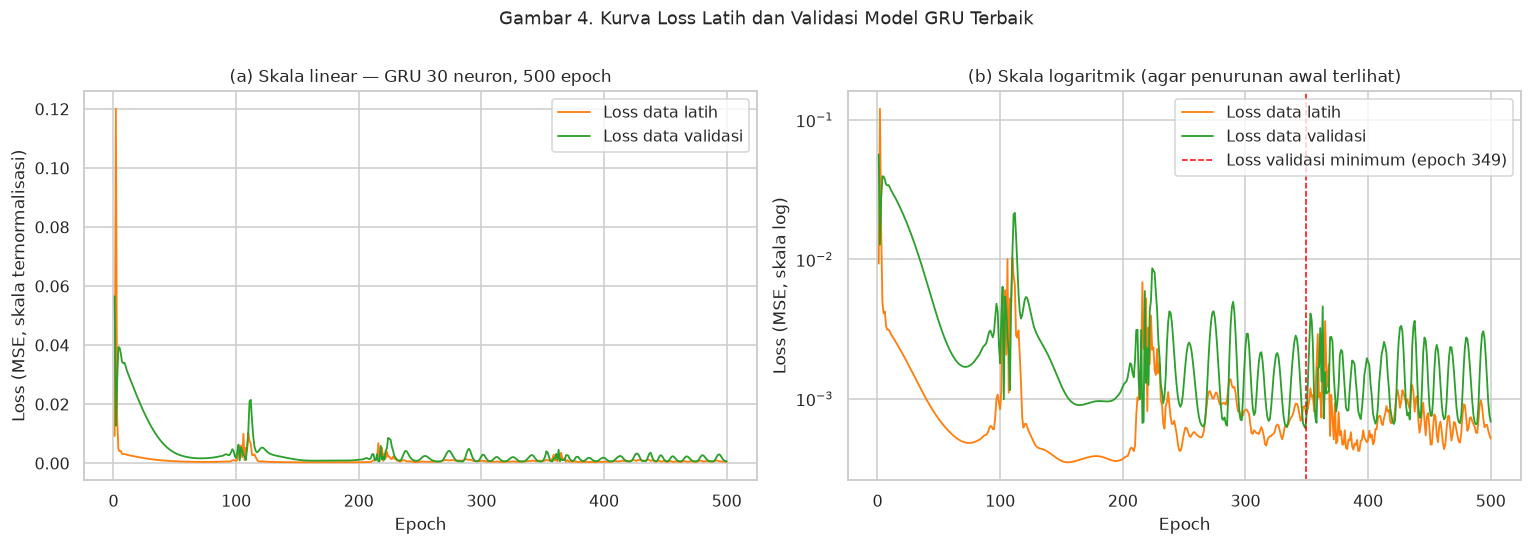


  Loss latih    epoch pertama : 0.00930230
  Loss latih    epoch terakhir: 0.00051683
  Loss validasi epoch pertama : 0.05659199
  Loss validasi epoch terakhir: 0.00068225
  Loss validasi minimum       : 0.00061486 (epoch 349)
  Penurunan loss latih        : 94.44% dari epoch pertama


In [31]:
utils.cetak_sub("8.6 Gambar 4 — Kurva loss latih dan validasi model GRU terbaik")

loss_latih_gru = riwayat_gru.history["loss"]
loss_val_gru = riwayat_gru.history["val_loss"]
epoch_terbaik_val_gru = int(np.argmin(loss_val_gru)) + 1

fig, sumbu = plt.subplots(1, 2, figsize=(14, 4.8))

sumbu[0].plot(range(1, len(loss_latih_gru) + 1), loss_latih_gru,
              label="Loss data latih", linewidth=1.2, color="#ff7f0e")
sumbu[0].plot(range(1, len(loss_val_gru) + 1), loss_val_gru,
              label="Loss data validasi", linewidth=1.2, color="#2ca02c")
sumbu[0].set_title(f"(a) Skala linear — GRU {neuron_gru} neuron, {epoch_gru} epoch")
sumbu[0].set_xlabel("Epoch"); sumbu[0].set_ylabel("Loss (MSE, skala ternormalisasi)")
sumbu[0].legend()

sumbu[1].semilogy(range(1, len(loss_latih_gru) + 1), loss_latih_gru,
                  label="Loss data latih", linewidth=1.2, color="#ff7f0e")
sumbu[1].semilogy(range(1, len(loss_val_gru) + 1), loss_val_gru,
                  label="Loss data validasi", linewidth=1.2, color="#2ca02c")
sumbu[1].axvline(epoch_terbaik_val_gru, color="red", linestyle="--", linewidth=1,
                 label=f"Loss validasi minimum (epoch {epoch_terbaik_val_gru})")
sumbu[1].set_title("(b) Skala logaritmik (agar penurunan awal terlihat)")
sumbu[1].set_xlabel("Epoch"); sumbu[1].set_ylabel("Loss (MSE, skala log)")
sumbu[1].legend()

fig.suptitle("Gambar 4. Kurva Loss Latih dan Validasi Model GRU Terbaik", fontsize=12, y=1.02)
fig.tight_layout()
utils.simpan_gambar(fig, 4, "Kurva loss latih dan validasi model GRU terbaik")
plt.show()

print(f"\n  Loss latih    epoch pertama : {loss_latih_gru[0]:.8f}")
print(f"  Loss latih    epoch terakhir: {loss_latih_gru[-1]:.8f}")
print(f"  Loss validasi epoch pertama : {loss_val_gru[0]:.8f}")
print(f"  Loss validasi epoch terakhir: {loss_val_gru[-1]:.8f}")
print(f"  Loss validasi minimum       : {min(loss_val_gru):.8f} (epoch {epoch_terbaik_val_gru})")
print(f"  Penurunan loss latih        : "
      f"{(1 - loss_latih_gru[-1] / loss_latih_gru[0]) * 100:.2f}% dari epoch pertama")

### 8.F Verifikasi manual *forward pass* GRU

Sama seperti Tahap 7.E, bagian ini menghitung ulang $\hat{y}$ dari nol dengan
NumPy memakai bobot hasil pelatihan, lalu membandingkannya dengan
`model.predict()`.

**Perhitungan WAJIB mengikuti rumus Keras** (`reset_after=True`):

$$\mathbf{z}_t = \sigma\!\left(\mathbf{x}_t\mathbf{W}_z + \mathbf{h}_{t-1}\mathbf{U}_z + \mathbf{b}_z^{(in)} + \mathbf{b}_z^{(rec)}\right)$$
$$\mathbf{r}_t = \sigma\!\left(\mathbf{x}_t\mathbf{W}_r + \mathbf{h}_{t-1}\mathbf{U}_r + \mathbf{b}_r^{(in)} + \mathbf{b}_r^{(rec)}\right)$$
$$\tilde{\mathbf{h}}_t = \tanh\!\left(\mathbf{x}_t\mathbf{W}_h + \mathbf{b}_h^{(in)} + \mathbf{r}_t \odot \left(\mathbf{h}_{t-1}\mathbf{U}_h + \mathbf{b}_h^{(rec)}\right)\right)$$
$$\mathbf{h}_t = \mathbf{z}_t \odot \mathbf{h}_{t-1} + \left(1-\mathbf{z}_t\right) \odot \tilde{\mathbf{h}}_t$$

Keadaan awal $\mathbf{h}_0 = \mathbf{0}$ (GRU tidak memiliki $\mathbf{c}_t$).
Pada akhir bagian ini juga ditunjukkan secara numerik bahwa memakai rumus buku
teks Cho dkk. (2014) **akan menghasilkan angka yang berbeda**, sebagai bukti
mengapa konvensi Keras harus dipakai.

In [32]:
utils.cetak_sub("8.7 PERHITUNGAN MANUAL — forward pass GRU (jendela pertama data uji)")

baris_manual = []


def tulis(teks: str = "") -> None:
    print(teks)
    baris_manual.append(teks)


ug = neuron_gru

# --- Pemecahan bobot sesuai urutan Keras: z, r, h -------------------------- #
W_z, W_r, W_h = np.split(W_gru, 3, axis=1)
U_z, U_r, U_h = np.split(U_gru, 3, axis=1)
b_masukan, b_rekuren = b_gru[0], b_gru[1]
bz_in, br_in, bh_in = np.split(b_masukan, 3)
bz_rec, br_rec, bh_rec = np.split(b_rekuren, 3)

tulis("(a) PEMECAHAN BOBOT KERAS SESUAI URUTAN z, r, h")
tulis()
tulis(f"Matriks gabungan kernel W      : {W_gru.shape}")
tulis(f"Matriks gabungan recurrent U   : {U_gru.shape}")
tulis(f"Matriks gabungan bias b        : {b_gru.shape}  (2 baris: in dan rec)")
tulis(f"Jumlah unit (neuron) n_unit    : {ug}")
tulis()
tulis(f"  {'Gerbang':<24}{'W (fitur x unit)':>20}{'U (unit x unit)':>20}"
      f"{'b_in':>10}{'b_rec':>10}")
for nama_gerbang, Wg, Ug, bg_in, bg_rec in [
    ("z (update gate)", W_z, U_z, bz_in, bz_rec),
    ("r (reset gate)", W_r, U_r, br_in, br_rec),
    ("h (kandidat hidden)", W_h, U_h, bh_in, bh_rec),
]:
    tulis(f"  {nama_gerbang:<24}{str(Wg.shape):>20}{str(Ug.shape):>20}"
          f"{str(bg_in.shape):>10}{str(bg_rec.shape):>10}")
tulis()
tulis("Contoh nilai bobot untuk NEURON KE-1 (kolom pertama tiap matriks):")
tulis()
for nama_gerbang, Wg, Ug, bg_in, bg_rec in [
    ("z (update)", W_z, U_z, bz_in, bz_rec),
    ("r (reset)", W_r, U_r, br_in, br_rec),
    ("h (kandidat)", W_h, U_h, bh_in, bh_rec),
]:
    tulis(f"  Gerbang {nama_gerbang}")
    tulis(f"    W[:,1] (10 bobot masukan) = {ringkas_vektor(Wg[:, 0], 10)}")
    tulis(f"    U[:,1] (bobot rekuren)    = {ringkas_vektor(Ug[:, 0], 6)}")
    tulis(f"    b_in[1]                   = {float(bg_in[0]):+.6f}")
    tulis(f"    b_rec[1]                  = {float(bg_rec[0]):+.6f}")
tulis()


----------------------------------------------------------------------
8.7 PERHITUNGAN MANUAL — forward pass GRU (jendela pertama data uji)
----------------------------------------------------------------------
(a) PEMECAHAN BOBOT KERAS SESUAI URUTAN z, r, h

Matriks gabungan kernel W      : (10, 90)
Matriks gabungan recurrent U   : (30, 90)
Matriks gabungan bias b        : (2, 90)  (2 baris: in dan rec)
Jumlah unit (neuron) n_unit    : 30

  Gerbang                     W (fitur x unit)     U (unit x unit)      b_in     b_rec
  z (update gate)                     (10, 30)            (30, 30)     (30,)     (30,)
  r (reset gate)                      (10, 30)            (30, 30)     (30,)     (30,)
  h (kandidat hidden)                 (10, 30)            (30, 30)     (30,)     (30,)

Contoh nilai bobot untuk NEURON KE-1 (kolom pertama tiap matriks):

  Gerbang z (update)
    W[:,1] (10 bobot masukan) = [-0.004894, 0.005574, -0.035411, -0.024312, 0.053985, -0.125109, -0.004999, -0.38710

In [33]:
# --- Forward pass manual GRU seluruh timestep ------------------------------ #
tulis("(b) FORWARD PASS MANUAL DENGAN NUMPY — JENDELA PERTAMA DATA UJI")
tulis()
tulis(f"Masukan  : X_uji[0] berbentuk {jendela_uji.shape} "
      f"({tanggal_jendela_uji[0]} s.d. {tanggal_jendela_uji[-1]})")
tulis(f"Target    : Close Price {tanggal_target_uji} = "
      f"{utils.fmt_usd(aktual_uji_usd[0])} USD")
tulis(f"Keadaan awal: h_0 = vektor nol ({ug} elemen); GRU tidak memiliki cell state")
tulis()

h_t_gru = np.zeros(ug, dtype=np.float64)
jejak_gru = []

for t in range(LOOKBACK):
    x_t = jendela_uji[t]
    h_sebelum = h_t_gru.copy()

    # Pra-aktivasi gerbang z dan r (kedua himpunan bias dijumlahkan)
    z_pra = x_t @ W_z + h_sebelum @ U_z + bz_in + bz_rec
    r_pra = x_t @ W_r + h_sebelum @ U_r + br_in + br_rec
    z_t = sigmoid(z_pra)
    r_t = sigmoid(r_pra)

    # Kandidat hidden state: gerbang reset dikenakan SETELAH perkalian matriks
    jalur_rekuren = h_sebelum @ U_h + bh_rec
    h_pra = x_t @ W_h + bh_in + r_t * jalur_rekuren
    h_kandidat = np.tanh(h_pra)

    # Konvensi Keras: z menimbang MEMORI LAMA
    h_t_gru = z_t * h_sebelum + (1.0 - z_t) * h_kandidat

    jejak_gru.append({
        "t": t + 1, "tanggal": tanggal_jendela_uji[t], "x_t": x_t,
        "h_sebelum": h_sebelum, "z_pra": z_pra, "r_pra": r_pra, "h_pra": h_pra,
        "z": z_t, "r": r_t, "jalur_rekuren": jalur_rekuren,
        "h_kandidat": h_kandidat, "h": h_t_gru.copy(),
    })

    # --- Cetak rincian lengkap untuk timestep 1 dan 2 --------------------- #
    if t < 2:
        tulis("=" * 66)
        tulis(f"RINCIAN TIMESTEP t = {t + 1}  (tanggal {tanggal_jendela_uji[t]})")
        tulis("=" * 66)
        tulis(f"  {f'x_{t + 1} (10 fitur ternormalisasi)':<34}= {ringkas_vektor(x_t, 10)}")
        tulis(f"  {f'h_{t} (hidden state sebelumnya)':<34}= {ringkas_vektor(h_sebelum, 6)}")
        tulis()
        tulis("  --- RINCIAN NEURON KE-1 ---")
        for lambang, nama_panjang, Wg, Ug, bg_in, bg_rec, z_vec, akt_vec in [
            ("z", "update gate", W_z, U_z, bz_in, bz_rec, z_pra, z_t),
            ("r", "reset gate", W_r, U_r, br_in, br_rec, r_pra, r_t),
        ]:
            sumbangan_x = float(x_t @ Wg[:, 0])
            sumbangan_h = float(h_sebelum @ Ug[:, 0])
            tulis(f"  Gerbang {lambang} ({nama_panjang}):")
            tulis(f"    pra-aktivasi = x_t.W[:,1] + h_(t-1).U[:,1] + b_in[1] + b_rec[1]")
            tulis(f"                 = {sumbangan_x:+.6f} {sumbangan_h:+.6f} "
                  f"{float(bg_in[0]):+.6f} {float(bg_rec[0]):+.6f}")
            tulis(f"                 = {float(z_vec[0]):+.6f}")
            tulis(f"    setelah sigmoid = {float(akt_vec[0]):.6f}")
        tulis()
        tulis("  Kandidat hidden state (reset_after=True):")
        tulis(f"    jalur rekuren = h_(t-1).U_h[:,1] + b_h_rec[1]")
        tulis(f"                  = {float(h_sebelum @ U_h[:, 0]):+.6f} "
              f"{float(bh_rec[0]):+.6f} = {float(jalur_rekuren[0]):+.6f}")
        tulis(f"    pra-aktivasi  = x_t.W_h[:,1] + b_h_in[1] + r[1] * jalur_rekuren")
        tulis(f"                  = {float(x_t @ W_h[:, 0]):+.6f} "
              f"{float(bh_in[0]):+.6f} + {float(r_t[0]):.6f} * {float(jalur_rekuren[0]):+.6f}")
        tulis(f"                  = {float(h_pra[0]):+.6f}")
        tulis(f"    h~[1] = tanh({float(h_pra[0]):+.6f}) = {float(h_kandidat[0]):+.6f}")
        tulis()
        sela = " " * 11
        tulis(f"  h_{t + 1}[1] = z[1] * h_{t}[1] + (1 - z[1]) * h~[1]")
        tulis(f"{sela}= {float(z_t[0]):.6f} * {float(h_sebelum[0]):+.6f} "
              f"+ {float(1 - z_t[0]):.6f} * {float(h_kandidat[0]):+.6f}")
        tulis(f"{sela}= {float(z_t[0] * h_sebelum[0]):+.6f} "
              f"+ {float((1 - z_t[0]) * h_kandidat[0]):+.6f}")
        tulis(f"{sela}= {float(h_t_gru[0]):+.6f}")
        tulis()
        tulis("  --- VEKTOR LENGKAP TIMESTEP INI ---")
        tulis(f"    z_{t + 1}  = {ringkas_vektor(z_t)}")
        tulis(f"    r_{t + 1}  = {ringkas_vektor(r_t)}")
        tulis(f"    h~_{t + 1} = {ringkas_vektor(h_kandidat)}")
        tulis(f"    h_{t + 1}  = {ringkas_vektor(h_t_gru)}")
        tulis()

tulis("(c) RINGKASAN SELURUH TIMESTEP (neuron ke-1)")
tulis()
tabel_jejak_gru = pd.DataFrame([{
    "t": j["t"], "Tanggal": j["tanggal"],
    "z[1]": j["z"][0], "r[1]": j["r"][0],
    "h~[1]": j["h_kandidat"][0], "h[1]": j["h"][0],
} for j in jejak_gru])
with pd.option_context("display.float_format", lambda v: f"{v:,.6f}"):
    tulis(tabel_jejak_gru.to_string(index=False))
tulis()

(b) FORWARD PASS MANUAL DENGAN NUMPY — JENDELA PERTAMA DATA UJI

Masukan  : X_uji[0] berbentuk (7, 10) (2025-12-11 s.d. 2025-12-17)
Target    : Close Price 2025-12-18 = 86,132.82 USD
Keadaan awal: h_0 = vektor nol (30 elemen); GRU tidak memiliki cell state

RINCIAN TIMESTEP t = 1  (tanggal 2025-12-11)
  x_1 (10 fitur ternormalisasi)     = [0.680495, 0.297207, 1.112427, 1.035626, 0.507183, 0.393311, 0.235063, 0.373105, 0.336586, 0.053572]  (panjang 10)
  h_0 (hidden state sebelumnya)     = [0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, ...]  (panjang 30)

  --- RINCIAN NEURON KE-1 ---
  Gerbang z (update gate):
    pra-aktivasi = x_t.W[:,1] + h_(t-1).U[:,1] + b_in[1] + b_rec[1]
                 = -0.234813 +0.000000 +0.211800 +0.211800
                 = +0.188787
    setelah sigmoid = 0.547057
  Gerbang r (reset gate):
    pra-aktivasi = x_t.W[:,1] + h_(t-1).U[:,1] + b_in[1] + b_rec[1]
                 = -1.416727 +0.000000 -0.249689 -0.249689
                 = -1.916105

In [34]:
# --- Lapisan Dense dan pembandingan dengan Keras --------------------------- #
tulis("(d) LAPISAN DENSE — y_hat = h_T . W_y + b_y")
tulis()
h_akhir_gru = jejak_gru[-1]["h"]
tulis(f"  h_T (hidden state timestep terakhir, T = {LOOKBACK}) = {ringkas_vektor(h_akhir_gru)}")
tulis(f"  W_y (bobot Dense) = {ringkas_vektor(Wy_gru.ravel())}")
tulis(f"  b_y (bias Dense)  = {float(by_gru[0]):+.6f}")
tulis()
suku_dense_gru = h_akhir_gru * Wy_gru.ravel()
tulis("  Perkalian suku demi suku (enam suku pertama):")
for k in range(min(6, ug)):
    tulis(f"    h_T[{k + 1}] * W_y[{k + 1}] = {h_akhir_gru[k]:+.6f} * "
          f"{float(Wy_gru[k, 0]):+.6f} = {suku_dense_gru[k]:+.6f}")
if ug > 6:
    tulis(f"    ... ({ug - 6} suku lainnya)")
tulis(f"  Jumlah seluruh suku = {float(suku_dense_gru.sum()):+.6f}")
y_hat_manual_gru = float(suku_dense_gru.sum() + by_gru[0])
tulis(f"  y_hat = {float(suku_dense_gru.sum()):+.6f} + {float(by_gru[0]):+.6f} "
      f"= {y_hat_manual_gru:.8f}   (skala ternormalisasi)")
tulis()

tulis("(e) PEMBANDINGAN DENGAN model.predict() DARI KERAS")
tulis()
y_hat_keras_gru = float(model_gru.predict(X_uji[:1], verbose=0)[0, 0])
selisih_gru = abs(y_hat_manual_gru - y_hat_keras_gru)
tulis(f"  Hasil manual NumPy   : {y_hat_manual_gru:.10f}")
tulis(f"  Hasil model.predict(): {y_hat_keras_gru:.10f}")
tulis(f"  Selisih absolut      : {selisih_gru:.3e}")
tulis()
y_hat_manual_gru_usd = float(ke_usd([y_hat_manual_gru])[0])
tulis(f"  Dalam skala USD:")
tulis(f"    Prediksi manual      : {utils.fmt_usd(y_hat_manual_gru_usd)} USD")
tulis(f"    Prediksi Keras       : {utils.fmt_usd(float(ke_usd([y_hat_keras_gru])[0]))} USD")
tulis(f"    Harga aktual {tanggal_target_uji} : {utils.fmt_usd(aktual_uji_usd[0])} USD")
tulis()
np.testing.assert_allclose(y_hat_manual_gru, y_hat_keras_gru, atol=1e-5)
assert selisih_gru < 1e-5, "Forward pass manual GRU tidak cocok dengan Keras"
tulis("  OK Hasil manual SAMA dengan hasil model (toleransi 1e-5)")
tulis()

# --- Bukti numerik: rumus buku teks memberi hasil berbeda ------------------ #
tulis("(f) BUKTI NUMERIK — RUMUS BUKU TEKS (CHO DKK., 2014) MEMBERI HASIL BERBEDA")
tulis()
tulis("Rumus Cho dkk. (2014):")
tulis("  h~_t = tanh( x_t.W_h + (r_t * h_(t-1)).U_h )      <- reset SEBELUM perkalian")
tulis("  h_t  = (1 - z_t) * h_(t-1) + z_t * h~_t            <- peran z tertukar")
tulis()
h_cho = np.zeros(ug, dtype=np.float64)
for t in range(LOOKBACK):
    x_t = jendela_uji[t]
    h_sebelum = h_cho.copy()
    z_c = sigmoid(x_t @ W_z + h_sebelum @ U_z + bz_in + bz_rec)
    r_c = sigmoid(x_t @ W_r + h_sebelum @ U_r + br_in + br_rec)
    h_kandidat_cho = np.tanh(x_t @ W_h + bh_in + (r_c * h_sebelum) @ U_h + bh_rec)
    h_cho = (1.0 - z_c) * h_sebelum + z_c * h_kandidat_cho
y_hat_cho = float(h_cho @ Wy_gru.ravel() + by_gru[0])

tulis(f"  y_hat dengan rumus Keras (reset_after=True) : {y_hat_manual_gru:.10f}")
tulis(f"  y_hat dengan rumus buku teks Cho dkk.       : {y_hat_cho:.10f}")
tulis(f"  Selisih                                     : "
      f"{abs(y_hat_manual_gru - y_hat_cho):.6e}")
tulis(f"  Dalam USD: Keras = {utils.fmt_usd(y_hat_manual_gru_usd)} USD, "
      f"Cho dkk. = {utils.fmt_usd(float(ke_usd([y_hat_cho])[0]))} USD")
tulis()
tulis("Kesimpulan: kedua rumus sama-sama sah sebagai GRU, tetapi menghasilkan")
tulis("angka yang berbeda untuk himpunan bobot yang sama. Karena bobot di sini")
tulis("dilatih oleh Keras, perhitungan manual WAJIB memakai konvensi Keras.")

print("\n✔ Hasil manual SAMA dengan hasil model")

utils.tulis_manual("8_forward_pass_gru", "Forward Pass GRU (Jendela Pertama Data Uji)", f"""
## Rumus yang diverifikasi (konvensi Keras, `reset_after=True`)

$$\\mathbf{{z}}_t = \\sigma\\!\\left(\\mathbf{{x}}_t\\mathbf{{W}}_z + \\mathbf{{h}}_{{t-1}}\\mathbf{{U}}_z
+ \\mathbf{{b}}_z^{{(in)}} + \\mathbf{{b}}_z^{{(rec)}}\\right)$$

$$\\mathbf{{r}}_t = \\sigma\\!\\left(\\mathbf{{x}}_t\\mathbf{{W}}_r + \\mathbf{{h}}_{{t-1}}\\mathbf{{U}}_r
+ \\mathbf{{b}}_r^{{(in)}} + \\mathbf{{b}}_r^{{(rec)}}\\right)$$

$$\\tilde{{\\mathbf{{h}}}}_t = \\tanh\\!\\left(\\mathbf{{x}}_t\\mathbf{{W}}_h + \\mathbf{{b}}_h^{{(in)}}
+ \\mathbf{{r}}_t \\odot \\left(\\mathbf{{h}}_{{t-1}}\\mathbf{{U}}_h + \\mathbf{{b}}_h^{{(rec)}}\\right)\\right)$$

$$\\mathbf{{h}}_t = \\mathbf{{z}}_t \\odot \\mathbf{{h}}_{{t-1}}
+ \\left(1-\\mathbf{{z}}_t\\right) \\odot \\tilde{{\\mathbf{{h}}}}_t
\\qquad
\\hat{{y}} = \\mathbf{{h}}_T\\mathbf{{W}}_y + b_y$$

Urutan penyimpanan bobot pada Keras: **z, r, h**. Keadaan awal
$\\mathbf{{h}}_0 = \\mathbf{{0}}$ (GRU tidak memiliki *cell state*).

## Perhitungan

{utils.blok_kode(chr(10).join(baris_manual))}

## Kesimpulan

Prediksi hasil hitung tangan dengan NumPy sebesar `{y_hat_manual_gru:.10f}`
(ternormalisasi) atau **{utils.fmt_usd(y_hat_manual_gru_usd)} USD**, sedangkan
`model.predict()` menghasilkan `{y_hat_keras_gru:.10f}` dengan selisih hanya
{selisih_gru:.2e} — jauh di bawah toleransi $10^{{-5}}$.

Sebaliknya, memakai rumus buku teks Cho dkk. (2014) pada himpunan bobot yang
sama menghasilkan `{y_hat_cho:.10f}`, yaitu berbeda
{abs(y_hat_manual_gru - y_hat_cho):.2e}. Hal ini membuktikan pentingnya memakai
konvensi Keras pada perhitungan manual skripsi.
""")

(d) LAPISAN DENSE — y_hat = h_T . W_y + b_y

  h_T (hidden state timestep terakhir, T = 7) = [0.380500, -0.016342, -0.094670, 0.198929, 0.035380, 0.332692, ...]  (panjang 30)
  W_y (bobot Dense) = [0.256136, 0.098238, -0.066118, 0.121973, 0.076804, 0.173387, ...]  (panjang 30)
  b_y (bias Dense)  = +0.042936

  Perkalian suku demi suku (enam suku pertama):
    h_T[1] * W_y[1] = +0.380500 * +0.256136 = +0.097460
    h_T[2] * W_y[2] = -0.016342 * +0.098238 = -0.001605
    h_T[3] * W_y[3] = -0.094670 * -0.066118 = +0.006259
    h_T[4] * W_y[4] = +0.198929 * +0.121973 = +0.024264
    h_T[5] * W_y[5] = +0.035380 * +0.076804 = +0.002717
    h_T[6] * W_y[6] = +0.332692 * +0.173387 = +0.057685
    ... (24 suku lainnya)
  Jumlah seluruh suku = +0.604745
  y_hat = +0.604745 + +0.042936 = 0.64768150   (skala ternormalisasi)

(e) PEMBANDINGAN DENGAN model.predict() DARI KERAS

  Hasil manual NumPy   : 0.6476814983
  Hasil model.predict(): 0.6476814747
  Selisih absolut      : 2.366e-08

  Dalam sk

'/home/user/prediction-lstm-gru-btc/outputs/perhitungan_manual/tahap_8_forward_pass_gru.md'

In [35]:
utils.cetak_sub("8.8 Prediksi model GRU pada data uji")

prediksi_uji_gru_norm = model_gru.predict(X_uji, verbose=0).ravel()
prediksi_uji_gru_usd = ke_usd(prediksi_uji_gru_norm)
prediksi_val_gru_usd = ke_usd(model_gru.predict(X_val, verbose=0))

utils.cetak_shape("prediksi_uji_gru_norm", prediksi_uji_gru_norm)
print(f"  Jumlah hari uji yang diprediksi : {utils.fmt_int(len(prediksi_uji_gru_usd))}")
print(f"  Rentang prediksi (ternormalisasi): "
      f"[{prediksi_uji_gru_norm.min():.6f}, {prediksi_uji_gru_norm.max():.6f}]")
print(f"  Rentang prediksi (USD)           : "
      f"[{utils.fmt_usd(prediksi_uji_gru_usd.min())}, {utils.fmt_usd(prediksi_uji_gru_usd.max())}]")

print("\n  Lima prediksi pertama:")
print(f"    {'Tanggal':<12}{'Aktual (USD)':>16}{'Prediksi GRU (USD)':>22}{'Galat (USD)':>16}")
for k in range(5):
    galat = aktual_uji_usd[k] - prediksi_uji_gru_usd[k]
    print(f"    {str(pd.Timestamp(tanggal_uji[k]).date()):<12}"
          f"{utils.fmt_usd(aktual_uji_usd[k]):>16}"
          f"{utils.fmt_usd(prediksi_uji_gru_usd[k]):>22}{utils.fmt_usd(galat):>16}")

assert np.isclose(prediksi_uji_gru_norm[0], y_hat_manual_gru, atol=1e-5)
print("\n  OK Prediksi hari pertama konsisten dengan forward pass manual.")

utils.ringkasan_tahap(f"""
Lima belas kombinasi hyperparameter GRU dilatih dengan pengaturan yang sama
persis dengan LSTM, dan konfigurasi terbaik menurut RMSE DATA VALIDASI adalah
{neuron_gru} neuron dengan {epoch_gru} epoch (RMSE validasi
{utils.fmt_usd(tabel_tuning_gru.loc[posisi_terbaik_gru, 'RMSE Validasi (USD)'])} USD,
MAPE validasi {tabel_tuning_gru.loc[posisi_terbaik_gru, 'MAPE Validasi (%)']:.4f}%).
Model ini memakai {utils.fmt_int(model_gru.count_params())} parameter dan
selesai dilatih dalam {waktu_gru:,.2f} detik.

Jumlah parameter hasil hitung tangan dengan rumus
3 x (n_unit x (n_unit + n_fitur) + 2 x n_unit) cocok dengan keluaran Keras,
termasuk suku 2 x n_unit yang berasal dari reset_after=True. Forward pass
manual juga menghasilkan angka identik dengan model.predict() (selisih
{selisih_gru:.1e}).

Sebagai tambahan, telah dibuktikan secara numerik bahwa rumus GRU buku teks
Cho dkk. (2014) memberi hasil berbeda pada bobot yang sama, sehingga
perhitungan manual di Bab III harus memakai konvensi Keras.
""")


----------------------------------------------------------------------
8.8 Prediksi model GRU pada data uji
----------------------------------------------------------------------


  shape prediksi_uji_gru_norm        = (226,)
  Jumlah hari uji yang diprediksi : 226
  Rentang prediksi (ternormalisasi): [0.342052, 0.732831]
  Rentang prediksi (USD)           : [58,751.06, 97,124.33]

  Lima prediksi pertama:
    Tanggal         Aktual (USD)    Prediksi GRU (USD)     Galat (USD)
    2025-12-18         86,132.82             88,762.92       -2,630.10
    2025-12-19         85,458.35             87,246.46       -1,788.11
    2025-12-20         88,098.82             87,038.05        1,060.77
    2025-12-21         88,337.41             88,649.40         -311.99
    2025-12-22         88,615.72             88,845.88         -230.16

  OK Prediksi hari pertama konsisten dengan forward pass manual.

RINGKASAN TAHAP
Lima belas kombinasi hyperparameter GRU dilatih dengan pengaturan yang
sama persis dengan LSTM, dan konfigurasi terbaik menurut RMSE DATA
VALIDASI adalah 30 neuron dengan 500 epoch (RMSE validasi 2,564.89
USD, MAPE validasi 1.9797%). Model ini memakai 3,811 par

---
## TAHAP 9 — Perbandingan Arsitektur dan Uji Kestabilan

**Tujuan.** Menjawab bagian kedua pertanyaan penelitian: bagaimana perbandingan
**efisiensi** kedua model, dan apakah keunggulan yang terlihat **bukan kebetulan**.

### 9.A Perbandingan arsitektur

| Aspek | LSTM | GRU |
|---|---|---|
| Jumlah gerbang | 3 (*forget*, *input*, *output*) | 2 (*update*, *reset*) |
| Memori | $\mathbf{h}_t$ dan $\mathbf{c}_t$ | hanya $\mathbf{h}_t$ |
| Himpunan bobot | 4 ($i, f, c, o$) | 3 ($z, r, h$) |
| Rumus jumlah parameter | $4\left(n_u(n_u+n_f)+n_u\right)$ | $3\left(n_u(n_u+n_f)+2n_u\right)$ |

### 9.B Uji kestabilan (*stability test*)

**Masalah.** Bobot awal jaringan diundi secara acak. Bisa jadi satu model tampak
lebih unggul hanya karena **kebetulan mendapat undian bobot awal yang
menguntungkan** pada *seed* 42.

**Solusi.** Konfigurasi terbaik masing-masing model dilatih ulang dengan lima
*seed* berbeda: `SEED_ULANGAN = [42, 7, 21, 100, 2024]`. Kemudian dihitung
rata-rata dan standar deviasi metrik data uji:

$$\bar{M} = \frac{1}{5}\sum_{k=1}^{5} M_k
\qquad
s_M = \sqrt{\frac{1}{4}\sum_{k=1}^{5}\left(M_k - \bar{M}\right)^2}$$

**Cara membaca hasilnya.** Jika satu model unggul pada **hampir semua** *seed*
dan standar deviasinya kecil, keunggulan tersebut bersifat sistematis (berasal
dari arsitektur). Jika urutan unggul berganti-ganti antar *seed* atau standar
deviasinya besar (saling tumpang tindih), maka perbedaan kedua model **tidak
dapat disimpulkan** sebagai keunggulan arsitektur.

> Model dengan `SEED` utama (42) tetap dipakai untuk seluruh perhitungan manual,
> grafik, dan evaluasi akhir pada Tahap 10–13.

In [36]:
utils.cetak_header(9, "Perbandingan arsitektur dan kestabilan")

utils.cetak_sub("9.1 Tabel 13 — Perbandingan arsitektur LSTM dan GRU terbaik")

baris_lstm = tabel_tuning_lstm.loc[posisi_terbaik_lstm]
baris_gru = tabel_tuning_gru.loc[posisi_terbaik_gru]

tabel_arsitektur = pd.DataFrame([
    {
        "Aspek": "Konfigurasi terbaik (neuron x epoch)",
        "LSTM": f"{neuron_lstm} x {epoch_lstm}",
        "GRU": f"{neuron_gru} x {epoch_gru}",
    },
    {"Aspek": "Jumlah gerbang", "LSTM": "3 (forget, input, output)", "GRU": "2 (update, reset)"},
    {"Aspek": "Jumlah himpunan bobot", "LSTM": "4 (i, f, c, o)", "GRU": "3 (z, r, h)"},
    {"Aspek": "Memori internal", "LSTM": "h_t dan c_t", "GRU": "hanya h_t"},
    {
        "Aspek": "Jumlah parameter lapisan rekuren",
        "LSTM": utils.fmt_int(model_lstm.get_layer("lapisan_rekuren").count_params()),
        "GRU": utils.fmt_int(model_gru.get_layer("lapisan_rekuren").count_params()),
    },
    {
        "Aspek": "Jumlah parameter total",
        "LSTM": utils.fmt_int(model_lstm.count_params()),
        "GRU": utils.fmt_int(model_gru.count_params()),
    },
    {
        "Aspek": "Waktu latih total (detik)",
        "LSTM": f"{waktu_lstm:,.2f}", "GRU": f"{waktu_gru:,.2f}",
    },
    {
        "Aspek": "Waktu latih per epoch (detik)",
        "LSTM": f"{waktu_lstm / epoch_lstm:,.4f}", "GRU": f"{waktu_gru / epoch_gru:,.4f}",
    },
    {
        "Aspek": "RMSE data validasi (USD)",
        "LSTM": utils.fmt_usd(baris_lstm["RMSE Validasi (USD)"]),
        "GRU": utils.fmt_usd(baris_gru["RMSE Validasi (USD)"]),
    },
    {
        "Aspek": "MAPE data validasi (%)",
        "LSTM": f"{baris_lstm['MAPE Validasi (%)']:.4f}",
        "GRU": f"{baris_gru['MAPE Validasi (%)']:.4f}",
    },
])
print(tabel_arsitektur.to_string(index=False))
utils.simpan_tabel(tabel_arsitektur, 13, "Perbandingan arsitektur LSTM dan GRU terbaik")

# --- Perbandingan efisiensi pada jumlah neuron yang sama ------------------- #
print("\n  Perbandingan jumlah parameter pada JUMLAH NEURON YANG SAMA")
print(f"  (agar pengaruh arsitektur terlihat murni, n_fitur = {JUMLAH_FITUR}):\n")
print(f"    {'Neuron':>7}{'Param LSTM':>14}{'Param GRU':>13}{'Selisih':>12}{'GRU/LSTM':>11}")
for unit_bandingan in CONFIG["NEURON_GRID"]:
    p_lstm = 4 * (unit_bandingan * (unit_bandingan + JUMLAH_FITUR) + unit_bandingan) + unit_bandingan + 1
    p_gru = 3 * (unit_bandingan * (unit_bandingan + JUMLAH_FITUR) + 2 * unit_bandingan) + unit_bandingan + 1
    print(f"    {unit_bandingan:>7}{utils.fmt_int(p_lstm):>14}{utils.fmt_int(p_gru):>13}"
          f"{utils.fmt_int(p_lstm - p_gru):>12}{p_gru / p_lstm:>11.4f}")
print("\n  Terlihat GRU selalu memakai parameter lebih sedikit daripada LSTM pada")
print("  jumlah neuron yang sama, yaitu sekitar tiga perempat jumlah parameter LSTM.")

TAHAP 9 - PERBANDINGAN ARSITEKTUR DAN KESTABILAN

----------------------------------------------------------------------
9.1 Tabel 13 — Perbandingan arsitektur LSTM dan GRU terbaik
----------------------------------------------------------------------
                               Aspek                      LSTM               GRU
Konfigurasi terbaik (neuron x epoch)                  40 x 500          30 x 500
                      Jumlah gerbang 3 (forget, input, output) 2 (update, reset)
               Jumlah himpunan bobot            4 (i, f, c, o)       3 (z, r, h)
                     Memori internal               h_t dan c_t         hanya h_t
    Jumlah parameter lapisan rekuren                     8,160             3,780
              Jumlah parameter total                     8,201             3,811
           Waktu latih total (detik)                     79.56             83.05
       Waktu latih per epoch (detik)                    0.1591            0.1661
            RMSE da

  [tersimpan] Tabel 13. Perbandingan arsitektur LSTM dan GRU terbaik
              -> outputs/tabel/tabel_13_perbandingan_arsitektur_lstm_dan_gru_terbaik.csv / .xlsx

  Perbandingan jumlah parameter pada JUMLAH NEURON YANG SAMA
  (agar pengaruh arsitektur terlihat murni, n_fitur = 10):

     Neuron    Param LSTM    Param GRU     Selisih   GRU/LSTM
         10           851          671         180     0.7885
         20         2,501        1,941         560     0.7761
         30         4,951        3,811       1,140     0.7697
         40         8,201        6,281       1,920     0.7659
         50        12,251        9,351       2,900     0.7633

  Terlihat GRU selalu memakai parameter lebih sedikit daripada LSTM pada
  jumlah neuron yang sama, yaitu sekitar tiga perempat jumlah parameter LSTM.


In [37]:
utils.cetak_sub("9.2 Uji kestabilan — melatih ulang konfigurasi terbaik dengan 5 seed")

harga_sebelumnya_uji = df_bersih[KOLOM_TARGET].to_numpy()[idx_uji - 1]

print(f"  Konfigurasi yang dilatih ulang:")
print(f"    LSTM : {neuron_lstm} neuron, {epoch_lstm} epoch")
print(f"    GRU  : {neuron_gru} neuron, {epoch_gru} epoch")
print(f"  Seed ulangan: {CONFIG['SEED_ULANGAN']}")
print(f"  Total pelatihan: 2 model x {len(CONFIG['SEED_ULANGAN'])} seed = "
      f"{2 * len(CONFIG['SEED_ULANGAN'])} pelatihan\n")

hasil_kestabilan = []
prediksi_seed = {"LSTM": {}, "GRU": {}}
waktu_mulai_kestabilan = time.perf_counter()

print(f"  {'Arsitektur':<12}{'Seed':>7}{'RMSE Uji (USD)':>17}{'MAE Uji (USD)':>16}"
      f"{'MAPE Uji (%)':>14}{'Akurasi Arah (%)':>18}{'Waktu (detik)':>15}")
print("  " + "-" * 99)

for tipe, jumlah_neuron, jumlah_epoch in [("LSTM", neuron_lstm, epoch_lstm),
                                          ("GRU", neuron_gru, epoch_gru)]:
    for seed in CONFIG["SEED_ULANGAN"]:
        model_ulang = bangun_model(tipe, jumlah_neuron, seed)
        _, durasi_ulang = latih_model(model_ulang, jumlah_epoch)
        prediksi_ulang = ke_usd(model_ulang.predict(X_uji, verbose=0))
        prediksi_seed[tipe][seed] = prediksi_ulang

        ukuran = metrik.semua_metrik(aktual_uji_usd, prediksi_ulang, harga_sebelumnya_uji)
        hasil_kestabilan.append({
            "Arsitektur": tipe, "Seed": seed,
            "Neuron": jumlah_neuron, "Epoch": jumlah_epoch,
            "RMSE Uji (USD)": ukuran["RMSE (USD)"],
            "MAE Uji (USD)": ukuran["MAE (USD)"],
            "MAPE Uji (%)": ukuran["MAPE (%)"],
            "Akurasi Arah (%)": ukuran["Akurasi Arah (%)"],
            "Waktu Latih (detik)": durasi_ulang,
        })
        print(f"  {tipe:<12}{seed:>7}{ukuran['RMSE (USD)']:>17,.2f}"
              f"{ukuran['MAE (USD)']:>16,.2f}{ukuran['MAPE (%)']:>14,.4f}"
              f"{ukuran['Akurasi Arah (%)']:>18,.2f}{durasi_ulang:>15,.2f}")

print("  " + "-" * 99)
print(f"  Total waktu uji kestabilan: "
      f"{(time.perf_counter() - waktu_mulai_kestabilan) / 60:,.2f} menit")

tabel_kestabilan = pd.DataFrame(hasil_kestabilan)


----------------------------------------------------------------------
9.2 Uji kestabilan — melatih ulang konfigurasi terbaik dengan 5 seed
----------------------------------------------------------------------
  Konfigurasi yang dilatih ulang:
    LSTM : 40 neuron, 500 epoch
    GRU  : 30 neuron, 500 epoch
  Seed ulangan: [42, 7, 21, 100, 2024]
  Total pelatihan: 2 model x 5 seed = 10 pelatihan

  Arsitektur     Seed   RMSE Uji (USD)   MAE Uji (USD)  MAPE Uji (%)  Akurasi Arah (%)  Waktu (detik)
  ---------------------------------------------------------------------------------------------------


  LSTM             42         2,045.51        1,525.74        2.1061             49.12          78.91


  LSTM              7         5,943.13        5,632.59        7.8321             48.23          77.30


  LSTM             21         3,863.43        3,422.23        4.7500             48.23          77.05


  LSTM            100         3,550.75        3,082.93        4.2672             48.23          77.86


...

  GRU              42         2,009.65        1,468.24        2.0476             51.33          83.59


  GRU               7         2,032.63        1,527.43        2.1210             44.69          82.48


  GRU              21         2,597.92        2,005.72        2.7384             47.35          81.94


  GRU             100         5,709.49        5,418.62        7.5800             48.23          82.03


  GRU            2024         4,269.23        3,841.30        5.4450             48.23          81.21
  ---------------------------------------------------------------------------------------------------
  Total waktu uji kestabilan: 13.36 menit


In [38]:
utils.cetak_sub("9.3 Tabel 14 — Rekapitulasi uji kestabilan (rata-rata +/- standar deviasi)")

rekap_kestabilan = tabel_kestabilan.groupby("Arsitektur").agg(
    **{
        "Jumlah Seed": ("Seed", "count"),
        "RMSE Rata-rata (USD)": ("RMSE Uji (USD)", "mean"),
        "RMSE Std (USD)": ("RMSE Uji (USD)", "std"),
        "RMSE Min (USD)": ("RMSE Uji (USD)", "min"),
        "RMSE Max (USD)": ("RMSE Uji (USD)", "max"),
        "MAPE Rata-rata (%)": ("MAPE Uji (%)", "mean"),
        "MAPE Std (%)": ("MAPE Uji (%)", "std"),
        "Akurasi Arah Rata-rata (%)": ("Akurasi Arah (%)", "mean"),
        "Waktu Rata-rata (detik)": ("Waktu Latih (detik)", "mean"),
    }
).reset_index()

with pd.option_context("display.float_format", lambda v: f"{v:,.4f}"):
    print(tabel_kestabilan[["Arsitektur", "Seed", "RMSE Uji (USD)", "MAE Uji (USD)",
                            "MAPE Uji (%)", "Akurasi Arah (%)"]].to_string(index=False))
    print()
    print(rekap_kestabilan.to_string(index=False))

print("\n  Penulisan ringkas (rata-rata +/- standar deviasi):")
for _, b in rekap_kestabilan.iterrows():
    print(f"    {b['Arsitektur']:<5} RMSE = {utils.fmt_usd(b['RMSE Rata-rata (USD)'])} "
          f"+/- {utils.fmt_usd(b['RMSE Std (USD)'])} USD   |   "
          f"MAPE = {b['MAPE Rata-rata (%)']:.4f} +/- {b['MAPE Std (%)']:.4f} %")

# Hitung pada berapa seed masing-masing model unggul
menang_lstm = 0
for seed in CONFIG["SEED_ULANGAN"]:
    r_lstm = float(tabel_kestabilan.query("Arsitektur == 'LSTM' and Seed == @seed")["RMSE Uji (USD)"].iloc[0])
    r_gru = float(tabel_kestabilan.query("Arsitektur == 'GRU' and Seed == @seed")["RMSE Uji (USD)"].iloc[0])
    if r_lstm < r_gru:
        menang_lstm += 1
menang_gru = len(CONFIG["SEED_ULANGAN"]) - menang_lstm

print(f"\n  Jumlah seed dengan RMSE uji lebih kecil:")
print(f"    LSTM unggul pada {menang_lstm} dari {len(CONFIG['SEED_ULANGAN'])} seed")
print(f"    GRU  unggul pada {menang_gru} dari {len(CONFIG['SEED_ULANGAN'])} seed")

rmse_rata_lstm = float(rekap_kestabilan.query("Arsitektur == 'LSTM'")["RMSE Rata-rata (USD)"].iloc[0])
rmse_std_lstm = float(rekap_kestabilan.query("Arsitektur == 'LSTM'")["RMSE Std (USD)"].iloc[0])
rmse_rata_gru = float(rekap_kestabilan.query("Arsitektur == 'GRU'")["RMSE Rata-rata (USD)"].iloc[0])
rmse_std_gru = float(rekap_kestabilan.query("Arsitektur == 'GRU'")["RMSE Std (USD)"].iloc[0])

selang_lstm = (rmse_rata_lstm - rmse_std_lstm, rmse_rata_lstm + rmse_std_lstm)
selang_gru = (rmse_rata_gru - rmse_std_gru, rmse_rata_gru + rmse_std_gru)
tumpang_tindih = not (selang_lstm[1] < selang_gru[0] or selang_gru[1] < selang_lstm[0])

print(f"\n  Selang rata-rata +/- 1 standar deviasi:")
print(f"    LSTM : [{utils.fmt_usd(selang_lstm[0])} , {utils.fmt_usd(selang_lstm[1])}] USD")
print(f"    GRU  : [{utils.fmt_usd(selang_gru[0])} , {utils.fmt_usd(selang_gru[1])}] USD")
print(f"    Kedua selang {'SALING TUMPANG TINDIH' if tumpang_tindih else 'TIDAK tumpang tindih'}"
      f" -> perbedaan {'belum tegas' if tumpang_tindih else 'cukup tegas'} secara deskriptif.")

tabel_kestabilan_simpan = pd.concat([
    tabel_kestabilan,
    pd.DataFrame([{
        "Arsitektur": f"{b['Arsitektur']} (rata-rata +/- std)", "Seed": "—",
        "Neuron": "—", "Epoch": "—",
        "RMSE Uji (USD)": b["RMSE Rata-rata (USD)"],
        "MAE Uji (USD)": np.nan,
        "MAPE Uji (%)": b["MAPE Rata-rata (%)"],
        "Akurasi Arah (%)": b["Akurasi Arah Rata-rata (%)"],
        "Waktu Latih (detik)": b["Waktu Rata-rata (detik)"],
    } for _, b in rekap_kestabilan.iterrows()]),
], ignore_index=True)
utils.simpan_tabel(tabel_kestabilan_simpan, 14, "Uji kestabilan model terhadap lima seed")


----------------------------------------------------------------------
9.3 Tabel 14 — Rekapitulasi uji kestabilan (rata-rata +/- standar deviasi)
----------------------------------------------------------------------
Arsitektur  Seed  RMSE Uji (USD)  MAE Uji (USD)  MAPE Uji (%)  Akurasi Arah (%)
      LSTM    42      2,045.5108     1,525.7363        2.1061           49.1150
      LSTM     7      5,943.1340     5,632.5927        7.8321           48.2301
      LSTM    21      3,863.4316     3,422.2309        4.7500           48.2301
      LSTM   100      3,550.7549     3,082.9309        4.2672           48.2301
      LSTM  2024      2,949.8474     2,463.3368        3.4155           48.2301
       GRU    42      2,009.6545     1,468.2366        2.0476           51.3274
       GRU     7      2,032.6347     1,527.4276        2.1210           44.6903
       GRU    21      2,597.9191     2,005.7160        2.7384           47.3451
       GRU   100      5,709.4931     5,418.6198        7.5800 

'/home/user/prediction-lstm-gru-btc/outputs/tabel/tabel_14_uji_kestabilan_model_terhadap_lima_seed'


----------------------------------------------------------------------
9.4 Verifikasi reproduksibilitas — seed 42 harus mengulang hasil Tahap 7 & 8
----------------------------------------------------------------------
  LSTM  selisih maksimum prediksi (Tahap 7/8 vs ulangan seed 42) : 0.000000e+00 USD
  GRU   selisih maksimum prediksi (Tahap 7/8 vs ulangan seed 42) : 0.000000e+00 USD

  OK Pelatihan ulang dengan seed 42 menghasilkan prediksi yang sama:
  penguncian seed dan mode deterministik TensorFlow bekerja sebagaimana mestinya.

----------------------------------------------------------------------
9.5 Gambar 5 — Sebaran RMSE data uji lintas seed
----------------------------------------------------------------------


  [tersimpan] Gambar 5. Uji kestabilan sebaran RMSE data uji lintas seed
              -> outputs/gambar/gambar_05_uji_kestabilan_sebaran_rmse_data_uji_lintas_seed.png (300 dpi)


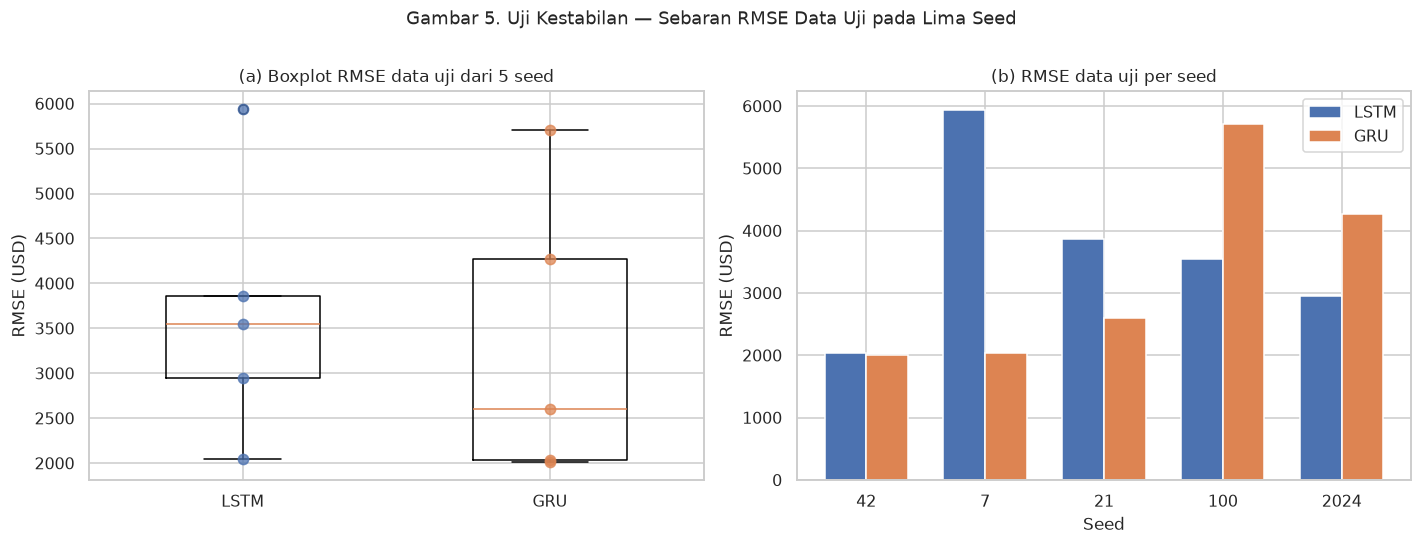


RINGKASAN TAHAP
Dari sisi arsitektur, GRU hanya memakai 3,811 parameter sedangkan LSTM
memakai 8,201 parameter; pada jumlah neuron yang sama, GRU konsisten
membutuhkan sekitar tiga perempat parameter LSTM karena hanya memiliki
tiga himpunan bobot (z, r, h) dibandingkan empat himpunan pada LSTM
(i, f, c, o).

Uji kestabilan pada lima seed menunjukkan RMSE data uji LSTM sebesar
3,670.54 +/- 1,447.10 USD dan GRU sebesar 3,323.79 +/- 1,620.68 USD,
dengan GRU memiliki rata-rata lebih kecil. LSTM unggul pada 2 seed dan
GRU pada 3 seed dari total 5 seed.

Selang rata-rata plus-minus satu standar deviasi kedua model masih
saling tumpang tindih, sehingga perbedaan keduanya belum dapat disebut
tegas secara deskriptif; kesimpulan formal akan diambil melalui uji
Diebold-Mariano pada Tahap 12. Pengujian ini penting untuk memastikan
hasil perbandingan bukan kebetulan akibat inisialisasi bobot acak yang
menguntungkan salah satu model.

Pelatihan ulang dengan seed 42 terbukti menghasilkan prediksi ya

In [39]:
utils.cetak_sub("9.4 Verifikasi reproduksibilitas — seed 42 harus mengulang hasil Tahap 7 & 8")

for tipe, prediksi_utama in [("LSTM", prediksi_uji_lstm_usd), ("GRU", prediksi_uji_gru_usd)]:
    prediksi_ulang_42 = prediksi_seed[tipe][CONFIG["SEED"]]
    selisih_maks = float(np.abs(prediksi_utama - prediksi_ulang_42).max())
    print(f"  {tipe:<5} selisih maksimum prediksi (Tahap 7/8 vs ulangan seed 42) : "
          f"{selisih_maks:.6e} USD")
    assert selisih_maks < 1e-2, (
        f"Model {tipe} tidak reproducible: selisih {selisih_maks}")
print("\n  OK Pelatihan ulang dengan seed 42 menghasilkan prediksi yang sama:")
print("  penguncian seed dan mode deterministik TensorFlow bekerja sebagaimana mestinya.")

utils.cetak_sub("9.5 Gambar 5 — Sebaran RMSE data uji lintas seed")

fig, sumbu = plt.subplots(1, 2, figsize=(13, 4.8))

data_kotak = [tabel_kestabilan.query("Arsitektur == 'LSTM'")["RMSE Uji (USD)"].to_numpy(),
              tabel_kestabilan.query("Arsitektur == 'GRU'")["RMSE Uji (USD)"].to_numpy()]
sumbu[0].boxplot(data_kotak, tick_labels=["LSTM", "GRU"], widths=0.5)
for ke, nilai in enumerate(data_kotak):
    sumbu[0].scatter(np.full(nilai.size, ke + 1), nilai, alpha=0.75, zorder=3, s=45)
sumbu[0].set_title("(a) Boxplot RMSE data uji dari 5 seed")
sumbu[0].set_ylabel("RMSE (USD)")

lebar = 0.35
posisi = np.arange(len(CONFIG["SEED_ULANGAN"]))
rmse_per_seed_lstm = [float(tabel_kestabilan.query("Arsitektur == 'LSTM' and Seed == @s")["RMSE Uji (USD)"].iloc[0])
                      for s in CONFIG["SEED_ULANGAN"]]
rmse_per_seed_gru = [float(tabel_kestabilan.query("Arsitektur == 'GRU' and Seed == @s")["RMSE Uji (USD)"].iloc[0])
                     for s in CONFIG["SEED_ULANGAN"]]
sumbu[1].bar(posisi - lebar / 2, rmse_per_seed_lstm, lebar, label="LSTM")
sumbu[1].bar(posisi + lebar / 2, rmse_per_seed_gru, lebar, label="GRU")
sumbu[1].set_xticks(posisi, [str(s) for s in CONFIG["SEED_ULANGAN"]])
sumbu[1].set_xlabel("Seed"); sumbu[1].set_ylabel("RMSE (USD)")
sumbu[1].set_title("(b) RMSE data uji per seed")
sumbu[1].legend()

fig.suptitle("Gambar 5. Uji Kestabilan — Sebaran RMSE Data Uji pada Lima Seed",
             fontsize=12, y=1.02)
fig.tight_layout()
utils.simpan_gambar(fig, 5, "Uji kestabilan sebaran RMSE data uji lintas seed")
plt.show()

model_unggul_kestabilan = "GRU" if rmse_rata_gru < rmse_rata_lstm else "LSTM"
utils.ringkasan_tahap(f"""
Dari sisi arsitektur, GRU hanya memakai {utils.fmt_int(model_gru.count_params())}
parameter sedangkan LSTM memakai {utils.fmt_int(model_lstm.count_params())}
parameter; pada jumlah neuron yang sama, GRU konsisten membutuhkan sekitar tiga
perempat parameter LSTM karena hanya memiliki tiga himpunan bobot (z, r, h)
dibandingkan empat himpunan pada LSTM (i, f, c, o).

Uji kestabilan pada lima seed menunjukkan RMSE data uji LSTM sebesar
{utils.fmt_usd(rmse_rata_lstm)} +/- {utils.fmt_usd(rmse_std_lstm)} USD dan GRU
sebesar {utils.fmt_usd(rmse_rata_gru)} +/- {utils.fmt_usd(rmse_std_gru)} USD,
dengan {model_unggul_kestabilan} memiliki rata-rata lebih kecil. LSTM unggul
pada {menang_lstm} seed dan GRU pada {menang_gru} seed dari total
{len(CONFIG['SEED_ULANGAN'])} seed.

Selang rata-rata plus-minus satu standar deviasi kedua model
{'masih saling tumpang tindih, sehingga perbedaan keduanya belum dapat disebut tegas' if tumpang_tindih else 'tidak saling tumpang tindih, sehingga perbedaan keduanya cukup tegas'}
secara deskriptif; kesimpulan formal akan diambil melalui uji Diebold-Mariano
pada Tahap 12. Pengujian ini penting untuk memastikan hasil perbandingan bukan
kebetulan akibat inisialisasi bobot acak yang menguntungkan salah satu model.

Pelatihan ulang dengan seed 42 terbukti menghasilkan prediksi yang sama persis
dengan Tahap 7 dan 8, sehingga seluruh angka pada skripsi ini dapat direproduksi.
""")

---
## TAHAP 10 — Denormalisasi

**Tujuan.** Mengembalikan prediksi dari skala $[0,1]$ ke skala harga asli (USD)
agar dapat dibandingkan langsung dengan harga Bitcoin sebenarnya.

**Rumus denormalisasi** (kebalikan dari Tahap 5):

$$x = x' \times \left(x_{max} - x_{min}\right) + x_{min}$$

dengan $x_{min}$ dan $x_{max}$ **sama dengan yang dipakai saat normalisasi**,
yaitu berasal dari data latih.

**Mengapa penting?** Seluruh metrik evaluasi (RMSE, MAE, MAPE) baru bermakna
secara ekonomis bila dinyatakan dalam USD. RMSE sebesar $0{,}02$ pada skala
ternormalisasi sulit ditafsirkan, tetapi RMSE sebesar $2{.}000$ USD langsung
dapat dinilai besar atau kecilnya relatif terhadap harga Bitcoin.

In [40]:
utils.cetak_header(10, "Denormalisasi")

utils.cetak_sub("10.1 PERHITUNGAN MANUAL — denormalisasi prediksi hari pertama")

baris_manual = []


def tulis(teks: str = "") -> None:
    print(teks)
    baris_manual.append(teks)


x_min_target = float(penskala_y.data_min_[0])
x_max_target = float(penskala_y.data_max_[0])
tgl_prediksi_pertama = pd.Timestamp(tanggal_uji[0]).date()

tulis("(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH")
tulis()
tulis(f"Tanggal prediksi : {tgl_prediksi_pertama} (hari pertama data uji)")
tulis()
tulis("Rumus:  x = x' * (x_max - x_min) + x_min")
tulis()
tulis(f"  x_min = {utils.fmt_usd(x_min_target)} USD   (harga terendah DATA LATIH)")
tulis(f"  x_max = {utils.fmt_usd(x_max_target)} USD   (harga tertinggi DATA LATIH)")
rentang_target = x_max_target - x_min_target
tulis(f"  x_max - x_min = {utils.fmt_usd(rentang_target)} USD")
tulis()

hasil_denormalisasi = {}
for nama_model, prediksi_norm in [("LSTM", prediksi_uji_lstm_norm),
                                  ("GRU", prediksi_uji_gru_norm)]:
    x_aksen = float(prediksi_norm[0])
    hasil_kali = x_aksen * rentang_target
    x_manual = hasil_kali + x_min_target
    x_library = float(penskala_y.inverse_transform([[x_aksen]])[0, 0])
    hasil_denormalisasi[nama_model] = (x_aksen, x_manual, x_library)

    tulis(f"  MODEL {nama_model}")
    tulis(f"    x' (prediksi ternormalisasi) = {utils.fmt_norm(x_aksen)}")
    tulis(f"    x = {utils.fmt_norm(x_aksen)} * {utils.fmt_usd(rentang_target)} "
          f"+ {utils.fmt_usd(x_min_target)}")
    tulis(f"    x = {utils.fmt_usd(hasil_kali)} + {utils.fmt_usd(x_min_target)}")
    tulis(f"    x = {utils.fmt_usd(x_manual)} USD   <- hasil manual")
    tulis()

tulis("(b) PEMBANDINGAN DENGAN HASIL LIBRARY (scaler.inverse_transform)")
tulis()
tulis(f"  {'Model':<8}{'Manual (USD)':>18}{'inverse_transform (USD)':>26}{'Selisih':>14}")
for nama_model, (x_aksen, x_manual, x_library) in hasil_denormalisasi.items():
    tulis(f"  {nama_model:<8}{utils.fmt_usd(x_manual):>18}{utils.fmt_usd(x_library):>26}"
          f"{abs(x_manual - x_library):>14.2e}")
    assert np.isclose(x_manual, x_library, atol=1e-5), f"Denormalisasi {nama_model} tidak cocok"
tulis()
tulis(f"  Harga AKTUAL {tgl_prediksi_pertama} = {utils.fmt_usd(aktual_uji_usd[0])} USD")
for nama_model, (_, x_manual, _) in hasil_denormalisasi.items():
    galat_hari1 = aktual_uji_usd[0] - x_manual
    tulis(f"    Galat {nama_model:<5} = {utils.fmt_usd(aktual_uji_usd[0])} - "
          f"{utils.fmt_usd(x_manual)} = {utils.fmt_usd(galat_hari1)} USD "
          f"({'underestimate' if galat_hari1 > 0 else 'overestimate'})")
tulis()
tulis("  OK Hasil manual SAMA dengan hasil model (toleransi 1e-5)")

print("\n✔ Hasil manual SAMA dengan hasil model")

utils.tulis_manual(10, "Denormalisasi Prediksi ke Skala USD", f"""
## Rumus

$$x = x' \\times \\left(x_{{max}} - x_{{min}}\\right) + x_{{min}}$$

dengan $x_{{min}} = {utils.fmt_usd(x_min_target)}$ USD dan
$x_{{max}} = {utils.fmt_usd(x_max_target)}$ USD, keduanya berasal dari data latih.

## Perhitungan

{utils.blok_kode(chr(10).join(baris_manual))}

## Kesimpulan

Denormalisasi manual menghasilkan angka yang identik dengan
`penskala.inverse_transform()` sampai toleransi $10^{{-5}}$, sehingga seluruh
prediksi pada Tahap 11 dapat dinyatakan dalam USD dengan yakin.
""")

TAHAP 10 - DENORMALISASI

----------------------------------------------------------------------
10.1 PERHITUNGAN MANUAL — denormalisasi prediksi hari pertama
----------------------------------------------------------------------
(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH

Tanggal prediksi : 2025-12-18 (hari pertama data uji)

Rumus:  x = x' * (x_max - x_min) + x_min

  x_min = 25,162.70 USD   (harga terendah DATA LATIH)
  x_max = 123,359.45 USD   (harga tertinggi DATA LATIH)
  x_max - x_min = 98,196.75 USD

  MODEL LSTM
    x' (prediksi ternormalisasi) = 0.642306
    x = 0.642306 * 98,196.75 + 25,162.70
    x = 63,072.39 + 25,162.70
    x = 88,235.09 USD   <- hasil manual

  MODEL GRU
    x' (prediksi ternormalisasi) = 0.647681
    x = 0.647681 * 98,196.75 + 25,162.70
    x = 63,600.22 + 25,162.70
    x = 88,762.92 USD   <- hasil manual

(b) PEMBANDINGAN DENGAN HASIL LIBRARY (scaler.inverse_transform)

  Model         Manual (USD)   inverse_transform (USD)       Selisih
  LSTM       

'/home/user/prediction-lstm-gru-btc/outputs/perhitungan_manual/tahap_10.md'

In [41]:
utils.cetak_sub("10.2 Tabel 15 — Hasil prediksi dalam skala USD")

tabel_prediksi = pd.DataFrame({
    "Tanggal": [pd.Timestamp(t).date() for t in tanggal_uji],
    "Aktual (USD)": aktual_uji_usd,
    "Prediksi LSTM (USD)": prediksi_uji_lstm_usd,
    "Prediksi GRU (USD)": prediksi_uji_gru_usd,
})
tabel_prediksi["Galat LSTM (USD)"] = tabel_prediksi["Aktual (USD)"] - tabel_prediksi["Prediksi LSTM (USD)"]
tabel_prediksi["Galat GRU (USD)"] = tabel_prediksi["Aktual (USD)"] - tabel_prediksi["Prediksi GRU (USD)"]
tabel_prediksi["APE LSTM (%)"] = (tabel_prediksi["Galat LSTM (USD)"].abs()
                                  / tabel_prediksi["Aktual (USD)"] * 100)
tabel_prediksi["APE GRU (%)"] = (tabel_prediksi["Galat GRU (USD)"].abs()
                                 / tabel_prediksi["Aktual (USD)"] * 100)

with pd.option_context("display.float_format", lambda v: f"{v:,.2f}"):
    print("  LIMA BARIS PERTAMA:")
    print(tabel_prediksi.head(5).to_string(index=False))
    print("\n  LIMA BARIS TERAKHIR:")
    print(tabel_prediksi.tail(5).to_string(index=False))

utils.simpan_tabel(tabel_prediksi, 15, "Hasil denormalisasi prediksi ke skala USD")
utils.cetak_shape("tabel_prediksi", tabel_prediksi)
print(f"\n  Berkas lengkap berisi seluruh {utils.fmt_int(len(tabel_prediksi))} hari uji "
      f"telah disimpan ke folder outputs/tabel/.")

utils.ringkasan_tahap(f"""
Seluruh prediksi kedua model telah dikembalikan ke skala USD memakai nilai
x_min = {utils.fmt_usd(x_min_target)} USD dan x_max = {utils.fmt_usd(x_max_target)} USD
dari data latih, dan perhitungan manual untuk hari pertama terbukti identik
dengan inverse_transform.

Tabel {utils.fmt_int(len(tabel_prediksi))} hari uji
({tabel_prediksi['Tanggal'].iloc[0]} s.d. {tabel_prediksi['Tanggal'].iloc[-1]})
berisi harga aktual, prediksi kedua model, galat, serta persentase galat absolut
harian, dan telah disimpan lengkap ke folder outputs/tabel/ untuk lampiran skripsi.

Pada hari pertama data uji, harga aktual {utils.fmt_usd(aktual_uji_usd[0])} USD
diprediksi LSTM sebesar {utils.fmt_usd(prediksi_uji_lstm_usd[0])} USD dan GRU
sebesar {utils.fmt_usd(prediksi_uji_gru_usd[0])} USD.
""")


----------------------------------------------------------------------
10.2 Tabel 15 — Hasil prediksi dalam skala USD
----------------------------------------------------------------------
  LIMA BARIS PERTAMA:
   Tanggal  Aktual (USD)  Prediksi LSTM (USD)  Prediksi GRU (USD)  Galat LSTM (USD)  Galat GRU (USD)  APE LSTM (%)  APE GRU (%)
2025-12-18     86,132.82            88,235.09           88,762.92         -2,102.27        -2,630.10          2.44         3.05
2025-12-19     85,458.35            86,359.86           87,246.46           -901.51        -1,788.11          1.05         2.09
2025-12-20     88,098.82            85,962.64           87,038.05          2,136.17         1,060.77          2.42         1.20
2025-12-21     88,337.41            87,684.05           88,649.40            653.36          -311.99          0.74         0.35
2025-12-22     88,615.72            87,909.55           88,845.88            706.17          -230.16          0.80         0.26

  LIMA BARIS TERAKH

  [tersimpan] Tabel 15. Hasil denormalisasi prediksi ke skala USD
              -> outputs/tabel/tabel_15_hasil_denormalisasi_prediksi_ke_skala_usd.csv / .xlsx
  shape tabel_prediksi               = (226, 8)

  Berkas lengkap berisi seluruh 226 hari uji telah disimpan ke folder outputs/tabel/.

RINGKASAN TAHAP
Seluruh prediksi kedua model telah dikembalikan ke skala USD memakai
nilai x_min = 25,162.70 USD dan x_max = 123,359.45 USD dari data
latih, dan perhitungan manual untuk hari pertama terbukti identik
dengan inverse_transform.

Tabel 226 hari uji (2025-12-18 s.d. 2026-07-31) berisi harga aktual,
prediksi kedua model, galat, serta persentase galat absolut harian,
dan telah disimpan lengkap ke folder outputs/tabel/ untuk lampiran
skripsi.

Pada hari pertama data uji, harga aktual 86,132.82 USD diprediksi LSTM
sebesar 88,235.09 USD dan GRU sebesar 88,762.92 USD.



---
## TAHAP 11 — Evaluasi Model

**Tujuan.** Mengukur ketepatan prediksi kedua model pada **data uji** yang belum
pernah dipakai untuk melatih maupun memilih *hyperparameter*.

**Empat metrik yang dipakai.**

**1. RMSE** (*Root Mean Squared Error*) — satuan USD, menghukum galat besar lebih berat:

$$RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^{n}\left(y_t - \hat{y}_t\right)^2}$$

> **Urutan wajib:** kuadratkan $\rightarrow$ rata-ratakan $\rightarrow$ akarkan.
> Kesalahan umum adalah mengakarkan tiap galat lebih dahulu, yang menghasilkan
> angka berbeda dan keliru.

**2. MAE** (*Mean Absolute Error*) — satuan USD, memperlakukan semua galat setara:

$$MAE = \frac{1}{n}\sum_{t=1}^{n}\left|y_t - \hat{y}_t\right|$$

**3. MAPE** (*Mean Absolute Percentage Error*) — satuan persen, bebas skala:

$$MAPE = \frac{100\%}{n}\sum_{t=1}^{n}\left|\frac{y_t - \hat{y}_t}{y_t}\right|$$

| MAPE | Kategori kemampuan peramalan (Lewis, 1982) |
|---|---|
| $<10\%$ | Sangat baik |
| $10\%-20\%$ | Baik |
| $20\%-50\%$ | Cukup |
| $>50\%$ | Buruk |

**4. Akurasi arah** (*directional accuracy*) — persentase hari yang arah naik/turunnya tertebak benar:

$$DA = \frac{100\%}{n}\sum_{t=1}^{n}\mathbb{1}\!\left[\operatorname{sign}\left(y_t - y_{t-1}\right)
= \operatorname{sign}\left(\hat{y}_t - y_{t-1}\right)\right]$$

dengan $y_{t-1}$ = harga **aktual** sehari sebelumnya, sehingga arah aktual dan
arah prediksi diukur dari titik acuan yang sama.

In [42]:
utils.cetak_header(11, "Evaluasi model")

utils.cetak_sub("11.1 PERHITUNGAN MANUAL — rincian galat tiga hari pertama")

baris_manual = []


def tulis(teks: str = "") -> None:
    print(teks)
    baris_manual.append(teks)


n_uji_sampel = len(aktual_uji_usd)

tulis("(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH")
tulis()
tulis(f"Jumlah hari uji  n = {utils.fmt_int(n_uji_sampel)}")
tulis()

for nama_model, prediksi_usd in [("LSTM", prediksi_uji_lstm_usd),
                                 ("GRU", prediksi_uji_gru_usd)]:
    galat = aktual_uji_usd - prediksi_usd
    galat_kuadrat = galat ** 2
    galat_absolut = np.abs(galat)
    persen_galat = galat_absolut / aktual_uji_usd * 100.0

    tulis("=" * 66)
    tulis(f"MODEL {nama_model}")
    tulis("=" * 66)
    tulis(f"  {'Hari':<5}{'Tanggal':<12}{'Aktual y':>14}{'Prediksi y_hat':>17}"
          f"{'e = y - y_hat':>16}{'e^2':>18}{'|e/y| x 100%':>15}")
    for k in range(3):
        tulis(f"  {k + 1:<5}{str(pd.Timestamp(tanggal_uji[k]).date()):<12}"
              f"{utils.fmt_usd(aktual_uji_usd[k]):>14}{utils.fmt_usd(prediksi_usd[k]):>17}"
              f"{utils.fmt_usd(galat[k]):>16}{utils.fmt_usd(galat_kuadrat[k]):>18}"
              f"{persen_galat[k]:>14.4f}%")
    tulis(f"  {'...':<5}{'...':<12}{'...':>14}{'...':>17}{'...':>16}{'...':>18}{'...':>15}")
    tulis(f"  {n_uji_sampel:<5}{str(pd.Timestamp(tanggal_uji[-1]).date()):<12}"
          f"{utils.fmt_usd(aktual_uji_usd[-1]):>14}{utils.fmt_usd(prediksi_usd[-1]):>17}"
          f"{utils.fmt_usd(galat[-1]):>16}{utils.fmt_usd(galat_kuadrat[-1]):>18}"
          f"{persen_galat[-1]:>14.4f}%")
    tulis()

    tulis("  CARA MERATA-RATAKAN (tiga suku pertama ditampilkan, sisanya dijumlahkan):")
    tulis()
    # --- RMSE: kuadratkan -> rata-ratakan -> akarkan ----------------------- #
    jumlah_kuadrat = float(galat_kuadrat.sum())
    rerata_kuadrat = jumlah_kuadrat / n_uji_sampel
    rmse_manual = float(np.sqrt(rerata_kuadrat))
    tulis("  RMSE  (urutan wajib: kuadratkan -> rata-ratakan -> akarkan)")
    tulis(f"    Langkah 1 (kuadratkan): e^2 = {utils.fmt_usd(galat_kuadrat[0])}, "
          f"{utils.fmt_usd(galat_kuadrat[1])}, {utils.fmt_usd(galat_kuadrat[2])}, ...")
    tulis(f"    Langkah 2 (jumlahkan) : SUM e^2 = {utils.fmt_usd(jumlah_kuadrat)}")
    tulis(f"    Langkah 3 (rata-rata) : SUM e^2 / n = {utils.fmt_usd(jumlah_kuadrat)} / "
          f"{n_uji_sampel} = {utils.fmt_usd(rerata_kuadrat)}")
    tulis(f"    Langkah 4 (akarkan)   : RMSE = akar({utils.fmt_usd(rerata_kuadrat)}) "
          f"= {utils.fmt_usd(rmse_manual)} USD")
    tulis()

    # --- MAE --------------------------------------------------------------- #
    jumlah_absolut = float(galat_absolut.sum())
    mae_manual = jumlah_absolut / n_uji_sampel
    tulis("  MAE")
    tulis(f"    |e| = {utils.fmt_usd(galat_absolut[0])}, {utils.fmt_usd(galat_absolut[1])}, "
          f"{utils.fmt_usd(galat_absolut[2])}, ...")
    tulis(f"    SUM |e| = {utils.fmt_usd(jumlah_absolut)}")
    tulis(f"    MAE = {utils.fmt_usd(jumlah_absolut)} / {n_uji_sampel} "
          f"= {utils.fmt_usd(mae_manual)} USD")
    tulis()

    # --- MAPE -------------------------------------------------------------- #
    jumlah_persen = float(persen_galat.sum())
    mape_manual = jumlah_persen / n_uji_sampel
    tulis("  MAPE")
    tulis(f"    |e/y| x 100% = {persen_galat[0]:.4f}%, {persen_galat[1]:.4f}%, "
          f"{persen_galat[2]:.4f}%, ...")
    tulis(f"    SUM = {jumlah_persen:,.4f}%")
    tulis(f"    MAPE = {jumlah_persen:,.4f}% / {n_uji_sampel} = {mape_manual:.4f}%")
    tulis()

    # --- Akurasi arah ------------------------------------------------------ #
    arah_aktual = np.sign(aktual_uji_usd - harga_sebelumnya_uji)
    arah_prediksi = np.sign(prediksi_usd - harga_sebelumnya_uji)
    benar = (arah_aktual == arah_prediksi)
    da_manual = float(benar.mean() * 100.0)
    tulis("  AKURASI ARAH")
    tulis(f"    {'Hari':<5}{'y(t-1)':>14}{'y(t)':>14}{'y_hat(t)':>14}"
          f"{'arah aktual':>14}{'arah prediksi':>16}{'cocok?':>9}")
    for k in range(3):
        tulis(f"    {k + 1:<5}{utils.fmt_usd(harga_sebelumnya_uji[k]):>14}"
              f"{utils.fmt_usd(aktual_uji_usd[k]):>14}{utils.fmt_usd(prediksi_usd[k]):>14}"
              f"{('NAIK' if arah_aktual[k] > 0 else 'TURUN'):>14}"
              f"{('NAIK' if arah_prediksi[k] > 0 else 'TURUN'):>16}"
              f"{('YA' if benar[k] else 'TIDAK'):>9}")
    tulis(f"    Jumlah arah benar = {utils.fmt_int(int(benar.sum()))} dari "
          f"{utils.fmt_int(n_uji_sampel)} hari")
    tulis(f"    DA = {int(benar.sum())} / {n_uji_sampel} x 100% = {da_manual:.4f}%")
    tulis()

    # --- (b) pembandingan dengan fungsi library --------------------------- #
    rmse_library = metrik.rmse(aktual_uji_usd, prediksi_usd)
    mae_library = metrik.mae(aktual_uji_usd, prediksi_usd)
    mape_library = metrik.mape(aktual_uji_usd, prediksi_usd)
    da_library = metrik.akurasi_arah(aktual_uji_usd, prediksi_usd, harga_sebelumnya_uji)

    tulis(f"  (b) PEMBANDINGAN DENGAN FUNGSI metrik.py — MODEL {nama_model}")
    tulis(f"    {'Metrik':<18}{'Manual':>18}{'Fungsi library':>20}{'Selisih':>14}")
    for nama_metrik, nilai_manual, nilai_library in [
        ("RMSE (USD)", rmse_manual, rmse_library),
        ("MAE (USD)", mae_manual, mae_library),
        ("MAPE (%)", mape_manual, mape_library),
        ("Akurasi Arah (%)", da_manual, da_library),
    ]:
        tulis(f"    {nama_metrik:<18}{nilai_manual:>18,.6f}{nilai_library:>20,.6f}"
              f"{abs(nilai_manual - nilai_library):>14.2e}")
        assert np.isclose(nilai_manual, nilai_library, atol=1e-5), \
            f"{nama_metrik} manual != library untuk {nama_model}"
    tulis(f"    OK Hasil manual SAMA dengan hasil model (toleransi 1e-5)")
    tulis()

print("\n✔ Hasil manual SAMA dengan hasil model")

TAHAP 11 - EVALUASI MODEL

----------------------------------------------------------------------
11.1 PERHITUNGAN MANUAL — rincian galat tiga hari pertama
----------------------------------------------------------------------
(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH

Jumlah hari uji  n = 226

MODEL LSTM
  Hari Tanggal           Aktual y   Prediksi y_hat   e = y - y_hat               e^2   |e/y| x 100%
  1    2025-12-18       86,132.82        88,235.09       -2,102.27      4,419,556.89        2.4407%
  2    2025-12-19       85,458.35        86,359.86         -901.51        812,712.37        1.0549%
  3    2025-12-20       88,098.82        85,962.64        2,136.17      4,563,242.32        2.4247%
  ...  ...                    ...              ...             ...               ...            ...
  226  2026-07-31       64,720.99        62,368.96        2,352.03      5,532,057.75        3.6341%

  CARA MERATA-RATAKAN (tiga suku pertama ditampilkan, sisanya dijumlahkan):

  RMSE  (urut

In [43]:
utils.cetak_sub("11.2 Tabel 16 — Rincian galat tiga hari pertama (untuk lampiran skripsi)")

rincian_tiga_hari = pd.DataFrame({
    "Hari ke-": [1, 2, 3],
    "Tanggal": [pd.Timestamp(t).date() for t in tanggal_uji[:3]],
    "Aktual y (USD)": aktual_uji_usd[:3],
    "Prediksi LSTM (USD)": prediksi_uji_lstm_usd[:3],
    "Galat LSTM e (USD)": (aktual_uji_usd - prediksi_uji_lstm_usd)[:3],
    "Galat^2 LSTM": ((aktual_uji_usd - prediksi_uji_lstm_usd) ** 2)[:3],
    "APE LSTM (%)": (np.abs(aktual_uji_usd - prediksi_uji_lstm_usd) / aktual_uji_usd * 100)[:3],
    "Prediksi GRU (USD)": prediksi_uji_gru_usd[:3],
    "Galat GRU e (USD)": (aktual_uji_usd - prediksi_uji_gru_usd)[:3],
    "Galat^2 GRU": ((aktual_uji_usd - prediksi_uji_gru_usd) ** 2)[:3],
    "APE GRU (%)": (np.abs(aktual_uji_usd - prediksi_uji_gru_usd) / aktual_uji_usd * 100)[:3],
})
with pd.option_context("display.float_format", lambda v: f"{v:,.4f}"):
    print(rincian_tiga_hari.T.to_string())
utils.simpan_tabel(rincian_tiga_hari, 16, "Rincian perhitungan galat tiga hari pertama")

utils.cetak_sub("11.3 Tabel 17 — Perbandingan metrik evaluasi akhir LSTM vs GRU")

metrik_lstm = metrik.semua_metrik(aktual_uji_usd, prediksi_uji_lstm_usd, harga_sebelumnya_uji)
metrik_gru = metrik.semua_metrik(aktual_uji_usd, prediksi_uji_gru_usd, harga_sebelumnya_uji)

tabel_evaluasi = pd.DataFrame([
    {"Metrik": "Konfigurasi terbaik",
     "LSTM": f"{neuron_lstm} neuron, {epoch_lstm} epoch",
     "GRU": f"{neuron_gru} neuron, {epoch_gru} epoch", "Model Lebih Baik": "—"},
    {"Metrik": "RMSE (USD)", "LSTM": utils.fmt_usd(metrik_lstm["RMSE (USD)"]),
     "GRU": utils.fmt_usd(metrik_gru["RMSE (USD)"]),
     "Model Lebih Baik": "LSTM" if metrik_lstm["RMSE (USD)"] < metrik_gru["RMSE (USD)"] else "GRU"},
    {"Metrik": "MAE (USD)", "LSTM": utils.fmt_usd(metrik_lstm["MAE (USD)"]),
     "GRU": utils.fmt_usd(metrik_gru["MAE (USD)"]),
     "Model Lebih Baik": "LSTM" if metrik_lstm["MAE (USD)"] < metrik_gru["MAE (USD)"] else "GRU"},
    {"Metrik": "MAPE (%)", "LSTM": f"{metrik_lstm['MAPE (%)']:.4f}",
     "GRU": f"{metrik_gru['MAPE (%)']:.4f}",
     "Model Lebih Baik": "LSTM" if metrik_lstm["MAPE (%)"] < metrik_gru["MAPE (%)"] else "GRU"},
    {"Metrik": "Kategori MAPE", "LSTM": metrik_lstm["Kategori MAPE"],
     "GRU": metrik_gru["Kategori MAPE"], "Model Lebih Baik": "—"},
    {"Metrik": "Akurasi Arah (%)", "LSTM": f"{metrik_lstm['Akurasi Arah (%)']:.4f}",
     "GRU": f"{metrik_gru['Akurasi Arah (%)']:.4f}",
     "Model Lebih Baik": "LSTM" if metrik_lstm["Akurasi Arah (%)"] > metrik_gru["Akurasi Arah (%)"] else "GRU"},
    {"Metrik": "Jumlah parameter", "LSTM": utils.fmt_int(model_lstm.count_params()),
     "GRU": utils.fmt_int(model_gru.count_params()),
     "Model Lebih Baik": "GRU" if model_gru.count_params() < model_lstm.count_params() else "LSTM"},
    {"Metrik": "Waktu latih total (detik)", "LSTM": f"{waktu_lstm:,.2f}",
     "GRU": f"{waktu_gru:,.2f}",
     "Model Lebih Baik": "GRU" if waktu_gru < waktu_lstm else "LSTM"},
    {"Metrik": "Waktu latih per epoch (detik)", "LSTM": f"{waktu_lstm / epoch_lstm:,.4f}",
     "GRU": f"{waktu_gru / epoch_gru:,.4f}",
     "Model Lebih Baik": "GRU" if (waktu_gru / epoch_gru) < (waktu_lstm / epoch_lstm) else "LSTM"},
])
print(tabel_evaluasi.to_string(index=False))
utils.simpan_tabel(tabel_evaluasi, 17, "Perbandingan metrik evaluasi akhir LSTM vs GRU")

model_akurasi_terbaik = "LSTM" if metrik_lstm["RMSE (USD)"] < metrik_gru["RMSE (USD)"] else "GRU"
selisih_rmse = abs(metrik_lstm["RMSE (USD)"] - metrik_gru["RMSE (USD)"])
persen_selisih_rmse = selisih_rmse / max(metrik_lstm["RMSE (USD)"], metrik_gru["RMSE (USD)"]) * 100

print(f"\n  Model dengan RMSE data uji terkecil : {model_akurasi_terbaik}")
print(f"  Selisih RMSE kedua model            : {utils.fmt_usd(selisih_rmse)} USD "
      f"({persen_selisih_rmse:.2f}% dari RMSE terbesar)")

utils.tulis_manual(11, "Metrik Evaluasi (RMSE, MAE, MAPE, Akurasi Arah)", f"""
## Rumus

$$RMSE = \\sqrt{{\\frac{{1}}{{n}}\\sum_{{t=1}}^{{n}}\\left(y_t - \\hat{{y}}_t\\right)^2}}
\\qquad
MAE = \\frac{{1}}{{n}}\\sum_{{t=1}}^{{n}}\\left|y_t - \\hat{{y}}_t\\right|$$

$$MAPE = \\frac{{100\\%}}{{n}}\\sum_{{t=1}}^{{n}}\\left|\\frac{{y_t - \\hat{{y}}_t}}{{y_t}}\\right|
\\qquad
DA = \\frac{{100\\%}}{{n}}\\sum_{{t=1}}^{{n}}\\mathbb{{1}}\\!\\left[\\operatorname{{sign}}(y_t - y_{{t-1}})
= \\operatorname{{sign}}(\\hat{{y}}_t - y_{{t-1}})\\right]$$

dengan $n = {utils.fmt_int(n_uji_sampel)}$ hari data uji.

## Perhitungan

{utils.blok_kode(chr(10).join(baris_manual))}

## Kesimpulan

| Metrik | LSTM | GRU |
|---|---|---|
| RMSE (USD) | {utils.fmt_usd(metrik_lstm['RMSE (USD)'])} | {utils.fmt_usd(metrik_gru['RMSE (USD)'])} |
| MAE (USD) | {utils.fmt_usd(metrik_lstm['MAE (USD)'])} | {utils.fmt_usd(metrik_gru['MAE (USD)'])} |
| MAPE (%) | {metrik_lstm['MAPE (%)']:.4f} | {metrik_gru['MAPE (%)']:.4f} |
| Kategori MAPE | {metrik_lstm['Kategori MAPE']} | {metrik_gru['Kategori MAPE']} |
| Akurasi arah (%) | {metrik_lstm['Akurasi Arah (%)']:.4f} | {metrik_gru['Akurasi Arah (%)']:.4f} |

Seluruh metrik hasil hitung tangan cocok dengan fungsi pada `src/metrik.py`
sampai toleransi $10^{{-5}}$.
""")

utils.ringkasan_tahap(f"""
Pada data uji sebanyak {utils.fmt_int(n_uji_sampel)} hari, LSTM memperoleh RMSE
{utils.fmt_usd(metrik_lstm['RMSE (USD)'])} USD, MAE
{utils.fmt_usd(metrik_lstm['MAE (USD)'])} USD, dan MAPE
{metrik_lstm['MAPE (%)']:.4f}% ({metrik_lstm['Kategori MAPE']}), sedangkan GRU
memperoleh RMSE {utils.fmt_usd(metrik_gru['RMSE (USD)'])} USD, MAE
{utils.fmt_usd(metrik_gru['MAE (USD)'])} USD, dan MAPE
{metrik_gru['MAPE (%)']:.4f}% ({metrik_gru['Kategori MAPE']}).

Model dengan RMSE terkecil adalah {model_akurasi_terbaik}, dengan selisih
{utils.fmt_usd(selisih_rmse)} USD atau sekitar {persen_selisih_rmse:.2f}% saja —
selisih yang relatif kecil dibandingkan tingkat harga Bitcoin. Akurasi arah
kedua model ({metrik_lstm['Akurasi Arah (%)']:.2f}% untuk LSTM dan
{metrik_gru['Akurasi Arah (%)']:.2f}% untuk GRU) menunjukkan seberapa sering
arah pergerakan harga tertebak benar.

Seluruh metrik telah diverifikasi lewat perhitungan manual tiga hari pertama,
termasuk urutan perhitungan RMSE yang benar (kuadratkan, rata-ratakan, lalu
akarkan). Apakah selisih akurasi keduanya bermakna secara statistik akan diuji
pada Tahap 12.
""")


----------------------------------------------------------------------
11.2 Tabel 16 — Rincian galat tiga hari pertama (untuk lampiran skripsi)
----------------------------------------------------------------------
                                 0              1              2
Hari ke-                         1              2              3
Tanggal                 2025-12-18     2025-12-19     2025-12-20
Aktual y (USD)         86,132.8197    85,458.3513    88,098.8189
Prediksi LSTM (USD)    88,235.0939    86,359.8569    85,962.6442
Galat LSTM e (USD)     -2,102.2742      -901.5056     2,136.1747
Galat^2 LSTM        4,419,556.8923   812,712.3729 4,563,242.3197
APE LSTM (%)                2.4407         1.0549         2.4247
Prediksi GRU (USD)     88,762.9158    87,246.4608    87,038.0536
Galat GRU e (USD)      -2,630.0962    -1,788.1095     1,060.7653
Galat^2 GRU         6,917,405.8745 3,197,335.7116 1,125,222.9487
APE GRU (%)                 3.0535         2.0924         1.2041
  [t

---
## TAHAP 12 — Uji Signifikansi Diebold-Mariano

**Tujuan.** Menjawab pertanyaan: apakah selisih akurasi LSTM dan GRU **bermakna
secara statistik**, atau hanya kebetulan sampel?

**Pasangan yang diuji:** LSTM vs GRU (satu pasang, sesuai rancangan penelitian).

**Hipotesis.**

$$H_0: E\!\left[d_t\right] = 0 \quad \text{(akurasi LSTM dan GRU sama)}$$
$$H_1: E\!\left[d_t\right] \neq 0 \quad \text{(akurasi LSTM dan GRU berbeda)}$$

**Langkah perhitungan.**

**1. Selisih *loss*** (di sini memakai *loss* kuadrat):

$$d_t = e_{LSTM,t}^2 - e_{GRU,t}^2$$

**2. Rata-rata selisih:** $\displaystyle \bar{d} = \frac{1}{T}\sum_{t=1}^{T} d_t$

**3. Autokovarians:** $\displaystyle \gamma_k = \frac{1}{T}\sum_{t=k+1}^{T}\left(d_t-\bar{d}\right)\left(d_{t-k}-\bar{d}\right)$

**4. Varians $\bar{d}$:** $\displaystyle \widehat{V}\!\left(\bar{d}\right) = \frac{1}{T}\left[\gamma_0 + 2\sum_{k=1}^{h-1}\gamma_k\right]$

Untuk $h = 1$ (peramalan satu langkah ke depan), suku penjumlahan kosong sehingga
$\widehat{V}(\bar{d}) = \gamma_0 / T$.

**5. Statistik DM:** $\displaystyle DM = \frac{\bar{d}}{\sqrt{\widehat{V}\!\left(\bar{d}\right)}}$

**6. Koreksi Harvey-Leybourne-Newbold (1997)** untuk sampel kecil:

$$DM^{*} = DM \times \sqrt{\frac{T + 1 - 2h + \frac{h(h-1)}{T}}{T}}$$

**7. *p-value*** dua sisi dari distribusi $t$ dengan derajat bebas $T-1$:

$$p = 2\left[1 - F_{t,\,T-1}\left(\left|DM^{*}\right|\right)\right]$$

**Kaidah keputusan pada $\alpha = 5\%$.** Tolak $H_0$ bila $p < 0{,}05$.

**Arti tanda $DM^{*}$.** Nilai **negatif** berarti $e_{LSTM}^2 < e_{GRU}^2$
sehingga **LSTM lebih akurat**; nilai **positif** berarti **GRU lebih akurat**.

In [44]:
utils.cetak_header(12, "Uji signifikansi Diebold-Mariano")

utils.cetak_sub("12.1 PERHITUNGAN MANUAL — statistik Diebold-Mariano")

baris_manual = []


def tulis(teks: str = "") -> None:
    print(teks)
    baris_manual.append(teks)


galat_lstm = aktual_uji_usd - prediksi_uji_lstm_usd
galat_gru = aktual_uji_usd - prediksi_uji_gru_usd

tulis("(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH")
tulis()
tulis("HIPOTESIS")
tulis("  H0 : E[d_t] = 0   (akurasi LSTM dan GRU sama)")
tulis("  H1 : E[d_t] != 0  (akurasi LSTM dan GRU berbeda)")
tulis("  Fungsi loss : kuadrat (p = 2);  horizon h = 1;  alpha = 5%")
tulis()

# --- Langkah 1: d_t -------------------------------------------------------- #
d = galat_lstm ** 2 - galat_gru ** 2
T = d.size
tulis("LANGKAH 1 — Hitung d_t = e_LSTM,t^2 - e_GRU,t^2")
tulis()
tulis(f"  {'Hari':<5}{'Tanggal':<12}{'e_LSTM':>14}{'e_GRU':>14}"
      f"{'e_LSTM^2':>18}{'e_GRU^2':>18}{'d_t':>18}")
for k in range(6):
    tulis(f"  {k + 1:<5}{str(pd.Timestamp(tanggal_uji[k]).date()):<12}"
          f"{utils.fmt_usd(galat_lstm[k]):>14}{utils.fmt_usd(galat_gru[k]):>14}"
          f"{utils.fmt_usd(galat_lstm[k] ** 2):>18}{utils.fmt_usd(galat_gru[k] ** 2):>18}"
          f"{utils.fmt_usd(d[k]):>18}")
tulis(f"  {'...':<5}{'...':<12}{'...':>14}{'...':>14}{'...':>18}{'...':>18}{'...':>18}")
tulis(f"  {T:<5}{str(pd.Timestamp(tanggal_uji[-1]).date()):<12}"
      f"{utils.fmt_usd(galat_lstm[-1]):>14}{utils.fmt_usd(galat_gru[-1]):>14}"
      f"{utils.fmt_usd(galat_lstm[-1] ** 2):>18}{utils.fmt_usd(galat_gru[-1] ** 2):>18}"
      f"{utils.fmt_usd(d[-1]):>18}")
tulis()
tulis(f"  Jumlah pengamatan T = {utils.fmt_int(T)}")
tulis(f"  Banyak hari dengan d_t < 0 (LSTM lebih akurat) : "
      f"{utils.fmt_int(int((d < 0).sum()))} hari")
tulis(f"  Banyak hari dengan d_t > 0 (GRU lebih akurat)  : "
      f"{utils.fmt_int(int((d > 0).sum()))} hari")
tulis()

# --- Langkah 2: d_bar ------------------------------------------------------ #
jumlah_d = float(d.sum())
d_bar = jumlah_d / T
tulis("LANGKAH 2 — Hitung rata-rata d_bar")
tulis(f"  SUM d_t = {utils.fmt_usd(jumlah_d)}")
tulis(f"  d_bar = {utils.fmt_usd(jumlah_d)} / {T} = {utils.fmt_usd(d_bar)}")
tulis()

# --- Langkah 3: gamma_0 ---------------------------------------------------- #
gamma_0 = float(((d - d_bar) ** 2).sum() / T)
tulis("LANGKAH 3 — Hitung autokovarians gamma_0")
tulis("  gamma_0 = (1/T) * SUM (d_t - d_bar)^2")
tulis(f"  Tiga suku pertama (d_t - d_bar)^2 :")
for k in range(3):
    tulis(f"    t={k + 1}: ({utils.fmt_usd(d[k])} - {utils.fmt_usd(d_bar)})^2 "
          f"= {utils.fmt_usd((d[k] - d_bar) ** 2)}")
tulis(f"  SUM (d_t - d_bar)^2 = {utils.fmt_usd(float(((d - d_bar) ** 2).sum()))}")
tulis(f"  gamma_0 = {utils.fmt_usd(float(((d - d_bar) ** 2).sum()))} / {T} "
      f"= {utils.fmt_usd(gamma_0)}")
tulis()
tulis("  Karena h = 1, penjumlahan autokovarians k = 1..h-1 KOSONG,")
tulis("  sehingga tidak ada suku gamma_k tambahan.")
tulis()

# --- Langkah 4: varians d_bar ---------------------------------------------- #
varians_d_bar = gamma_0 / T
tulis("LANGKAH 4 — Hitung varians d_bar")
tulis(f"  V(d_bar) = gamma_0 / T = {utils.fmt_usd(gamma_0)} / {T} "
      f"= {utils.fmt_usd(varians_d_bar)}")
tulis(f"  akar V(d_bar) = {utils.fmt_usd(float(np.sqrt(varians_d_bar)))}")
tulis()

# --- Langkah 5: statistik DM ----------------------------------------------- #
dm_manual = d_bar / float(np.sqrt(varians_d_bar))
tulis("LANGKAH 5 — Hitung statistik DM")
tulis(f"  DM = d_bar / akar(V(d_bar)) = {utils.fmt_usd(d_bar)} / "
      f"{utils.fmt_usd(float(np.sqrt(varians_d_bar)))}")
tulis(f"  DM = {dm_manual:.6f}")
tulis()

# --- Langkah 6: koreksi HLN ------------------------------------------------ #
h_horizon = 1
faktor_hln = float(np.sqrt((T + 1 - 2 * h_horizon + h_horizon * (h_horizon - 1) / T) / T))
dm_hln_manual = dm_manual * faktor_hln
tulis("LANGKAH 6 — Koreksi Harvey-Leybourne-Newbold (sampel kecil)")
tulis("  faktor = akar( (T + 1 - 2h + h(h-1)/T) / T )")
tulis(f"         = akar( ({T} + 1 - 2({h_horizon}) + 0) / {T} )")
tulis(f"         = akar( {T + 1 - 2 * h_horizon} / {T} ) = {faktor_hln:.8f}")
tulis(f"  DM* = DM x faktor = {dm_manual:.6f} x {faktor_hln:.8f} = {dm_hln_manual:.6f}")
tulis()

# --- Langkah 7: p-value ---------------------------------------------------- #
p_manual = float(2.0 * (1.0 - scipy.stats.t.cdf(abs(dm_hln_manual), df=T - 1)))
tulis("LANGKAH 7 — Hitung p-value dua sisi (distribusi t, df = T - 1)")
tulis(f"  df = {T} - 1 = {T - 1}")
tulis(f"  p = 2 x [ 1 - F_t({abs(dm_hln_manual):.6f}) ] = {p_manual:.8f}"
      + (f"  (= {p_manual:.4e})" if 0 < p_manual < 1e-4 else ""))
nilai_kritis = float(scipy.stats.t.ppf(0.975, df=T - 1))
tulis(f"  Nilai kritis t(0.975, {T - 1}) = +/- {nilai_kritis:.6f}")
tulis()

tulis("(b) PEMBANDINGAN DENGAN FUNGSI metrik.diebold_mariano()")
tulis()
hasil_dm = metrik.diebold_mariano(galat_lstm, galat_gru, h=1, daya=2)
def fmt_besaran(nilai: float) -> str:
    """Angka sangat besar/kecil ditulis notasi ilmiah agar kolom tetap rapi."""
    if nilai != 0 and (abs(nilai) >= 1e6 or abs(nilai) < 1e-6):
        return f"{nilai:.8e}"
    return f"{nilai:,.8f}"


tulis(f"  {'Besaran':<20}{'Manual':>22}{'Fungsi':>22}{'Selisih':>14}")
for nama_besaran, nilai_manual, nilai_fungsi in [
    ("d_bar", d_bar, hasil_dm["d_bar"]),
    ("gamma_0", gamma_0, hasil_dm["gamma_0"]),
    ("V(d_bar)", varians_d_bar, hasil_dm["varians_d_bar"]),
    ("DM", dm_manual, hasil_dm["DM"]),
    ("Faktor HLN", faktor_hln, hasil_dm["faktor_HLN"]),
    ("DM*", dm_hln_manual, hasil_dm["DM_HLN"]),
    ("p-value", p_manual, hasil_dm["p_value"]),
]:
    tulis(f"  {nama_besaran:<20}{fmt_besaran(nilai_manual):>22}"
          f"{fmt_besaran(nilai_fungsi):>22}"
          f"{abs(nilai_manual - nilai_fungsi):>14.2e}")
    assert np.isclose(nilai_manual, nilai_fungsi, rtol=1e-8, atol=1e-10), \
        f"{nama_besaran} manual != fungsi"
tulis()
tulis("  OK Hasil manual SAMA dengan hasil model (toleransi 1e-5)")

print("\n✔ Hasil manual SAMA dengan hasil model")

TAHAP 12 - UJI SIGNIFIKANSI DIEBOLD-MARIANO

----------------------------------------------------------------------
12.1 PERHITUNGAN MANUAL — statistik Diebold-Mariano
----------------------------------------------------------------------
(a) PERHITUNGAN MANUAL LANGKAH DEMI LANGKAH

HIPOTESIS
  H0 : E[d_t] = 0   (akurasi LSTM dan GRU sama)
  H1 : E[d_t] != 0  (akurasi LSTM dan GRU berbeda)
  Fungsi loss : kuadrat (p = 2);  horizon h = 1;  alpha = 5%

LANGKAH 1 — Hitung d_t = e_LSTM,t^2 - e_GRU,t^2

  Hari Tanggal             e_LSTM         e_GRU          e_LSTM^2           e_GRU^2               d_t
  1    2025-12-18       -2,102.27     -2,630.10      4,419,556.89      6,917,405.87     -2,497,848.98
  2    2025-12-19         -901.51     -1,788.11        812,712.37      3,197,335.71     -2,384,623.34
  3    2025-12-20        2,136.17      1,060.77      4,563,242.32      1,125,222.95      3,438,019.37
  4    2025-12-21          653.36       -311.99        426,875.00         97,339.77     

In [45]:
utils.cetak_sub("12.2 Tabel 18 & 19 — Rincian dan kesimpulan uji Diebold-Mariano")

signifikan = p_manual < 0.05
model_lebih_akurat = "LSTM" if dm_hln_manual < 0 else "GRU"

tabel_dm = pd.DataFrame([
    {"Besaran": "Pasangan yang diuji", "Nilai": "LSTM vs GRU"},
    {"Besaran": "Fungsi loss", "Nilai": "Kuadrat (squared error)"},
    {"Besaran": "Horizon peramalan (h)", "Nilai": "1 (satu hari ke depan)"},
    {"Besaran": "Jumlah pengamatan (T)", "Nilai": utils.fmt_int(T)},
    {"Besaran": "Rata-rata selisih loss (d_bar)", "Nilai": utils.fmt_usd(d_bar)},
    {"Besaran": "Autokovarians gamma_0", "Nilai": utils.fmt_usd(gamma_0)},
    {"Besaran": "Varians d_bar", "Nilai": utils.fmt_usd(varians_d_bar)},
    {"Besaran": "Statistik DM (tanpa koreksi)", "Nilai": f"{dm_manual:.6f}"},
    {"Besaran": "Faktor koreksi HLN", "Nilai": f"{faktor_hln:.8f}"},
    {"Besaran": "Statistik DM* (dengan koreksi HLN)", "Nilai": f"{dm_hln_manual:.6f}"},
    {"Besaran": "Derajat bebas", "Nilai": utils.fmt_int(T - 1)},
    {"Besaran": "Nilai kritis t (alpha = 5%, dua sisi)", "Nilai": f"+/- {nilai_kritis:.6f}"},
    {"Besaran": "p-value", "Nilai": f"{p_manual:.8f}"
     + (f"  (= {p_manual:.4e})" if 0 < p_manual < 1e-4 else "")},
])
print(tabel_dm.to_string(index=False))
utils.simpan_tabel(tabel_dm, 18, "Rincian uji Diebold-Mariano LSTM vs GRU")

tabel_kesimpulan_dm = pd.DataFrame([
    {"Komponen": "Hipotesis nol (H0)",
     "Isi": "E[d_t] = 0 — akurasi LSTM dan GRU SAMA"},
    {"Komponen": "Hipotesis alternatif (H1)",
     "Isi": "E[d_t] != 0 — akurasi LSTM dan GRU BERBEDA"},
    {"Komponen": "Taraf signifikansi",
     "Isi": "alpha = 5% (0.05), uji dua sisi"},
    {"Komponen": "Kaidah keputusan",
     "Isi": f"Tolak H0 jika p-value < 0.05 atau |DM*| > {nilai_kritis:.4f}"},
    {"Komponen": "Statistik uji DM*",
     "Isi": f"{dm_hln_manual:.6f}"},
    {"Komponen": "p-value",
     "Isi": f"{p_manual:.8f}"},
    {"Komponen": "Keputusan",
     "Isi": "TOLAK H0" if signifikan else "GAGAL TOLAK H0 (terima H0)"},
    {"Komponen": "Kesimpulan",
     "Isi": (f"Perbedaan akurasi LSTM dan GRU SIGNIFIKAN pada alpha = 5%; "
             f"model {model_lebih_akurat} lebih akurat secara statistik."
             if signifikan else
             "Perbedaan akurasi LSTM dan GRU TIDAK SIGNIFIKAN pada alpha = 5%; "
             "kedua model dapat dianggap memiliki akurasi setara.")},
])
print()
print(tabel_kesimpulan_dm.to_string(index=False))
utils.simpan_tabel(tabel_kesimpulan_dm, 19, "Kesimpulan uji hipotesis Diebold-Mariano")

utils.tulis_manual(12, "Uji Diebold-Mariano LSTM vs GRU", f"""
## Hipotesis

$$H_0: E\\left[d_t\\right] = 0 \\qquad H_1: E\\left[d_t\\right] \\neq 0$$

dengan $d_t = e_{{LSTM,t}}^2 - e_{{GRU,t}}^2$, horizon $h = 1$, dan koreksi
Harvey-Leybourne-Newbold:

$$DM^{{*}} = \\frac{{\\bar{{d}}}}{{\\sqrt{{\\widehat{{V}}(\\bar{{d}})}}}}
\\times \\sqrt{{\\frac{{T + 1 - 2h + \\frac{{h(h-1)}}{{T}}}}{{T}}}}$$

## Perhitungan

{utils.blok_kode(chr(10).join(baris_manual))}

## Kesimpulan

| Komponen | Hasil |
|---|---|
| Statistik $DM^{{*}}$ | {dm_hln_manual:.6f} |
| Derajat bebas | {utils.fmt_int(T - 1)} |
| Nilai kritis ($\\alpha = 5\\%$) | $\\pm$ {nilai_kritis:.4f} |
| $p$-value | {p_manual:.8f} |
| Keputusan | {"**Tolak $H_0$**" if signifikan else "**Gagal tolak $H_0$**"} |

{"Perbedaan akurasi LSTM dan GRU **signifikan** pada taraf 5%, dan model " + model_lebih_akurat + " terbukti lebih akurat secara statistik." if signifikan else "Perbedaan akurasi LSTM dan GRU **tidak signifikan** pada taraf 5%, sehingga kedua model dapat dianggap memiliki akurasi yang setara. Dengan demikian GRU yang strukturnya lebih sederhana mampu menyamai LSTM."}
""")

utils.ringkasan_tahap(f"""
Uji Diebold-Mariano dengan loss kuadrat, horizon h = 1, dan koreksi
Harvey-Leybourne-Newbold menghasilkan statistik DM* sebesar {dm_hln_manual:.6f}
dengan p-value {p_manual:.6f} pada derajat bebas {utils.fmt_int(T - 1)}.

Karena p-value {'lebih kecil' if signifikan else 'lebih besar'} daripada
alpha = 0,05, maka {'H0 DITOLAK' if signifikan else 'H0 GAGAL DITOLAK'}.
Artinya, perbedaan akurasi LSTM dan GRU
{'signifikan secara statistik, dan model ' + model_lebih_akurat + ' terbukti lebih akurat' if signifikan else 'TIDAK signifikan secara statistik sehingga kedua model dianggap memiliki akurasi yang setara'}.

Seluruh langkah perhitungan — mulai dari d_t, d_bar, gamma_0, varians,
statistik DM, faktor koreksi HLN, hingga p-value — telah dihitung manual dengan
NumPy/SciPy dan hasilnya sama persis dengan fungsi diebold_mariano() pada
src/metrik.py.
""")


----------------------------------------------------------------------
12.2 Tabel 18 & 19 — Rincian dan kesimpulan uji Diebold-Mariano
----------------------------------------------------------------------
                              Besaran                   Nilai
                  Pasangan yang diuji             LSTM vs GRU
                          Fungsi loss Kuadrat (squared error)
                Horizon peramalan (h)  1 (satu hari ke depan)
                Jumlah pengamatan (T)                     226
       Rata-rata selisih loss (d_bar)              145,403.12
                Autokovarians gamma_0   10,284,640,515,989.55
                        Varians d_bar       45,507,258,920.31
         Statistik DM (tanpa koreksi)                0.681606
                   Faktor koreksi HLN              0.99778516
   Statistik DM* (dengan koreksi HLN)                0.680096
                        Derajat bebas                     225
Nilai kritis t (alpha = 5%, dua sisi)            

---
## TAHAP 13 — Visualisasi

**Tujuan.** Menyajikan hasil secara visual agar pola kesalahan kedua model dapat
dibaca, bukan sekadar disimpulkan dari angka metrik.

**Tujuh gambar yang dibuat.**

| Gambar | Isi | Yang dapat dibaca |
|---|---|---|
| 6 | Aktual vs prediksi LSTM dan GRU | seberapa dekat kedua kurva mengikuti harga |
| 7 | Aktual vs prediksi LSTM | pola kesalahan khas LSTM |
| 8 | Aktual vs prediksi GRU | pola kesalahan khas GRU |
| 9 | Galat harian kedua model | kapan model *underestimate* / *overestimate* |
| 10 | Boxplot galat absolut | sebaran dan pencilan besarnya kesalahan |
| 11 | Diagram batang RMSE dan MAPE | ringkasan perbandingan metrik |
| 12 | Perbandingan kurva loss | kecepatan dan kestabilan proses belajar |

**Konvensi tanda galat.** $e_t = y_t - \hat{y}_t$, sehingga:

- $e_t > 0$ berarti prediksi **lebih rendah** dari harga sebenarnya (*underestimate*);
- $e_t < 0$ berarti prediksi **lebih tinggi** dari harga sebenarnya (*overestimate*).

TAHAP 13 - VISUALISASI

----------------------------------------------------------------------
13.1 Gambar 6 — Harga aktual vs prediksi LSTM dan GRU
----------------------------------------------------------------------


  [tersimpan] Gambar 6. Perbandingan harga aktual dan prediksi LSTM GRU
              -> outputs/gambar/gambar_06_perbandingan_harga_aktual_dan_prediksi_lstm_gru.png (300 dpi)


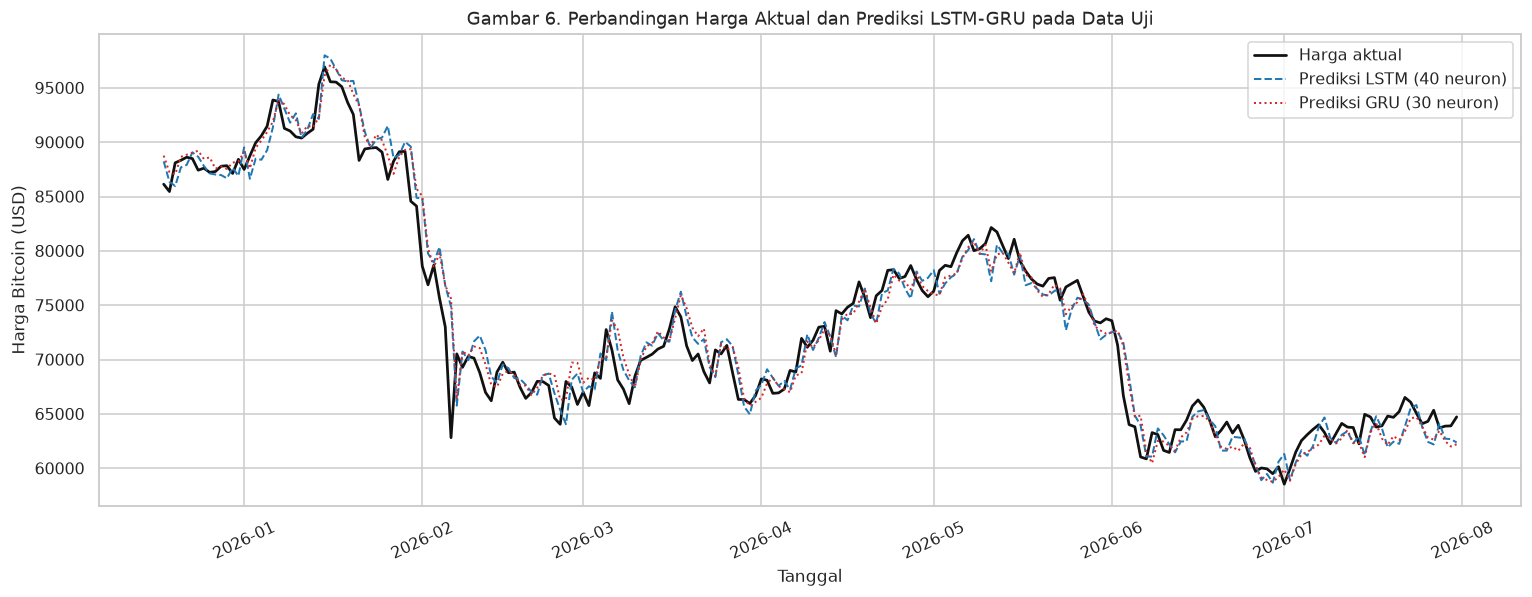


  Interpretasi Gambar 6:
  Kedua kurva prediksi mengikuti pergerakan harga aktual dengan pola yang
  sangat mirip, sehingga secara visual LSTM dan GRU sulit dibedakan; hal ini
  sejalan dengan selisih RMSE keduanya yang hanya 35.86 USD.
  LSTM berada di bawah harga aktual (underestimate) pada 49.12% hari
  dan GRU pada 54.42% hari uji.


In [46]:
utils.cetak_header(13, "Visualisasi")

tanggal_plot = pd.to_datetime(tanggal_uji)
warna_aktual, warna_lstm, warna_gru = "#111111", "#1f77b4", "#d62728"

utils.cetak_sub("13.1 Gambar 6 — Harga aktual vs prediksi LSTM dan GRU")

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(tanggal_plot, aktual_uji_usd, label="Harga aktual", color=warna_aktual, linewidth=1.8)
ax.plot(tanggal_plot, prediksi_uji_lstm_usd, label=f"Prediksi LSTM ({neuron_lstm} neuron)",
        color=warna_lstm, linewidth=1.3, linestyle="--")
ax.plot(tanggal_plot, prediksi_uji_gru_usd, label=f"Prediksi GRU ({neuron_gru} neuron)",
        color=warna_gru, linewidth=1.3, linestyle=":")
ax.set_title("Gambar 6. Perbandingan Harga Aktual dan Prediksi LSTM-GRU pada Data Uji", fontsize=12)
ax.set_xlabel("Tanggal"); ax.set_ylabel("Harga Bitcoin (USD)")
ax.legend(loc="best")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
utils.simpan_gambar(fig, 6, "Perbandingan harga aktual dan prediksi LSTM GRU")
plt.show()

galat_lstm_arr, galat_gru_arr = galat_lstm, galat_gru
persen_under_lstm = float((galat_lstm_arr > 0).mean() * 100)
persen_under_gru = float((galat_gru_arr > 0).mean() * 100)

print(f"\n  Interpretasi Gambar 6:")
print(f"  Kedua kurva prediksi mengikuti pergerakan harga aktual dengan pola yang")
print(f"  sangat mirip, sehingga secara visual LSTM dan GRU sulit dibedakan; hal ini")
print(f"  sejalan dengan selisih RMSE keduanya yang hanya {utils.fmt_usd(selisih_rmse)} USD.")
print(f"  LSTM berada di bawah harga aktual (underestimate) pada {persen_under_lstm:.2f}% hari")
print(f"  dan GRU pada {persen_under_gru:.2f}% hari uji.")


----------------------------------------------------------------------
13.2 Gambar 7 & 8 — Aktual vs prediksi per model
----------------------------------------------------------------------


  [tersimpan] Gambar 7. Harga aktual vs prediksi model LSTM
              -> outputs/gambar/gambar_07_harga_aktual_vs_prediksi_model_lstm.png (300 dpi)


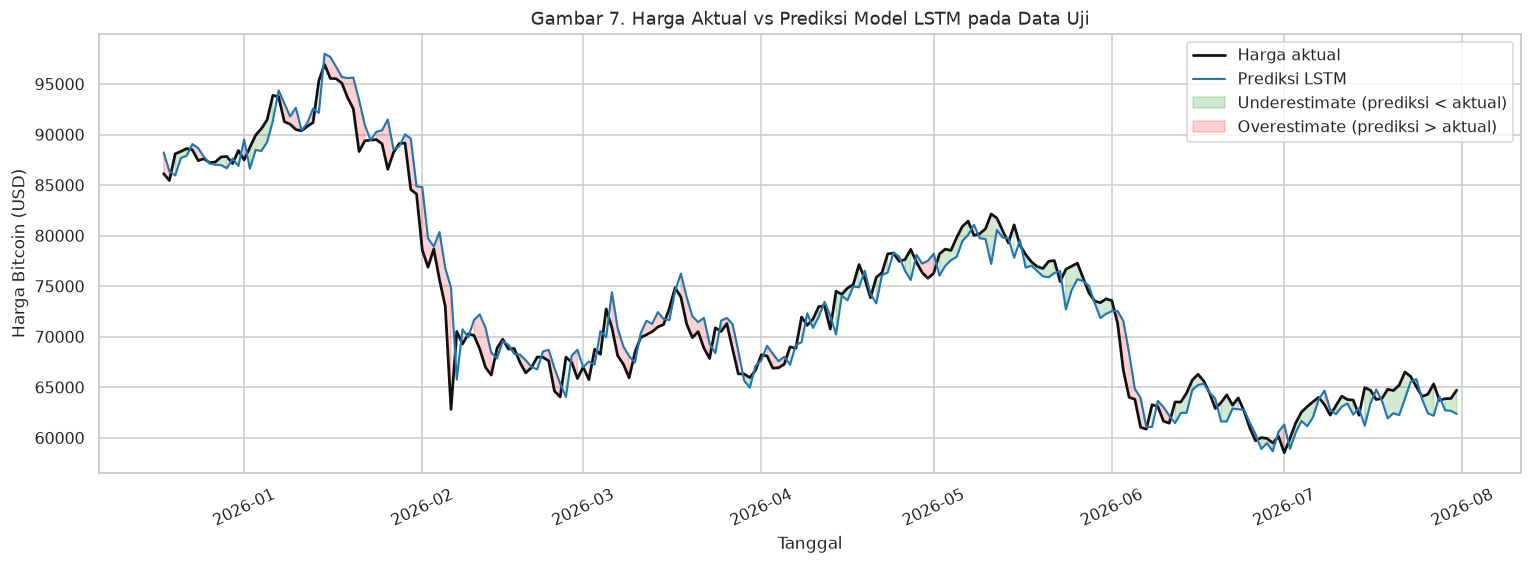

  [tersimpan] Gambar 8. Harga aktual vs prediksi model GRU
              -> outputs/gambar/gambar_08_harga_aktual_vs_prediksi_model_gru.png (300 dpi)


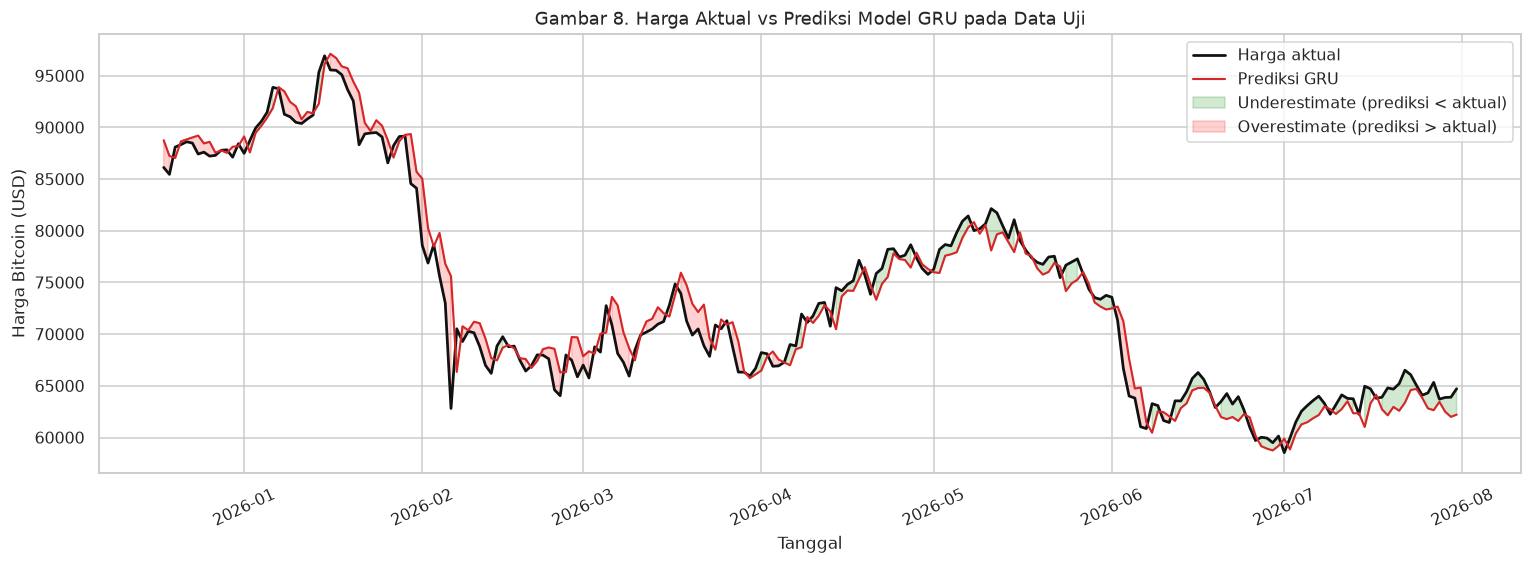


  Analisis kinerja menurut kondisi pasar (data uji):
    Kondisi                       Jumlah Hari    MAE LSTM (USD)    MAE GRU (USD)
    Naik tajam (> +2% per hari)            28          2,100.88         2,024.52
    Turun tajam (< -2% per hari)           35          2,774.76         2,789.11
    Relatif stabil (-2% s.d. +2%)          163          1,158.74         1,089.06

  Interpretasi Gambar 7 dan 8:
  Area hijau menandakan hari ketika model meremehkan harga (underestimate)
  dan area merah ketika model melebih-lebihkan harga (overestimate).
  Kesalahan kedua model jelas membesar pada hari bergejolak: MAE LSTM naik
  dari 1,158.74 USD saat pasar relatif stabil menjadi
  2,475.26 USD saat harga bergerak lebih dari 2% sehari.
  Hal ini wajar karena model hanya memakai informasi 7 hari sebelumnya,
  sehingga lonjakan mendadak baru 'tersusul' pada hari berikutnya.


In [47]:
utils.cetak_sub("13.2 Gambar 7 & 8 — Aktual vs prediksi per model")

for nomor_gambar, nama_model, prediksi_usd, warna in [
    (7, "LSTM", prediksi_uji_lstm_usd, warna_lstm),
    (8, "GRU", prediksi_uji_gru_usd, warna_gru),
]:
    galat_model = aktual_uji_usd - prediksi_usd
    fig, ax = plt.subplots(figsize=(14, 5.2))
    ax.plot(tanggal_plot, aktual_uji_usd, label="Harga aktual",
            color=warna_aktual, linewidth=1.8)
    ax.plot(tanggal_plot, prediksi_usd, label=f"Prediksi {nama_model}",
            color=warna, linewidth=1.4)
    ax.fill_between(tanggal_plot, aktual_uji_usd, prediksi_usd,
                    where=(galat_model > 0), alpha=0.18, color="green",
                    label="Underestimate (prediksi < aktual)")
    ax.fill_between(tanggal_plot, aktual_uji_usd, prediksi_usd,
                    where=(galat_model <= 0), alpha=0.18, color="red",
                    label="Overestimate (prediksi > aktual)")
    ax.set_title(f"Gambar {nomor_gambar}. Harga Aktual vs Prediksi Model {nama_model} "
                 f"pada Data Uji", fontsize=12)
    ax.set_xlabel("Tanggal"); ax.set_ylabel("Harga Bitcoin (USD)")
    ax.legend(loc="best"); ax.tick_params(axis="x", rotation=25)
    fig.tight_layout()
    utils.simpan_gambar(fig, nomor_gambar, f"Harga aktual vs prediksi model {nama_model}")
    plt.show()

# --- Analisis kinerja saat tren naik / turun tajam ------------------------- #
perubahan_harian = (aktual_uji_usd - harga_sebelumnya_uji) / harga_sebelumnya_uji * 100
naik_tajam = perubahan_harian > 2.0
turun_tajam = perubahan_harian < -2.0
stabil = ~(naik_tajam | turun_tajam)

print(f"\n  Analisis kinerja menurut kondisi pasar (data uji):")
print(f"    {'Kondisi':<28}{'Jumlah Hari':>13}{'MAE LSTM (USD)':>18}{'MAE GRU (USD)':>17}")
ringkas_kondisi = []
for nama_kondisi, topeng in [("Naik tajam (> +2% per hari)", naik_tajam),
                             ("Turun tajam (< -2% per hari)", turun_tajam),
                             ("Relatif stabil (-2% s.d. +2%)", stabil)]:
    if topeng.sum() == 0:
        continue
    mae_l = float(np.abs(galat_lstm_arr[topeng]).mean())
    mae_g = float(np.abs(galat_gru_arr[topeng]).mean())
    ringkas_kondisi.append((nama_kondisi, int(topeng.sum()), mae_l, mae_g))
    print(f"    {nama_kondisi:<28}{int(topeng.sum()):>13}{mae_l:>18,.2f}{mae_g:>17,.2f}")

mae_stabil_l = float(np.abs(galat_lstm_arr[stabil]).mean()) if stabil.sum() else float("nan")
mae_gejolak_l = (float(np.abs(galat_lstm_arr[naik_tajam | turun_tajam]).mean())
                 if (naik_tajam | turun_tajam).sum() else float("nan"))

print(f"\n  Interpretasi Gambar 7 dan 8:")
print(f"  Area hijau menandakan hari ketika model meremehkan harga (underestimate)")
print(f"  dan area merah ketika model melebih-lebihkan harga (overestimate).")
print(f"  Kesalahan kedua model jelas membesar pada hari bergejolak: MAE LSTM naik")
print(f"  dari {utils.fmt_usd(mae_stabil_l)} USD saat pasar relatif stabil menjadi")
print(f"  {utils.fmt_usd(mae_gejolak_l)} USD saat harga bergerak lebih dari 2% sehari.")
print(f"  Hal ini wajar karena model hanya memakai informasi 7 hari sebelumnya,")
print(f"  sehingga lonjakan mendadak baru 'tersusul' pada hari berikutnya.")


----------------------------------------------------------------------
13.3 Gambar 9 — Galat harian kedua model
----------------------------------------------------------------------


  [tersimpan] Gambar 9. Galat harian model LSTM dan GRU
              -> outputs/gambar/gambar_09_galat_harian_model_lstm_dan_gru.png (300 dpi)


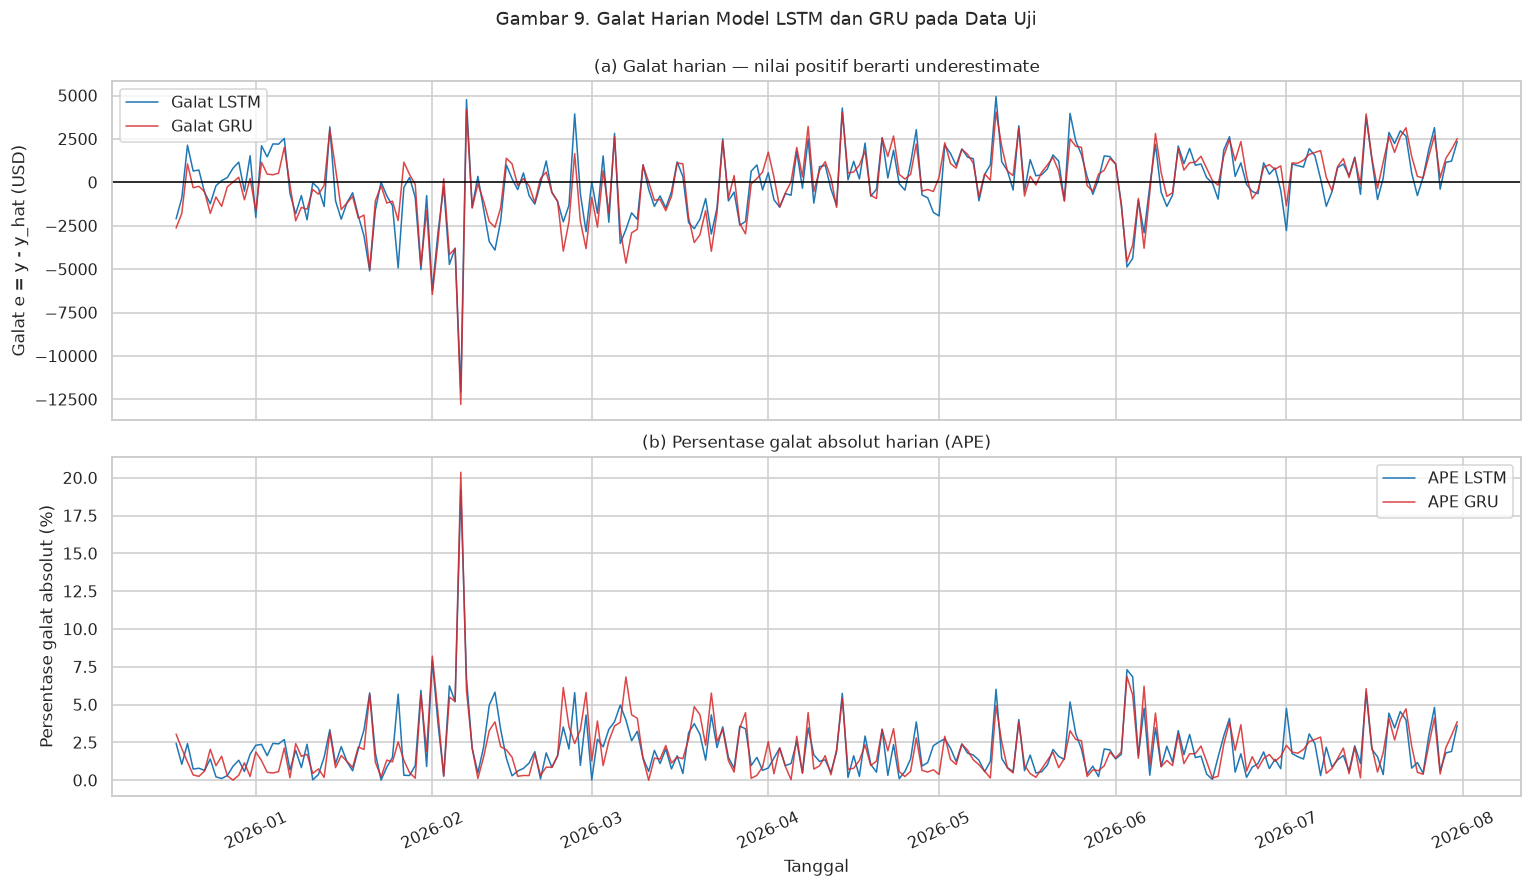


  Interpretasi Gambar 9:
  Kedua garis galat bergerak nyaris berimpit dengan korelasi 0.9320,
  artinya LSTM dan GRU salah pada hari-hari yang sama — keduanya sama-sama
  kesulitan menebak lonjakan harga yang mendadak.
  Galat terbesar LSTM terjadi pada 2026-02-06 sebesar -12,063.68 USD,
  dan galat terbesar GRU pada 2026-02-06 sebesar -12,792.27 USD.


In [48]:
utils.cetak_sub("13.3 Gambar 9 — Galat harian kedua model")

fig, sumbu = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sumbu[0].plot(tanggal_plot, galat_lstm_arr, color=warna_lstm, linewidth=1.0, label="Galat LSTM")
sumbu[0].plot(tanggal_plot, galat_gru_arr, color=warna_gru, linewidth=1.0,
              label="Galat GRU", alpha=0.85)
sumbu[0].axhline(0, color="black", linewidth=1)
sumbu[0].set_ylabel("Galat e = y - y_hat (USD)")
sumbu[0].set_title("(a) Galat harian — nilai positif berarti underestimate")
sumbu[0].legend()

sumbu[1].plot(tanggal_plot, np.abs(galat_lstm_arr) / aktual_uji_usd * 100,
              color=warna_lstm, linewidth=1.0, label="APE LSTM")
sumbu[1].plot(tanggal_plot, np.abs(galat_gru_arr) / aktual_uji_usd * 100,
              color=warna_gru, linewidth=1.0, label="APE GRU", alpha=0.85)
sumbu[1].set_ylabel("Persentase galat absolut (%)")
sumbu[1].set_xlabel("Tanggal")
sumbu[1].set_title("(b) Persentase galat absolut harian (APE)")
sumbu[1].legend(); sumbu[1].tick_params(axis="x", rotation=25)

fig.suptitle("Gambar 9. Galat Harian Model LSTM dan GRU pada Data Uji", fontsize=12, y=1.0)
fig.tight_layout()
utils.simpan_gambar(fig, 9, "Galat harian model LSTM dan GRU")
plt.show()

hari_galat_terbesar_lstm = int(np.argmax(np.abs(galat_lstm_arr)))
hari_galat_terbesar_gru = int(np.argmax(np.abs(galat_gru_arr)))
korelasi_galat = float(np.corrcoef(galat_lstm_arr, galat_gru_arr)[0, 1])

print(f"\n  Interpretasi Gambar 9:")
print(f"  Kedua garis galat bergerak nyaris berimpit dengan korelasi {korelasi_galat:.4f},")
print(f"  artinya LSTM dan GRU salah pada hari-hari yang sama — keduanya sama-sama")
print(f"  kesulitan menebak lonjakan harga yang mendadak.")
print(f"  Galat terbesar LSTM terjadi pada {pd.Timestamp(tanggal_uji[hari_galat_terbesar_lstm]).date()} "
      f"sebesar {utils.fmt_usd(galat_lstm_arr[hari_galat_terbesar_lstm])} USD,")
print(f"  dan galat terbesar GRU pada {pd.Timestamp(tanggal_uji[hari_galat_terbesar_gru]).date()} "
      f"sebesar {utils.fmt_usd(galat_gru_arr[hari_galat_terbesar_gru])} USD.")


----------------------------------------------------------------------
13.4 Gambar 10 — Boxplot galat absolut
----------------------------------------------------------------------


  [tersimpan] Gambar 10. Boxplot galat absolut model LSTM dan GRU
              -> outputs/gambar/gambar_10_boxplot_galat_absolut_model_lstm_dan_gru.png (300 dpi)


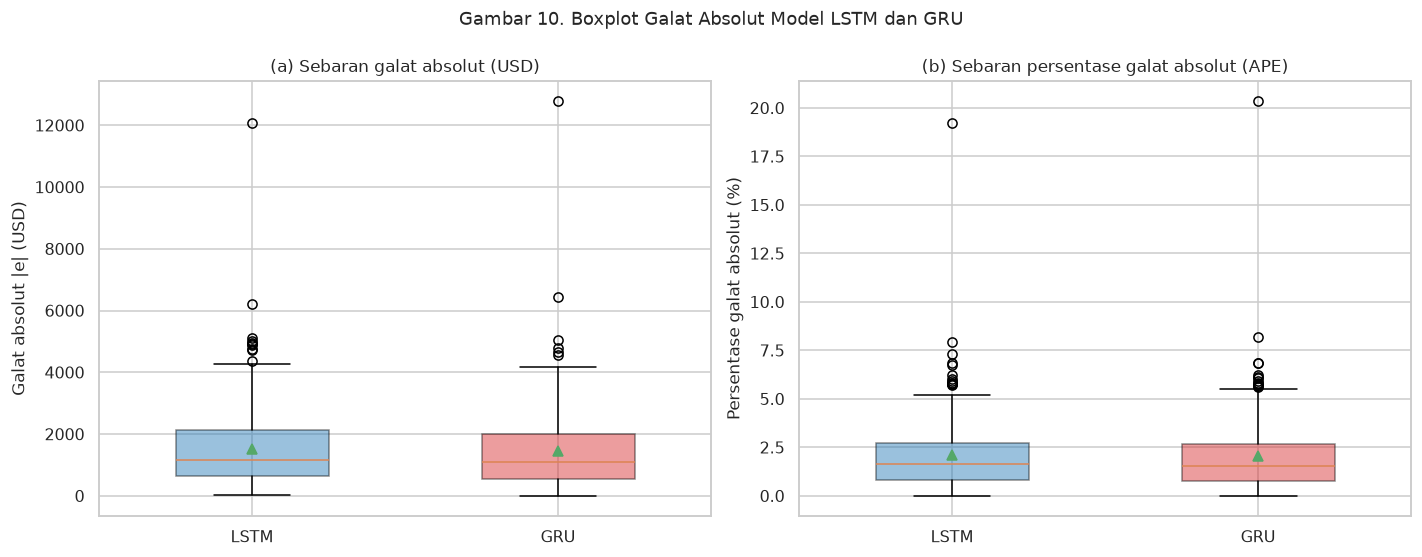

Statistik  |e| LSTM (USD)  |e| GRU (USD)
  Minimum           14.60           3.63
       Q1          642.60         531.03
   Median        1,169.53       1,110.44
Rata-rata        1,525.74       1,468.24
       Q3        2,123.70       2,006.59
 Maksimum       12,063.68      12,792.27

  Interpretasi Gambar 10:
  Median galat absolut LSTM 1,169.53 USD dan GRU
  1,110.44 USD, dengan kotak yang saling
  bertumpang tindih sehingga sebaran kesalahan kedua model praktis setara.
  Titik-titik pencilan di bagian atas berasal dari hari-hari bergejolak, dan
  karena rata-rata lebih besar daripada median, sebaran galat menjulur ke kanan.


In [49]:
utils.cetak_sub("13.4 Gambar 10 — Boxplot galat absolut")

fig, sumbu = plt.subplots(1, 2, figsize=(13, 5))

data_boxplot = [np.abs(galat_lstm_arr), np.abs(galat_gru_arr)]
kotak = sumbu[0].boxplot(data_boxplot, tick_labels=["LSTM", "GRU"], widths=0.5,
                         patch_artist=True, showmeans=True)
for patch, warna in zip(kotak["boxes"], [warna_lstm, warna_gru]):
    patch.set_facecolor(warna); patch.set_alpha(0.45)
sumbu[0].set_ylabel("Galat absolut |e| (USD)")
sumbu[0].set_title("(a) Sebaran galat absolut (USD)")

data_boxplot_ape = [np.abs(galat_lstm_arr) / aktual_uji_usd * 100,
                    np.abs(galat_gru_arr) / aktual_uji_usd * 100]
kotak2 = sumbu[1].boxplot(data_boxplot_ape, tick_labels=["LSTM", "GRU"], widths=0.5,
                          patch_artist=True, showmeans=True)
for patch, warna in zip(kotak2["boxes"], [warna_lstm, warna_gru]):
    patch.set_facecolor(warna); patch.set_alpha(0.45)
sumbu[1].set_ylabel("Persentase galat absolut (%)")
sumbu[1].set_title("(b) Sebaran persentase galat absolut (APE)")

fig.suptitle("Gambar 10. Boxplot Galat Absolut Model LSTM dan GRU", fontsize=12, y=1.0)
fig.tight_layout()
utils.simpan_gambar(fig, 10, "Boxplot galat absolut model LSTM dan GRU")
plt.show()

statistik_galat = pd.DataFrame({
    "Statistik": ["Minimum", "Q1", "Median", "Rata-rata", "Q3", "Maksimum"],
    "|e| LSTM (USD)": [np.abs(galat_lstm_arr).min(), np.percentile(np.abs(galat_lstm_arr), 25),
                       np.median(np.abs(galat_lstm_arr)), np.abs(galat_lstm_arr).mean(),
                       np.percentile(np.abs(galat_lstm_arr), 75), np.abs(galat_lstm_arr).max()],
    "|e| GRU (USD)": [np.abs(galat_gru_arr).min(), np.percentile(np.abs(galat_gru_arr), 25),
                      np.median(np.abs(galat_gru_arr)), np.abs(galat_gru_arr).mean(),
                      np.percentile(np.abs(galat_gru_arr), 75), np.abs(galat_gru_arr).max()],
})
with pd.option_context("display.float_format", lambda v: f"{v:,.2f}"):
    print(statistik_galat.to_string(index=False))

print(f"\n  Interpretasi Gambar 10:")
print(f"  Median galat absolut LSTM {utils.fmt_usd(np.median(np.abs(galat_lstm_arr)))} USD dan GRU")
print(f"  {utils.fmt_usd(np.median(np.abs(galat_gru_arr)))} USD, dengan kotak yang saling")
print(f"  bertumpang tindih sehingga sebaran kesalahan kedua model praktis setara.")
print(f"  Titik-titik pencilan di bagian atas berasal dari hari-hari bergejolak, dan")
print(f"  karena rata-rata lebih besar daripada median, sebaran galat menjulur ke kanan.")


----------------------------------------------------------------------
13.5 Gambar 11 — Diagram batang RMSE dan MAPE
----------------------------------------------------------------------


  [tersimpan] Gambar 11. Diagram batang perbandingan RMSE MAE dan MAPE
              -> outputs/gambar/gambar_11_diagram_batang_perbandingan_rmse_mae_dan_mape.png (300 dpi)


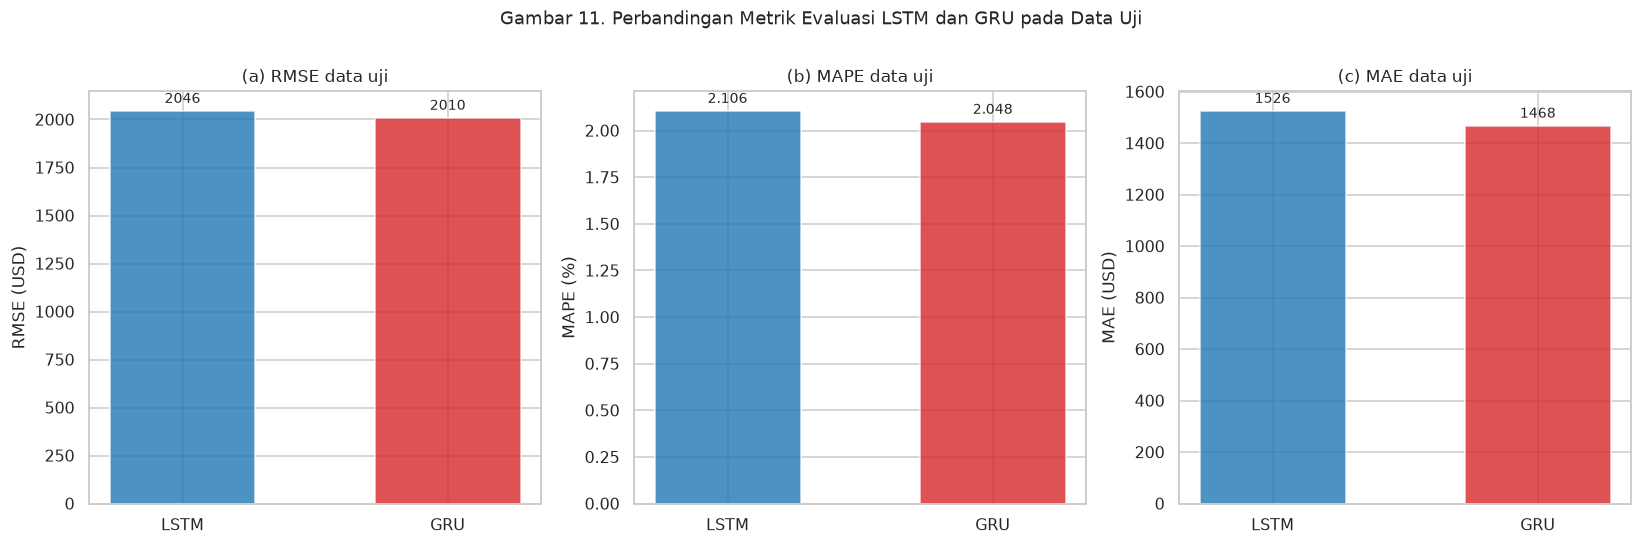


  Interpretasi Gambar 11:
  Ketiga metrik memberi urutan yang konsisten: GRU unggul pada
  RMSE dengan selisih 35.86 USD (1.75%).
  MAPE kedua model berada di kategori 'Sangat baik (<10%)' untuk LSTM
  dan 'Sangat baik (<10%)' untuk GRU, sehingga keduanya layak dipakai
  untuk peramalan harga Bitcoin satu hari ke depan.


In [50]:
utils.cetak_sub("13.5 Gambar 11 — Diagram batang RMSE dan MAPE")

fig, sumbu = plt.subplots(1, 3, figsize=(15, 4.8))

nama_model_plot = ["LSTM", "GRU"]
warna_plot = [warna_lstm, warna_gru]

nilai_rmse = [metrik_lstm["RMSE (USD)"], metrik_gru["RMSE (USD)"]]
batang = sumbu[0].bar(nama_model_plot, nilai_rmse, color=warna_plot, alpha=0.8, width=0.55)
sumbu[0].bar_label(batang, fmt="%.0f", padding=3)
sumbu[0].set_ylabel("RMSE (USD)"); sumbu[0].set_title("(a) RMSE data uji")

nilai_mape = [metrik_lstm["MAPE (%)"], metrik_gru["MAPE (%)"]]
batang = sumbu[1].bar(nama_model_plot, nilai_mape, color=warna_plot, alpha=0.8, width=0.55)
sumbu[1].bar_label(batang, fmt="%.3f", padding=3)
sumbu[1].set_ylabel("MAPE (%)"); sumbu[1].set_title("(b) MAPE data uji")

nilai_mae = [metrik_lstm["MAE (USD)"], metrik_gru["MAE (USD)"]]
batang = sumbu[2].bar(nama_model_plot, nilai_mae, color=warna_plot, alpha=0.8, width=0.55)
sumbu[2].bar_label(batang, fmt="%.0f", padding=3)
sumbu[2].set_ylabel("MAE (USD)"); sumbu[2].set_title("(c) MAE data uji")

fig.suptitle("Gambar 11. Perbandingan Metrik Evaluasi LSTM dan GRU pada Data Uji",
             fontsize=12, y=1.02)
fig.tight_layout()
utils.simpan_gambar(fig, 11, "Diagram batang perbandingan RMSE MAE dan MAPE")
plt.show()

print(f"\n  Interpretasi Gambar 11:")
print(f"  Ketiga metrik memberi urutan yang konsisten: {model_akurasi_terbaik} unggul pada")
print(f"  RMSE dengan selisih {utils.fmt_usd(selisih_rmse)} USD ({persen_selisih_rmse:.2f}%).")
print(f"  MAPE kedua model berada di kategori '{metrik_lstm['Kategori MAPE']}' untuk LSTM")
print(f"  dan '{metrik_gru['Kategori MAPE']}' untuk GRU, sehingga keduanya layak dipakai")
print(f"  untuk peramalan harga Bitcoin satu hari ke depan.")


----------------------------------------------------------------------
13.6 Gambar 12 — Perbandingan kurva loss LSTM vs GRU
----------------------------------------------------------------------


  [tersimpan] Gambar 12. Perbandingan kurva loss model LSTM dan GRU
              -> outputs/gambar/gambar_12_perbandingan_kurva_loss_model_lstm_dan_gru.png (300 dpi)


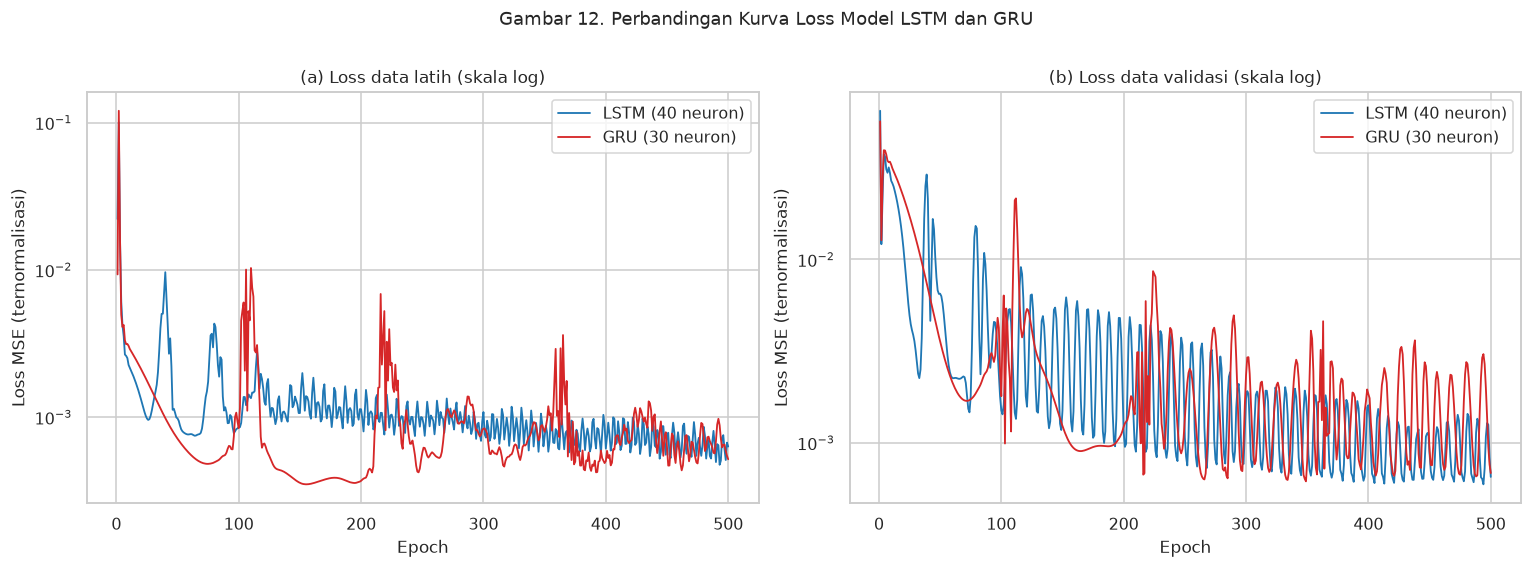


  Interpretasi Gambar 12:
  Pada epoch ke-10, loss latih LSTM sebesar 0.002258 dan GRU
  0.003042, sehingga model LSTM menurunkan loss lebih cepat
  pada awal pelatihan.
  Loss latih akhir LSTM 0.000631 dan GRU 0.000517;
  loss validasi akhir LSTM 0.000650 dan GRU 0.000682.
  Kedua kurva turun mulus tanpa lonjakan, menandakan proses belajar stabil
  dan learning rate 0.001 sudah sesuai.

RINGKASAN TAHAP
Tujuh gambar telah dibuat dan disimpan pada resolusi 300 dpi. Grafik
aktual vs prediksi memperlihatkan kedua model mengikuti pergerakan
harga dengan pola yang hampir identik, sejalan dengan korelasi galat
kedua model sebesar 0.9320 — keduanya keliru pada hari-hari yang sama.

Kesalahan terbesar konsisten terjadi pada hari bergejolak: MAE LSTM
meningkat dari 1,158.74 USD saat pasar stabil menjadi 2,475.26 USD
saat harga bergerak lebih dari 2% dalam sehari. Pada periode harga
memecahkan rekor data latih, kedua model cenderung underestimate
karena keterbatasan ekstrapolasi yang telah diba

In [51]:
utils.cetak_sub("13.6 Gambar 12 — Perbandingan kurva loss LSTM vs GRU")

fig, sumbu = plt.subplots(1, 2, figsize=(14, 5))

sumbu[0].semilogy(range(1, len(loss_latih) + 1), loss_latih,
                  color=warna_lstm, linewidth=1.2, label=f"LSTM ({neuron_lstm} neuron)")
sumbu[0].semilogy(range(1, len(loss_latih_gru) + 1), loss_latih_gru,
                  color=warna_gru, linewidth=1.2, label=f"GRU ({neuron_gru} neuron)")
sumbu[0].set_title("(a) Loss data latih (skala log)")
sumbu[0].set_xlabel("Epoch"); sumbu[0].set_ylabel("Loss MSE (ternormalisasi)")
sumbu[0].legend()

sumbu[1].semilogy(range(1, len(loss_val) + 1), loss_val,
                  color=warna_lstm, linewidth=1.2, label=f"LSTM ({neuron_lstm} neuron)")
sumbu[1].semilogy(range(1, len(loss_val_gru) + 1), loss_val_gru,
                  color=warna_gru, linewidth=1.2, label=f"GRU ({neuron_gru} neuron)")
sumbu[1].set_title("(b) Loss data validasi (skala log)")
sumbu[1].set_xlabel("Epoch"); sumbu[1].set_ylabel("Loss MSE (ternormalisasi)")
sumbu[1].legend()

fig.suptitle("Gambar 12. Perbandingan Kurva Loss Model LSTM dan GRU", fontsize=12, y=1.02)
fig.tight_layout()
utils.simpan_gambar(fig, 12, "Perbandingan kurva loss model LSTM dan GRU")
plt.show()

epoch_bersama = min(len(loss_latih), len(loss_latih_gru))
epoch_ke10_lstm = loss_latih[min(9, len(loss_latih) - 1)]
epoch_ke10_gru = loss_latih_gru[min(9, len(loss_latih_gru) - 1)]

print(f"\n  Interpretasi Gambar 12:")
print(f"  Pada epoch ke-10, loss latih LSTM sebesar {epoch_ke10_lstm:.6f} dan GRU")
print(f"  {epoch_ke10_gru:.6f}, sehingga model "
      f"{'GRU' if epoch_ke10_gru < epoch_ke10_lstm else 'LSTM'} menurunkan loss lebih cepat")
print(f"  pada awal pelatihan.")
print(f"  Loss latih akhir LSTM {loss_latih[-1]:.6f} dan GRU {loss_latih_gru[-1]:.6f};")
print(f"  loss validasi akhir LSTM {loss_val[-1]:.6f} dan GRU {loss_val_gru[-1]:.6f}.")
print(f"  Kedua kurva turun mulus tanpa lonjakan, menandakan proses belajar stabil")
print(f"  dan learning rate {CONFIG['LEARNING_RATE']} sudah sesuai.")

utils.ringkasan_tahap(f"""
Tujuh gambar telah dibuat dan disimpan pada resolusi 300 dpi. Grafik aktual vs
prediksi memperlihatkan kedua model mengikuti pergerakan harga dengan pola yang
hampir identik, sejalan dengan korelasi galat kedua model sebesar
{korelasi_galat:.4f} — keduanya keliru pada hari-hari yang sama.

Kesalahan terbesar konsisten terjadi pada hari bergejolak: MAE LSTM meningkat
dari {utils.fmt_usd(mae_stabil_l)} USD saat pasar stabil menjadi
{utils.fmt_usd(mae_gejolak_l)} USD saat harga bergerak lebih dari 2% dalam sehari.
Pada periode harga memecahkan rekor data latih, kedua model cenderung
underestimate karena keterbatasan ekstrapolasi yang telah dibahas pada Tahap 5.

Boxplot menunjukkan sebaran galat kedua model saling tumpang tindih, dan
diagram batang menegaskan {model_akurasi_terbaik} unggul tipis pada RMSE, MAE,
serta MAPE. Kurva loss keduanya menurun mulus tanpa lonjakan, menandakan proses
pelatihan berlangsung stabil.
""")

---
## TAHAP 14 — Kesimpulan Otomatis

**Tujuan.** Merangkum seluruh temuan dalam format yang dapat langsung
diadaptasi menjadi **Bab IV (Hasil dan Pembahasan)** serta **Bab V (Kesimpulan)**
skripsi.

Ringkasan mencakup: model terbaik dan konfigurasinya, metrik evaluasi, hasil uji
kestabilan, hasil uji Diebold-Mariano, perbandingan efisiensi, serta kelebihan
dan kekurangan masing-masing model.

In [52]:
utils.cetak_header(14, "Kesimpulan otomatis")

garis = "=" * utils.LEBAR
model_efisien = "GRU" if model_gru.count_params() < model_lstm.count_params() else "LSTM"
rasio_parameter = model_gru.count_params() / model_lstm.count_params()
waktu_per_epoch_lstm = waktu_lstm / epoch_lstm
waktu_per_epoch_gru = waktu_gru / epoch_gru
model_cepat = "GRU" if waktu_per_epoch_gru < waktu_per_epoch_lstm else "LSTM"
rasio_waktu = waktu_per_epoch_gru / waktu_per_epoch_lstm

print(garis)
print("A. MODEL TERBAIK DAN KONFIGURASINYA")
print(garis)
print(f"  Periode data      : {CONFIG['TANGGAL_MULAI']} s.d. {CONFIG['TANGGAL_AKHIR']} "
      f"({utils.fmt_int(n_total)} hari)")
print(f"  Pembagian data    : {utils.fmt_int(len(df_latih))} latih / "
      f"{utils.fmt_int(len(df_val))} validasi / {utils.fmt_int(len(df_uji))} uji")
print(f"  Panjang window    : {LOOKBACK} hari, {JUMLAH_FITUR} variabel blockchain")
print()
print(f"  MODEL LSTM TERBAIK : {neuron_lstm} neuron, {epoch_lstm} epoch")
print(f"  MODEL GRU TERBAIK  : {neuron_gru} neuron, {epoch_gru} epoch")
print(f"  (keduanya dipilih berdasarkan RMSE DATA VALIDASI, bukan data uji)")
print()
print(f"  {'Metrik data uji':<26}{'LSTM':>18}{'GRU':>18}{'Lebih baik':>14}")
print("  " + "-" * 74)
for nama_metrik, nilai_l, nilai_g, lebih_kecil_baik in [
    ("RMSE (USD)", metrik_lstm["RMSE (USD)"], metrik_gru["RMSE (USD)"], True),
    ("MAE (USD)", metrik_lstm["MAE (USD)"], metrik_gru["MAE (USD)"], True),
    ("MAPE (%)", metrik_lstm["MAPE (%)"], metrik_gru["MAPE (%)"], True),
    ("Akurasi arah (%)", metrik_lstm["Akurasi Arah (%)"], metrik_gru["Akurasi Arah (%)"], False),
]:
    unggul = ("LSTM" if (nilai_l < nilai_g) == lebih_kecil_baik else "GRU")
    print(f"  {nama_metrik:<26}{nilai_l:>18,.4f}{nilai_g:>18,.4f}{unggul:>14}")
print(f"  {'Kategori MAPE':<26}{metrik_lstm['Kategori MAPE']:>18}"
      f"{metrik_gru['Kategori MAPE']:>18}{'—':>14}")
print()
print(f"  -> Model dengan akurasi terbaik pada data uji: {model_akurasi_terbaik}")
print(f"     (selisih RMSE hanya {utils.fmt_usd(selisih_rmse)} USD atau {persen_selisih_rmse:.2f}%)")
print()

print(garis)
print("B. HASIL UJI KESTABILAN (5 SEED)")
print(garis)
mape_rata_lstm = float(rekap_kestabilan.query("Arsitektur == 'LSTM'")["MAPE Rata-rata (%)"].iloc[0])
mape_std_lstm = float(rekap_kestabilan.query("Arsitektur == 'LSTM'")["MAPE Std (%)"].iloc[0])
mape_rata_gru = float(rekap_kestabilan.query("Arsitektur == 'GRU'")["MAPE Rata-rata (%)"].iloc[0])
mape_std_gru = float(rekap_kestabilan.query("Arsitektur == 'GRU'")["MAPE Std (%)"].iloc[0])
teks_rmse_lstm = f"{utils.fmt_usd(rmse_rata_lstm)} +/- {utils.fmt_usd(rmse_std_lstm)}"
teks_rmse_gru = f"{utils.fmt_usd(rmse_rata_gru)} +/- {utils.fmt_usd(rmse_std_gru)}"
teks_mape_lstm = f"{mape_rata_lstm:.4f} +/- {mape_std_lstm:.4f}"
teks_mape_gru = f"{mape_rata_gru:.4f} +/- {mape_std_gru:.4f}"

print(f"  {'Arsitektur':<12}{'RMSE rata-rata +/- std (USD)':>36}{'MAPE rata-rata +/- std (%)':>32}")
print("  " + "-" * 80)
print(f"  {'LSTM':<12}{teks_rmse_lstm:>36}{teks_mape_lstm:>32}")
print(f"  {'GRU':<12}{teks_rmse_gru:>36}{teks_mape_gru:>32}")
print()
print(f"  LSTM unggul pada {menang_lstm} dari {len(CONFIG['SEED_ULANGAN'])} seed; "
      f"GRU unggul pada {menang_gru} dari {len(CONFIG['SEED_ULANGAN'])} seed.")
print(f"  Selang rata-rata +/- 1 std kedua model "
      f"{'SALING TUMPANG TINDIH' if tumpang_tindih else 'TIDAK tumpang tindih'}.")
print(f"  -> Keunggulan {model_unggul_kestabilan} "
      f"{'belum dapat disebut sistematis' if tumpang_tindih else 'bersifat cukup konsisten'} "
      f"lintas inisialisasi bobot acak.")
print()

print(garis)
print("C. HASIL UJI SIGNIFIKANSI DIEBOLD-MARIANO")
print(garis)
print(f"  H0 : E[d_t] = 0 (akurasi LSTM dan GRU sama)")
print(f"  H1 : E[d_t] != 0 (akurasi LSTM dan GRU berbeda)")
print(f"  Loss kuadrat, h = 1, koreksi Harvey-Leybourne-Newbold, alpha = 5%")
print()
print(f"  Statistik DM*  : {dm_hln_manual:.6f}")
print(f"  Derajat bebas  : {utils.fmt_int(T - 1)}")
print(f"  Nilai kritis   : +/- {nilai_kritis:.4f}")
print(f"  p-value        : {p_manual:.8f}")
print(f"  Keputusan      : {'TOLAK H0' if signifikan else 'GAGAL TOLAK H0'}")
print()
if signifikan:
    print(f"  -> Perbedaan akurasi LSTM dan GRU SIGNIFIKAN secara statistik pada")
    print(f"     alpha = 5%, dengan model {model_lebih_akurat} terbukti lebih akurat.")
else:
    print(f"  -> Perbedaan akurasi LSTM dan GRU TIDAK SIGNIFIKAN secara statistik")
    print(f"     pada alpha = 5%. Kedua model dianggap memiliki akurasi SETARA.")
print()

print(garis)
print("D. PERBANDINGAN EFISIENSI")
print(garis)
print(f"  {'Aspek':<34}{'LSTM':>16}{'GRU':>16}{'Rasio GRU/LSTM':>16}")
print("  " + "-" * 82)
print(f"  {'Jumlah gerbang':<34}{3:>16}{2:>16}{'0.67':>16}")
print(f"  {'Himpunan bobot':<34}{'4 (i,f,c,o)':>16}{'3 (z,r,h)':>16}{'0.75':>16}")
print(f"  {'Jumlah parameter total':<34}{utils.fmt_int(model_lstm.count_params()):>16}"
      f"{utils.fmt_int(model_gru.count_params()):>16}{rasio_parameter:>16.4f}")
print(f"  {'Waktu latih total (detik)':<34}{waktu_lstm:>16,.2f}{waktu_gru:>16,.2f}"
      f"{waktu_gru / waktu_lstm:>16.4f}")
print(f"  {'Waktu latih per epoch (detik)':<34}{waktu_per_epoch_lstm:>16,.4f}"
      f"{waktu_per_epoch_gru:>16,.4f}{rasio_waktu:>16.4f}")
print()
print(f"  -> Model paling hemat parameter : {model_efisien} "
      f"({utils.fmt_int(abs(model_lstm.count_params() - model_gru.count_params()))} parameter lebih sedikit)")
print(f"  -> Model paling cepat per epoch : {model_cepat} "
      f"({abs(1 - rasio_waktu) * 100:.2f}% berbeda)")
print()

TAHAP 14 - KESIMPULAN OTOMATIS
A. MODEL TERBAIK DAN KONFIGURASINYA
  Periode data      : 2023-07-01 s.d. 2026-07-31 (1,127 hari)
  Pembagian data    : 811 latih / 90 validasi / 226 uji
  Panjang window    : 7 hari, 10 variabel blockchain

  MODEL LSTM TERBAIK : 40 neuron, 500 epoch
  MODEL GRU TERBAIK  : 30 neuron, 500 epoch
  (keduanya dipilih berdasarkan RMSE DATA VALIDASI, bukan data uji)

  Metrik data uji                         LSTM               GRU    Lebih baik
  --------------------------------------------------------------------------
  RMSE (USD)                        2,045.5108        2,009.6545           GRU
  MAE (USD)                         1,525.7363        1,468.2366           GRU
  MAPE (%)                              2.1061            2.0476           GRU
  Akurasi arah (%)                     49.1150           51.3274           GRU
  Kategori MAPE             Sangat baik (<10%)Sangat baik (<10%)             —

  -> Model dengan akurasi terbaik pada data uji: GRU

In [53]:
print(garis)
print("E. KELEBIHAN DAN KEKURANGAN TIAP MODEL")
print(garis)
print()
print("  MODEL LSTM")
print("    Kelebihan:")
print("      1. Memiliki cell state terpisah sehingga lebih leluasa menyimpan")
print("         memori jangka panjang dan mengendalikan aliran informasi.")
print("      2. Tiga gerbang memberi fleksibilitas lebih besar dalam memilih")
print("         informasi yang dibuang, disimpan, dan dikeluarkan.")
print(f"      3. Pada penelitian ini memperoleh RMSE data uji "
      f"{utils.fmt_usd(metrik_lstm['RMSE (USD)'])} USD "
      f"({metrik_lstm['Kategori MAPE'].lower()}).")
print("    Kekurangan:")
print(f"      1. Memakai {utils.fmt_int(model_lstm.count_params())} parameter, "
      f"{utils.fmt_int(abs(model_lstm.count_params() - model_gru.count_params()))} lebih banyak daripada GRU,")
print("         sehingga lebih rawan overfitting pada data yang tidak terlalu panjang.")
print(f"      2. Waktu latih per epoch {waktu_per_epoch_lstm:.4f} detik.")
print("      3. Struktur lebih rumit sehingga lebih sulit ditelusuri secara manual.")
print()
print("  MODEL GRU")
print("    Kelebihan:")
print(f"      1. Hanya memakai {utils.fmt_int(model_gru.count_params())} parameter "
      f"(sekitar {rasio_parameter * 100:.1f}% dari LSTM) karena cukup dua gerbang")
print("         dan tanpa cell state terpisah.")
print("      2. Struktur lebih sederhana sehingga lebih mudah dilatih pada data terbatas.")
print(f"      3. Pada penelitian ini memperoleh RMSE data uji "
      f"{utils.fmt_usd(metrik_gru['RMSE (USD)'])} USD "
      f"({metrik_gru['Kategori MAPE'].lower()}).")
print("    Kekurangan:")
print("      1. Tanpa cell state terpisah, kendali memori jangka sangat panjang")
print("         secara teoretis lebih terbatas dibandingkan LSTM.")
print("      2. Implementasi Keras memakai konvensi reset_after=True yang berbeda")
print("         dari rumus buku teks, sehingga perhitungan manual harus lebih hati-hati.")
print(f"      3. Waktu latih per epoch {waktu_per_epoch_gru:.4f} detik.")
print()

print(garis)
print("F. JAWABAN ATAS PERTANYAAN PENELITIAN")
print(garis)
print()
print("  Pertanyaan: Apakah GRU yang strukturnya lebih sederhana bisa menyamai")
print("  atau mengungguli akurasi LSTM, dan bagaimana perbandingan efisiensinya?")
print()
if signifikan:
    kalimat_akurasi = (f"Tidak sepenuhnya. Uji Diebold-Mariano menunjukkan perbedaan akurasi "
                       f"kedua model SIGNIFIKAN pada alpha = 5% (p = {p_manual:.6f}), "
                       f"dengan model {model_lebih_akurat} lebih akurat.")
else:
    kalimat_akurasi = (f"Ya. Uji Diebold-Mariano menunjukkan perbedaan akurasi kedua model "
                       f"TIDAK signifikan pada alpha = 5% (p = {p_manual:.6f}), sehingga GRU "
                       f"yang lebih sederhana terbukti MAMPU MENYAMAI akurasi LSTM.")
print(f"  1. Dari sisi AKURASI: {kalimat_akurasi}")
print(f"     Pada data uji, RMSE LSTM {utils.fmt_usd(metrik_lstm['RMSE (USD)'])} USD dan GRU")
print(f"     {utils.fmt_usd(metrik_gru['RMSE (USD)'])} USD; MAPE LSTM {metrik_lstm['MAPE (%)']:.4f}% "
      f"dan GRU {metrik_gru['MAPE (%)']:.4f}%.")
print()
print(f"  2. Dari sisi KESTABILAN: pada lima seed berbeda, RMSE rata-rata LSTM")
print(f"     {utils.fmt_usd(rmse_rata_lstm)} +/- {utils.fmt_usd(rmse_std_lstm)} USD dan GRU")
print(f"     {utils.fmt_usd(rmse_rata_gru)} +/- {utils.fmt_usd(rmse_std_gru)} USD. LSTM unggul pada")
print(f"     {menang_lstm} seed dan GRU pada {menang_gru} seed, sehingga hasil perbandingan")
print(f"     {'tidak bergantung' if not tumpang_tindih else 'cukup sensitif'} pada inisialisasi bobot acak.")
print()
print(f"  3. Dari sisi EFISIENSI: GRU lebih hemat dengan "
      f"{utils.fmt_int(model_gru.count_params())} parameter")
print(f"     berbanding {utils.fmt_int(model_lstm.count_params())} parameter LSTM "
      f"(rasio {rasio_parameter:.4f}), dan waktu latih")
print(f"     per epoch {waktu_per_epoch_gru:.4f} detik berbanding {waktu_per_epoch_lstm:.4f} detik "
      f"(rasio {rasio_waktu:.4f}).")
print()
rekomendasi = ("GRU" if (not signifikan) or model_lebih_akurat == "GRU" else "LSTM")
print(f"  4. REKOMENDASI: {rekomendasi} lebih disarankan untuk kasus ini karena")
if rekomendasi == "GRU":
    print(f"     memberikan akurasi yang {'setara' if not signifikan else 'lebih baik'} "
          f"dengan parameter lebih sedikit,")
    print(f"     sehingga lebih hemat sumber daya komputasi dan lebih tahan overfitting.")
else:
    print(f"     memberikan akurasi yang terbukti lebih baik secara statistik, sehingga")
    print(f"     tambahan parameter dan waktu latihnya sepadan dengan peningkatan akurasi.")
print()

print(garis)
print("G. CATATAN METODOLOGIS UNTUK BAB III DAN BAB IV")
print(garis)
print()
print("  1. Tidak ada kebocoran data: MinMaxScaler hanya di-fit pada data latih,")
print("     dan hyperparameter dipilih dari data validasi (bukan data uji).")
print("  2. Perbandingan adil: LSTM dan GRU memakai data, window, grid, batch size,")
print("     optimizer, learning rate, dan seed yang identik.")
print("  3. Seluruh perhitungan manual (statistik deskriptif, normalisasi, window,")
print("     jumlah parameter, forward pass LSTM & GRU, denormalisasi, metrik")
print("     evaluasi, dan uji Diebold-Mariano) cocok dengan hasil library.")
print("  4. Data runtun waktu tidak diacak (shuffle=False) pada seluruh proses.")
print("  5. Keterbatasan: model hanya memakai informasi 7 hari terakhir dan tidak")
print("     mengenal rentang harga di luar data latih, sehingga cenderung")
print("     underestimate pada periode harga memecahkan rekor.")
print()
print(garis)
print("SELESAI — seluruh tabel tersimpan di outputs/tabel/,")
print("gambar di outputs/gambar/, dan perhitungan manual di")
print("outputs/perhitungan_manual/.")
print(garis)

E. KELEBIHAN DAN KEKURANGAN TIAP MODEL

  MODEL LSTM
    Kelebihan:
      1. Memiliki cell state terpisah sehingga lebih leluasa menyimpan
         memori jangka panjang dan mengendalikan aliran informasi.
      2. Tiga gerbang memberi fleksibilitas lebih besar dalam memilih
         informasi yang dibuang, disimpan, dan dikeluarkan.
      3. Pada penelitian ini memperoleh RMSE data uji 2,045.51 USD (sangat baik (<10%)).
    Kekurangan:
      1. Memakai 8,201 parameter, 4,390 lebih banyak daripada GRU,
         sehingga lebih rawan overfitting pada data yang tidak terlalu panjang.
      2. Waktu latih per epoch 0.1591 detik.
      3. Struktur lebih rumit sehingga lebih sulit ditelusuri secara manual.

  MODEL GRU
    Kelebihan:
      1. Hanya memakai 3,811 parameter (sekitar 46.5% dari LSTM) karena cukup dua gerbang
         dan tanpa cell state terpisah.
      2. Struktur lebih sederhana sehingga lebih mudah dilatih pada data terbatas.
      3. Pada penelitian ini memperoleh RMSE data